# SPY Intraday Momentum Strategy

Replication and extension of:

Zarattini, Aziz & Barbon (2025),  
***"Beat the Market: An Effective Intraday Momentum Strategy for S&P500 ETF (SPY)"***

## Objectives

1. Replicate the baseline intraday momentum strategy.
2. Evaluate the strategy using a chronological train/test split.
3. Develop and evaluate an original extension.
4. Compare return, volatility and Sharpe ratio under identical transaction cost assumptions.

## Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

## Project folders

In [5]:
# Project folders

DATA_RAW = Path("data/raw")
DATA_PROCESSED = Path("data/processed")
OUTPUT = Path("output")

DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
OUTPUT.mkdir(parents=True, exist_ok=True)

## Research parameters

In [7]:
TICKER = "SPY"

START_DATE = "2018-01-01"
END_DATE = "2024-04-30"

LOOKBACK = 14
VOLATILITY_MULTIPLIER = 1.0

TARGET_VOLATILITY = 0.02
MAX_LEVERAGE = 4.0

INITIAL_CAPITAL = 100_000

COMMISSION_PER_SHARE = 0.0035
SLIPPAGE_PER_SHARE = 0.001

## Alpaca 

In [9]:
# %pip install alpaca-py

In [18]:
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

In [27]:
from getpass import getpass

API_KEY = getpass("Enter Alpaca API key: ")
SECRET_KEY = getpass("Enter Alpaca secret key: ")

Enter Alpaca API key:  ········
Enter Alpaca secret key:  ········


In [29]:
client = StockHistoricalDataClient(
    API_KEY,
    SECRET_KEY
)

## Test data download

In [31]:
from datetime import datetime

request = StockBarsRequest(
    symbol_or_symbols=TICKER,
    timeframe=TimeFrame.Minute,
    start=datetime(2024, 1, 2),
    end=datetime(2024, 1, 10)
)

bars = client.get_stock_bars(request)

In [33]:
df_test = bars.df.reset_index()

df_test.head()

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap
0,SPY,2024-01-02 09:00:00+00:00,476.25,476.36,476.00,476.31,20460.0,84.0,476.301058
1,SPY,2024-01-02 09:01:00+00:00,476.34,476.34,476.29,476.29,6369.0,16.0,476.320154
2,SPY,2024-01-02 09:02:00+00:00,476.29,476.29,476.28,476.28,6152.0,10.0,476.280164
3,SPY,2024-01-02 09:03:00+00:00,476.27,476.27,476.27,476.27,369.0,10.0,476.270000
4,SPY,2024-01-02 09:05:00+00:00,476.20,476.20,476.19,476.19,547.0,8.0,476.192404


In [35]:
print(df_test.shape)
print(df_test.columns)

df_test.info()

(4745, 9)
Index(['symbol', 'timestamp', 'open', 'high', 'low', 'close', 'volume',
       'trade_count', 'vwap'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4745 entries, 0 to 4744
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   symbol       4745 non-null   object             
 1   timestamp    4745 non-null   datetime64[ns, UTC]
 2   open         4745 non-null   float64            
 3   high         4745 non-null   float64            
 4   low          4745 non-null   float64            
 5   close        4745 non-null   float64            
 6   volume       4745 non-null   float64            
 7   trade_count  4745 non-null   float64            
 8   vwap         4745 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(7), object(1)
memory usage: 333.8+ KB


In [37]:
df_test.head(10)

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap
0,SPY,2024-01-02 09:00:00+00:00,476.25,476.36,476.00,476.31,20460.0,84.0,476.301058
1,SPY,2024-01-02 09:01:00+00:00,476.34,476.34,476.29,476.29,6369.0,16.0,476.320154
2,SPY,2024-01-02 09:02:00+00:00,476.29,476.29,476.28,476.28,6152.0,10.0,476.280164
3,SPY,2024-01-02 09:03:00+00:00,476.27,476.27,476.27,476.27,369.0,10.0,476.270000
4,SPY,2024-01-02 09:05:00+00:00,476.20,476.20,476.19,476.19,547.0,8.0,476.192404
5,SPY,2024-01-02 09:06:00+00:00,476.18,476.18,476.18,476.18,230.0,13.0,476.180000
6,SPY,2024-01-02 09:07:00+00:00,476.21,476.21,476.14,476.14,5624.0,18.0,476.146364
7,SPY,2024-01-02 09:08:00+00:00,476.19,476.19,476.19,476.19,107.0,3.0,476.190000
8,SPY,2024-01-02 09:10:00+00:00,476.13,476.13,476.12,476.12,340.0,4.0,476.126667
9,SPY,2024-01-02 09:11:00+00:00,476.03,476.03,476.02,476.03,341.0,9.0,476.026667


In [39]:
# covert to NYC time

df_test["timestamp"] = pd.to_datetime(df_test["timestamp"])

df_test["timestamp"] = df_test["timestamp"].dt.tz_convert(
    "America/New_York"
)

df_test.head()

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap
0,SPY,2024-01-02 04:00:00-05:00,476.25,476.36,476.00,476.31,20460.0,84.0,476.301058
1,SPY,2024-01-02 04:01:00-05:00,476.34,476.34,476.29,476.29,6369.0,16.0,476.320154
2,SPY,2024-01-02 04:02:00-05:00,476.29,476.29,476.28,476.28,6152.0,10.0,476.280164
3,SPY,2024-01-02 04:03:00-05:00,476.27,476.27,476.27,476.27,369.0,10.0,476.270000
4,SPY,2024-01-02 04:05:00-05:00,476.20,476.20,476.19,476.19,547.0,8.0,476.192404


In [41]:
df_test = df_test.sort_values("timestamp").reset_index(drop=True)

df_test.head()

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap
0,SPY,2024-01-02 04:00:00-05:00,476.25,476.36,476.00,476.31,20460.0,84.0,476.301058
1,SPY,2024-01-02 04:01:00-05:00,476.34,476.34,476.29,476.29,6369.0,16.0,476.320154
2,SPY,2024-01-02 04:02:00-05:00,476.29,476.29,476.28,476.28,6152.0,10.0,476.280164
3,SPY,2024-01-02 04:03:00-05:00,476.27,476.27,476.27,476.27,369.0,10.0,476.270000
4,SPY,2024-01-02 04:05:00-05:00,476.20,476.20,476.19,476.19,547.0,8.0,476.192404


In [43]:
df_test = (
    df_test
    .set_index("timestamp")
    .between_time("09:30", "15:59")
    .reset_index()
)

df_test.head()

,timestamp,symbol,open,high,low,close,volume,trade_count,vwap
0,2024-01-02 09:30:00-05:00,SPY,472.160,472.67,472.050,472.5300,1205526.0,11847.0,472.323672
1,2024-01-02 09:31:00-05:00,SPY,472.530,472.70,472.365,472.6812,756655.0,3810.0,472.514117
2,2024-01-02 09:32:00-05:00,SPY,472.680,472.80,472.650,472.7800,693889.0,3807.0,472.732466
3,2024-01-02 09:33:00-05:00,SPY,472.760,472.77,472.480,472.6900,404264.0,3280.0,472.612745
4,2024-01-02 09:34:00-05:00,SPY,472.685,472.78,472.550,472.6700,250698.0,2284.0,472.672548


In [45]:
df_test.tail()

,timestamp,symbol,open,high,low,close,volume,trade_count,vwap
2335,2024-01-09 15:55:00-05:00,SPY,473.960,474.200,473.955,474.0432,896092.0,4882.0,474.060915
2336,2024-01-09 15:56:00-05:00,SPY,474.045,474.090,473.770,473.8900,553977.0,3520.0,473.898198
2337,2024-01-09 15:57:00-05:00,SPY,473.890,473.945,473.720,473.7900,789766.0,3308.0,473.825853
2338,2024-01-09 15:58:00-05:00,SPY,473.800,473.890,473.750,473.8650,719199.0,4968.0,473.826066
2339,2024-01-09 15:59:00-05:00,SPY,473.860,473.990,473.630,473.8400,2495279.0,10208.0,473.802844


In [47]:
print(df_test["timestamp"].min())
print(df_test["timestamp"].max())

2024-01-02 09:30:00-05:00
2024-01-09 15:59:00-05:00


In [49]:
df_test["date"] = df_test["timestamp"].dt.date

df_test.head()

,timestamp,symbol,open,high,low,close,volume,trade_count,vwap,date
0,2024-01-02 09:30:00-05:00,SPY,472.160,472.67,472.050,472.5300,1205526.0,11847.0,472.323672,2024-01-02
1,2024-01-02 09:31:00-05:00,SPY,472.530,472.70,472.365,472.6812,756655.0,3810.0,472.514117,2024-01-02
2,2024-01-02 09:32:00-05:00,SPY,472.680,472.80,472.650,472.7800,693889.0,3807.0,472.732466,2024-01-02
3,2024-01-02 09:33:00-05:00,SPY,472.760,472.77,472.480,472.6900,404264.0,3280.0,472.612745,2024-01-02
4,2024-01-02 09:34:00-05:00,SPY,472.685,472.78,472.550,472.6700,250698.0,2284.0,472.672548,2024-01-02


In [51]:
bars_per_day = df_test.groupby("date").size()

bars_per_day

date
2024-01-02    390
2024-01-03    390
2024-01-04    390
2024-01-05    390
2024-01-08    390
2024-01-09    390
dtype: int64

In [55]:
# check missing values

df_test[
    ["open", "high", "low", "close", "volume"]
].isna().sum()

open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [57]:
df_test[
    ["open", "high", "low", "close", "volume"]
].describe()

,open,high,low,close,volume
count,2340.000000,2340.000000,2340.000000,2340.000000,2.340000e+03
mean,470.723778,470.814681,470.634743,470.726469,1.900429e+05
std,2.008726,2.001013,2.017433,2.011545,2.393929e+05
min,466.620000,466.720000,466.430000,466.619900,2.003700e+04
25%,469.240000,469.320000,469.146500,469.240075,8.245575e+04
50%,470.367500,470.440000,470.287500,470.370000,1.222785e+05
75%,472.470000,472.540000,472.390000,472.480000,1.993510e+05
max,474.880000,474.930000,474.740000,474.880000,4.164760e+06


## Full historical dowload

### Test a one-year download

In [63]:
year = 2023

start = datetime(year, 1, 1)
end = datetime(year + 1, 1, 1)

request = StockBarsRequest(
    symbol_or_symbols=TICKER,
    timeframe=TimeFrame.Minute,
    start=start,
    end=end
)

bars = client.get_stock_bars(request)

df_year = bars.df.reset_index()

print(df_year.shape)
df_year.head()

(202657, 9)


,symbol,timestamp,open,high,low,close,volume,trade_count,vwap
0,SPY,2023-01-03 09:00:00+00:00,384.00,386.00,384.00,385.84,14020.0,154.0,385.795007
1,SPY,2023-01-03 09:01:00+00:00,385.84,386.14,385.79,386.00,4598.0,56.0,385.987750
2,SPY,2023-01-03 09:02:00+00:00,386.04,386.23,386.04,386.10,2063.0,24.0,386.128000
3,SPY,2023-01-03 09:03:00+00:00,386.13,386.45,386.12,386.45,3067.0,28.0,386.236025
4,SPY,2023-01-03 09:04:00+00:00,386.45,386.54,386.45,386.51,2450.0,27.0,386.497272


In [65]:
file_path = DATA_RAW / "SPY_2023.csv"

df_year.to_csv(file_path, index=False)

print("Saved:", file_path)

Saved: data\raw\SPY_2023.csv


### Download all years

In [73]:
YEARS = list(range(2018, 2025))

YEARS

[2018, 2019, 2020, 2021, 2022, 2023, 2024]

In [77]:
# loop to download the years and save them in .csv format

for year in YEARS:

    print(f"Downloading {year}...")

    start = datetime(year, 1, 1)

    # Paper sample ends in April 2024
    if year == 2024:
        end = datetime(2024, 5, 1)
    else:
        end = datetime(year + 1, 1, 1)

    request = StockBarsRequest(
        symbol_or_symbols=TICKER,
        timeframe=TimeFrame.Minute,
        start=start,
        end=end
    )

    bars = client.get_stock_bars(request)

    df_year = bars.df.reset_index()

    file_path = DATA_RAW / f"SPY_{year}.csv"

    df_year.to_csv(file_path, index=False)

    print(f"Saved {year}: {len(df_year):,} rows")

Saved 2018: 192,827 rows
Saved 2019: 190,711 rows
Saved 2020: 214,264 rows
Saved 2021: 201,796 rows
Saved 2022: 212,907 rows
Saved 2023: 202,657 rows
Saved 2024: 65,807 rows


## Combine and clean historical data

The raw yearly Alpaca files are combined into one DataFrame, converted to New York time, and restricted to regular trading hours.

In [81]:
files = sorted(DATA_RAW.glob("SPY_*.csv"))

files

[WindowsPath('data/raw/SPY_2018.csv'),
 WindowsPath('data/raw/SPY_2019.csv'),
 WindowsPath('data/raw/SPY_2020.csv'),
 WindowsPath('data/raw/SPY_2021.csv'),
 WindowsPath('data/raw/SPY_2022.csv'),
 WindowsPath('data/raw/SPY_2023.csv'),
 WindowsPath('data/raw/SPY_2024.csv')]

In [83]:
dataframes = []

for file in files:
    df_year = pd.read_csv(file)
    dataframes.append(df_year)

df = pd.concat(dataframes, ignore_index=True)

print(df.shape)
df.head()

(1280969, 9)


,symbol,timestamp,open,high,low,close,volume,trade_count,vwap
0,SPY,2018-01-02 09:00:00+00:00,266.89,267.03,266.62,266.99,10266.0,21.0,266.929875
1,SPY,2018-01-02 09:01:00+00:00,266.99,266.99,266.99,266.99,1600.0,2.0,266.990000
2,SPY,2018-01-02 09:02:00+00:00,266.97,266.98,266.95,266.97,8000.0,11.0,266.966375
3,SPY,2018-01-02 09:03:00+00:00,266.94,266.95,266.94,266.94,5000.0,9.0,266.941200
4,SPY,2018-01-02 09:04:00+00:00,266.97,266.99,266.94,266.94,2700.0,4.0,266.978889


In [85]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    utc=True
)

df["timestamp"] = df["timestamp"].dt.tz_convert(
    "America/New_York"
)

df.head()

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap
0,SPY,2018-01-02 04:00:00-05:00,266.89,267.03,266.62,266.99,10266.0,21.0,266.929875
1,SPY,2018-01-02 04:01:00-05:00,266.99,266.99,266.99,266.99,1600.0,2.0,266.990000
2,SPY,2018-01-02 04:02:00-05:00,266.97,266.98,266.95,266.97,8000.0,11.0,266.966375
3,SPY,2018-01-02 04:03:00-05:00,266.94,266.95,266.94,266.94,5000.0,9.0,266.941200
4,SPY,2018-01-02 04:04:00-05:00,266.97,266.99,266.94,266.94,2700.0,4.0,266.978889


In [87]:
# sort chronologically

df = df.sort_values("timestamp").reset_index(drop=True)

df.head()

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap
0,SPY,2018-01-02 04:00:00-05:00,266.89,267.03,266.62,266.99,10266.0,21.0,266.929875
1,SPY,2018-01-02 04:01:00-05:00,266.99,266.99,266.99,266.99,1600.0,2.0,266.990000
2,SPY,2018-01-02 04:02:00-05:00,266.97,266.98,266.95,266.97,8000.0,11.0,266.966375
3,SPY,2018-01-02 04:03:00-05:00,266.94,266.95,266.94,266.94,5000.0,9.0,266.941200
4,SPY,2018-01-02 04:04:00-05:00,266.97,266.99,266.94,266.94,2700.0,4.0,266.978889


In [89]:
df = (
    df
    .set_index("timestamp")
    .between_time("09:30", "15:59")
    .reset_index()
)

df.head()

,timestamp,symbol,open,high,low,close,volume,trade_count,vwap
0,2018-01-02 09:30:00-05:00,SPY,267.840,267.89,267.67,267.7300,1221610.0,2416.0,267.800296
1,2018-01-02 09:31:00-05:00,SPY,267.730,267.74,267.60,267.6199,483876.0,1512.0,267.662334
2,2018-01-02 09:32:00-05:00,SPY,267.615,267.77,267.60,267.6900,269917.0,1121.0,267.710822
3,2018-01-02 09:33:00-05:00,SPY,267.690,267.70,267.54,267.5500,309337.0,1160.0,267.624496
4,2018-01-02 09:34:00-05:00,SPY,267.545,267.60,267.46,267.4700,326513.0,1312.0,267.512756


In [91]:
df.tail()

,timestamp,symbol,open,high,low,close,volume,trade_count,vwap
620127,2024-04-30 15:55:00-04:00,SPY,503.525,503.5250,502.75,502.910,1213213.0,7504.0,503.013600
620128,2024-04-30 15:56:00-04:00,SPY,502.910,503.1599,502.86,502.960,767530.0,5676.0,502.995873
620129,2024-04-30 15:57:00-04:00,SPY,502.950,502.9500,502.53,502.585,867969.0,6425.0,502.700000
620130,2024-04-30 15:58:00-04:00,SPY,502.620,502.8200,502.50,502.520,1342533.0,8600.0,502.632366
620131,2024-04-30 15:59:00-04:00,SPY,502.520,502.5900,502.03,502.040,2756415.0,15302.0,502.302094


In [94]:
df["date"] = df["timestamp"].dt.date
df["time"] = df["timestamp"].dt.time

df.head()

,timestamp,symbol,open,high,low,close,volume,trade_count,vwap,date,time
0,2018-01-02 09:30:00-05:00,SPY,267.840,267.89,267.67,267.7300,1221610.0,2416.0,267.800296,2018-01-02,09:30:00
1,2018-01-02 09:31:00-05:00,SPY,267.730,267.74,267.60,267.6199,483876.0,1512.0,267.662334,2018-01-02,09:31:00
2,2018-01-02 09:32:00-05:00,SPY,267.615,267.77,267.60,267.6900,269917.0,1121.0,267.710822,2018-01-02,09:32:00
3,2018-01-02 09:33:00-05:00,SPY,267.690,267.70,267.54,267.5500,309337.0,1160.0,267.624496,2018-01-02,09:33:00
4,2018-01-02 09:34:00-05:00,SPY,267.545,267.60,267.46,267.4700,326513.0,1312.0,267.512756,2018-01-02,09:34:00


In [96]:
bars_per_day = df.groupby("date").size()

bars_per_day.describe()

count    1592.000000
mean      389.530151
std         5.383504
min       278.000000
25%       390.000000
50%       390.000000
75%       390.000000
max       390.000000
dtype: float64

In [98]:
bars_per_day.value_counts().sort_index()

278       1
308       1
320       1
323       1
329       1
330       1
335       1
344       1
345       1
352       1
360       1
376       4
380       1
383       1
385       1
386       1
390    1573
Name: count, dtype: int64

In [100]:
short_days = bars_per_day[bars_per_day != 390]

short_days

date
2018-07-03    345
2018-11-23    335
2018-12-24    380
2019-07-03    344
2019-08-12    360
2019-11-29    320
2019-12-24    278
2020-03-09    376
2020-03-12    376
2020-03-16    376
2020-03-18    376
2020-11-27    352
2020-12-24    323
2021-05-05    385
2021-11-26    383
2022-11-25    330
2023-06-05    386
2023-07-03    308
2023-11-24    329
dtype: int64

In [102]:
df[
    ["open", "high", "low", "close", "volume"]
].isna().sum()

open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [104]:
df.duplicated(
    subset=["timestamp", "symbol"]
).sum()

0

In [106]:
print("First timestamp:", df["timestamp"].min())
print("Last timestamp:", df["timestamp"].max())

print("Trading days:", df["date"].nunique())
print("Total minute bars:", len(df))

First timestamp: 2018-01-02 09:30:00-05:00
Last timestamp: 2024-04-30 15:59:00-04:00
Trading days: 1592
Total minute bars: 620132


In [108]:
# keep only complete regular trading days
# a normal US trading day contains 390 one-minute bars

full_days = bars_per_day[bars_per_day == 390].index

df = df[df["date"].isin(full_days)].copy()

df = df.sort_values("timestamp").reset_index(drop=True)

In [110]:
print("Trading days:", df["date"].nunique())
print("Total minute bars:", len(df))

Trading days: 1573
Total minute bars: 613470


In [112]:
df.groupby("date").size().value_counts()

390    1573
Name: count, dtype: int64

In [114]:
clean_file = DATA_PROCESSED / "SPY_1min_clean.csv"

df.to_csv(clean_file, index=False)

print("Saved:", clean_file)

Saved: data\processed\SPY_1min_clean.csv


## Data processing

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

DATA_PROCESSED = Path("data/processed")
OUTPUT = Path("output")

OUTPUT.mkdir(exist_ok=True)

CLEAN_FILE = DATA_PROCESSED / "SPY_1min_clean.csv"

LOOKBACK = 14
VOL_MULTIPLIER = 1.0

COMMISSION_PER_SHARE = 0.0035
SLIPPAGE_PER_SHARE = 0.001

INITIAL_CAPITAL = 100_000

TARGET_DAILY_VOL = 0.02
MAX_LEVERAGE = 4.0

TRAIN_END = pd.Timestamp("2022-12-31")

In [7]:
df = pd.read_csv(CLEAN_FILE)

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
)

print(df.shape)
print(df.columns.tolist())

display(df.head())

(613470, 11)
['timestamp', 'symbol', 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap', 'date', 'time']


,timestamp,symbol,open,high,low,close,volume,trade_count,vwap,date,time
0,2018-01-02 09:30:00-05:00,SPY,267.840,267.89,267.67,267.7300,1221610.0,2416.0,267.800296,2018-01-02,09:30:00
1,2018-01-02 09:31:00-05:00,SPY,267.730,267.74,267.60,267.6199,483876.0,1512.0,267.662334,2018-01-02,09:31:00
2,2018-01-02 09:32:00-05:00,SPY,267.615,267.77,267.60,267.6900,269917.0,1121.0,267.710822,2018-01-02,09:32:00
3,2018-01-02 09:33:00-05:00,SPY,267.690,267.70,267.54,267.5500,309337.0,1160.0,267.624496,2018-01-02,09:33:00
4,2018-01-02 09:34:00-05:00,SPY,267.545,267.60,267.46,267.4700,326513.0,1312.0,267.512756,2018-01-02,09:34:00


In [15]:
if "datetime" not in df.columns:
    if "timestamp" in df.columns:
        df = df.rename(columns={"timestamp": "datetime"})
    else:
        raise ValueError("Neither 'timestamp' nor 'datetime' column found.")

df["datetime"] = pd.to_datetime(
    df["datetime"],
    utc=True
)

df["datetime"] = (
    df["datetime"]
      .dt.tz_convert("America/New_York")
      .dt.tz_localize(None)
)

df = (
    df.sort_values("datetime")
      .reset_index(drop=True)
)

print("Datetime dtype:")
print(df["datetime"].dtype)

print("\nDate range:")
print(
    df["datetime"].min(),
    "->",
    df["datetime"].max()
)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Datetime dtype:
datetime64[ns]

Date range:
2018-01-02 09:30:00 -> 2024-04-30 15:59:00

Columns:
['datetime', 'symbol', 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap', 'date', 'time']


,datetime,symbol,open,high,low,close,volume,trade_count,vwap,date,time
0,2018-01-02 09:30:00,SPY,267.840,267.89,267.67,267.7300,1221610.0,2416.0,267.800296,2018-01-02,09:30:00
1,2018-01-02 09:31:00,SPY,267.730,267.74,267.60,267.6199,483876.0,1512.0,267.662334,2018-01-02,09:31:00
2,2018-01-02 09:32:00,SPY,267.615,267.77,267.60,267.6900,269917.0,1121.0,267.710822,2018-01-02,09:32:00
3,2018-01-02 09:33:00,SPY,267.690,267.70,267.54,267.5500,309337.0,1160.0,267.624496,2018-01-02,09:33:00
4,2018-01-02 09:34:00,SPY,267.545,267.60,267.46,267.4700,326513.0,1312.0,267.512756,2018-01-02,09:34:00


In [17]:
df["date"] = df["datetime"].dt.normalize()
df["time"] = df["datetime"].dt.time

df["hour"] = df["datetime"].dt.hour
df["minute"] = df["datetime"].dt.minute

df["minute_of_day"] = (
    df["hour"] * 60
    + df["minute"]
)

display(
    df[
        [
            "datetime",
            "date",
            "time",
            "minute_of_day",
            "open",
            "close"
        ]
    ].head()
)

,datetime,date,time,minute_of_day,open,close
0,2018-01-02 09:30:00,2018-01-02,09:30:00,570,267.840,267.7300
1,2018-01-02 09:31:00,2018-01-02,09:31:00,571,267.730,267.6199
2,2018-01-02 09:32:00,2018-01-02,09:32:00,572,267.615,267.6900
3,2018-01-02 09:33:00,2018-01-02,09:33:00,573,267.690,267.5500
4,2018-01-02 09:34:00,2018-01-02,09:34:00,574,267.545,267.4700


In [19]:
# ============================================================
# FINAL DATA VALIDATION
# ============================================================

print("Rows:", len(df))
print("Trading days:", df["date"].nunique())

print("\nMissing OHLCV values:")
print(
    df[
        ["open", "high", "low", "close", "volume"]
    ].isna().sum()
)

print("\nDuplicate datetimes:")
print(df["datetime"].duplicated().sum())

print("\nBars per trading day:")
display(
    df.groupby("date")
      .size()
      .value_counts()
      .sort_index()
)

print("\nFirst date:")
print(df["date"].min())

print("\nLast date:")
print(df["date"].max())

Rows: 613470
Trading days: 1573

Missing OHLCV values:
open      0
high      0
low       0
close     0
volume    0
dtype: int64

Duplicate datetimes:
0

Bars per trading day:


390    1573
Name: count, dtype: int64


First date:
2018-01-02 00:00:00

Last date:
2024-04-30 00:00:00


## Noise area prices

In [23]:
df["day_open"] = (
    df.groupby("date")["open"]
      .transform("first")
)

daily_close = (
    df.groupby("date")["close"]
      .last()
)

prev_close = daily_close.shift(1)

df["prev_close"] = df["date"].map(prev_close)

display(
    df[
        [
            "datetime",
            "date",
            "open",
            "close",
            "day_open",
            "prev_close"
        ]
    ].head(395)
)

,datetime,date,open,close,day_open,prev_close
0,2018-01-02 09:30:00,2018-01-02,267.840,267.7300,267.84,NaN
1,2018-01-02 09:31:00,2018-01-02,267.730,267.6199,267.84,NaN
2,2018-01-02 09:32:00,2018-01-02,267.615,267.6900,267.84,NaN
3,2018-01-02 09:33:00,2018-01-02,267.690,267.5500,267.84,NaN
4,2018-01-02 09:34:00,2018-01-02,267.545,267.4700,267.84,NaN
...,...,...,...,...,...,...
390,2018-01-03 09:30:00,2018-01-03,268.950,269.0225,268.95,268.8
391,2018-01-03 09:31:00,2018-01-03,269.020,269.0400,268.95,268.8
392,2018-01-03 09:32:00,2018-01-03,269.030,269.0000,268.95,268.8
393,2018-01-03 09:33:00,2018-01-03,269.010,269.1200,268.95,268.8


In [25]:
df["abs_move_from_open"] = np.abs(
    df["close"] / df["day_open"] - 1
)

display(
    df[
        [
            "datetime",
            "day_open",
            "close",
            "abs_move_from_open"
        ]
    ].head(15)
)

,datetime,day_open,close,abs_move_from_open
0,2018-01-02 09:30:00,267.84,267.7300,0.000411
1,2018-01-02 09:31:00,267.84,267.6199,0.000822
2,2018-01-02 09:32:00,267.84,267.6900,0.000560
3,2018-01-02 09:33:00,267.84,267.5500,0.001083
4,2018-01-02 09:34:00,267.84,267.4700,0.001381
5,2018-01-02 09:35:00,267.84,267.4800,0.001344
6,2018-01-02 09:36:00,267.84,267.4600,0.001419
7,2018-01-02 09:37:00,267.84,267.6162,0.000836
8,2018-01-02 09:38:00,267.84,267.7200,0.000448
9,2018-01-02 09:39:00,267.84,267.7934,0.000174


In [27]:
df["sigma_14"] = (
    df.groupby("minute_of_day")["abs_move_from_open"]
      .transform(
          lambda x:
              x.shift(1)
               .rolling(
                   window=LOOKBACK,
                   min_periods=LOOKBACK
               )
               .mean()
      )
)

In [29]:
check_1030 = (
    df.loc[
        df["minute_of_day"] == 10 * 60 + 30,
        [
            "date",
            "datetime",
            "abs_move_from_open",
            "sigma_14"
        ]
    ]
    .reset_index(drop=True)
)

display(check_1030.head(20))

,date,datetime,abs_move_from_open,sigma_14
0,2018-01-02,2018-01-02 10:30:00,0.001885,NaN
1,2018-01-03,2018-01-03 10:30:00,0.003681,NaN
2,2018-01-04,2018-01-04 10:30:00,0.002581,NaN
3,2018-01-05,2018-01-05 10:30:00,0.001028,NaN
4,2018-01-08,2018-01-08 10:30:00,0.000293,NaN
5,2018-01-09,2018-01-09 10:30:00,0.000729,NaN
6,2018-01-10,2018-01-10 10:30:00,0.000201,NaN
7,2018-01-11,2018-01-11 10:30:00,0.000473,NaN
8,2018-01-12,2018-01-12 10:30:00,0.002605,NaN
9,2018-01-16,2018-01-16 10:30:00,0.000626,NaN


In [31]:
# check manually

manual_sigma = (
    check_1030.loc[
        0:13,
        "abs_move_from_open"
    ]
    .mean()
)

calculated_sigma = check_1030.loc[14, "sigma_14"]

print("Manual 14-day mean:")
print(manual_sigma)

print("\nCalculated sigma_14:")
print(calculated_sigma)

print("\nDifference:")
print(manual_sigma - calculated_sigma)

Manual 14-day mean:
0.0014968855096274308

Calculated sigma_14:
0.0014968855096274308

Difference:
0.0


## Construct noise area

In [35]:
upper_reference = np.maximum(
    df["day_open"],
    df["prev_close"]
)

lower_reference = np.minimum(
    df["day_open"],
    df["prev_close"]
)

df["upper_band"] = (
    upper_reference
    * (
        1
        + VOL_MULTIPLIER * df["sigma_14"]
    )
)

df["lower_band"] = (
    lower_reference
    * (
        1
        - VOL_MULTIPLIER * df["sigma_14"]
    )
)

display(
    df[
        [
            "datetime",
            "close",
            "day_open",
            "prev_close",
            "sigma_14",
            "lower_band",
            "upper_band"
        ]
    ]
    .dropna()
    .head(15)
)

,datetime,close,day_open,prev_close,sigma_14,lower_band,upper_band
5460,2018-01-23 09:30:00,282.5700,282.74,282.67,0.000322,282.578874,282.831149
5461,2018-01-23 09:31:00,282.6997,282.74,282.67,0.000298,282.585871,282.824150
5462,2018-01-23 09:32:00,282.8200,282.74,282.67,0.000386,282.560809,282.849218
5463,2018-01-23 09:33:00,282.8800,282.74,282.67,0.000450,282.542794,282.867238
5464,2018-01-23 09:34:00,282.8200,282.74,282.67,0.000600,282.500330,282.909712
5465,2018-01-23 09:35:00,282.8300,282.74,282.67,0.000622,282.494166,282.915878
5466,2018-01-23 09:36:00,282.8900,282.74,282.67,0.000548,282.515032,282.895006
5467,2018-01-23 09:37:00,282.8000,282.74,282.67,0.000653,282.485342,282.924704
5468,2018-01-23 09:38:00,282.8100,282.74,282.67,0.000737,282.461669,282.948382
5469,2018-01-23 09:39:00,282.9100,282.74,282.67,0.000732,282.463010,282.947041


In [37]:
valid = df["sigma_14"].notna()

print(
    "Upper band above lower band:",
    (
        df.loc[valid, "upper_band"]
        >
        df.loc[valid, "lower_band"]
    ).all()
)

print(
    "Rows with valid bands:",
    valid.sum()
)

print(
    "First date with valid bands:",
    df.loc[valid, "date"].min()
)

Upper band above lower band: True
Rows with valid bands: 608010
First date with valid bands: 2018-01-23 00:00:00


## VWAP

In [40]:
df["vwap_x_volume"] = (
    df["vwap"] * df["volume"]
)

df["cum_vwap_volume"] = (
    df.groupby("date")["vwap_x_volume"]
      .cumsum()
)

df["cum_volume"] = (
    df.groupby("date")["volume"]
      .cumsum()
)

df["session_vwap"] = (
    df["cum_vwap_volume"]
    / df["cum_volume"]
)

display(
    df[
        [
            "datetime",
            "close",
            "volume",
            "vwap",
            "session_vwap"
        ]
    ].head(15)
)

,datetime,close,volume,vwap,session_vwap
0,2018-01-02 09:30:00,267.7300,1221610.0,267.800296,267.800296
1,2018-01-02 09:31:00,267.6199,483876.0,267.662334,267.761154
2,2018-01-02 09:32:00,267.6900,269917.0,267.710822,267.754277
3,2018-01-02 09:33:00,267.5500,309337.0,267.624496,267.736705
4,2018-01-02 09:34:00,267.4700,326513.0,267.512756,267.708702
5,2018-01-02 09:35:00,267.4800,772569.0,267.484075,267.657417
6,2018-01-02 09:36:00,267.4600,298301.0,267.454792,267.641002
7,2018-01-02 09:37:00,267.6162,908033.0,267.552996,267.623592
8,2018-01-02 09:38:00,267.7200,813609.0,267.649974,267.627564
9,2018-01-02 09:39:00,267.7934,1498124.0,267.769267,267.658322


In [42]:
df["session_vwap_prev"] = (
    df.groupby("date")["session_vwap"]
      .shift(1)
)

## Decision timing

In [45]:
df["decision_time"] = (
    df["minute"].isin([0, 30])
    &
    (df["minute_of_day"] >= 600)   # 10:00
    &
    (df["minute_of_day"] <= 930)   # 15:30
)

display(
    df.loc[
        df["decision_time"],
        [
            "datetime",
            "open",
            "lower_band",
            "upper_band",
            "session_vwap_prev"
        ]
    ]
    .dropna()
    .head(20)
)

,datetime,open,lower_band,upper_band,session_vwap_prev
5490,2018-01-23 10:00:00,282.650,282.280905,283.129191,282.878995
5520,2018-01-23 10:30:00,282.960,282.246875,283.163229,282.841029
5550,2018-01-23 11:00:00,283.445,282.215519,283.194594,282.955990
5580,2018-01-23 11:30:00,283.330,282.211773,283.198340,283.083316
5610,2018-01-23 12:00:00,283.060,282.107227,283.302913,283.089606
5640,2018-01-23 12:30:00,283.045,282.065358,283.344791,283.089537
5670,2018-01-23 13:00:00,283.080,281.925806,283.484378,283.086378
5700,2018-01-23 13:30:00,283.170,281.902881,283.507309,283.085979
5730,2018-01-23 14:00:00,283.470,281.843491,283.566714,283.093904
5760,2018-01-23 14:30:00,283.140,281.806642,283.603571,283.106675


In [47]:
display(
    df.groupby("date")["decision_time"]
      .sum()
      .value_counts()
)

decision_time
12    1573
Name: count, dtype: int64

## Signals

In [50]:
# do nothing
df["raw_signal"] = 0

# enter long
df.loc[
    df["decision_time"]
    & (df["open"] > df["upper_band"]),
    "raw_signal"
] = 1

# enter short
df.loc[
    df["decision_time"]
    & (df["open"] < df["lower_band"]),
    "raw_signal"
] = -1

In [52]:
display(
    df.loc[
        df["decision_time"],
        [
            "datetime",
            "open",
            "lower_band",
            "upper_band",
            "raw_signal"
        ]
    ]
    .dropna()
    .head(30)
)

,datetime,open,lower_band,upper_band,raw_signal
5490,2018-01-23 10:00:00,282.6500,282.280905,283.129191,0
5520,2018-01-23 10:30:00,282.9600,282.246875,283.163229,0
5550,2018-01-23 11:00:00,283.4450,282.215519,283.194594,1
5580,2018-01-23 11:30:00,283.3300,282.211773,283.198340,1
5610,2018-01-23 12:00:00,283.0600,282.107227,283.302913,0
5640,2018-01-23 12:30:00,283.0450,282.065358,283.344791,0
5670,2018-01-23 13:00:00,283.0800,281.925806,283.484378,0
5700,2018-01-23 13:30:00,283.1700,281.902881,283.507309,0
5730,2018-01-23 14:00:00,283.4700,281.843491,283.566714,0
5760,2018-01-23 14:30:00,283.1400,281.806642,283.603571,0


In [54]:
decision_rows = df.loc[
    df["decision_time"] & df["upper_band"].notna()
].copy()

print("Decision times per day:")
display(
    df.groupby("date")["decision_time"]
      .sum()
      .value_counts()
      .sort_index()
)

print("\nSignal counts:")
display(
    decision_rows["raw_signal"]
    .value_counts()
    .sort_index()
)

print("\nSignal percentages:")
display(
    (
        decision_rows["raw_signal"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ).round(2)
)

print(
    "\nAll bands valid:",
    (
        decision_rows["lower_band"]
        <
        decision_rows["upper_band"]
    ).all()
)

print(
    "All LONG signals above upper band:",
    (
        decision_rows.loc[
            decision_rows["raw_signal"] == 1,
            "open"
        ]
        >
        decision_rows.loc[
            decision_rows["raw_signal"] == 1,
            "upper_band"
        ]
    ).all()
)

print(
    "All SHORT signals below lower band:",
    (
        decision_rows.loc[
            decision_rows["raw_signal"] == -1,
            "open"
        ]
        <
        decision_rows.loc[
            decision_rows["raw_signal"] == -1,
            "lower_band"
        ]
    ).all()
)

Decision times per day:


decision_time
12    1573
Name: count, dtype: int64


Signal counts:


raw_signal
-1     2435
 0    13452
 1     2821
Name: count, dtype: int64


Signal percentages:


raw_signal
-1    13.02
 0    71.91
 1    15.08
Name: proportion, dtype: float64


All bands valid: True
All LONG signals above upper band: True
All SHORT signals below lower band: True


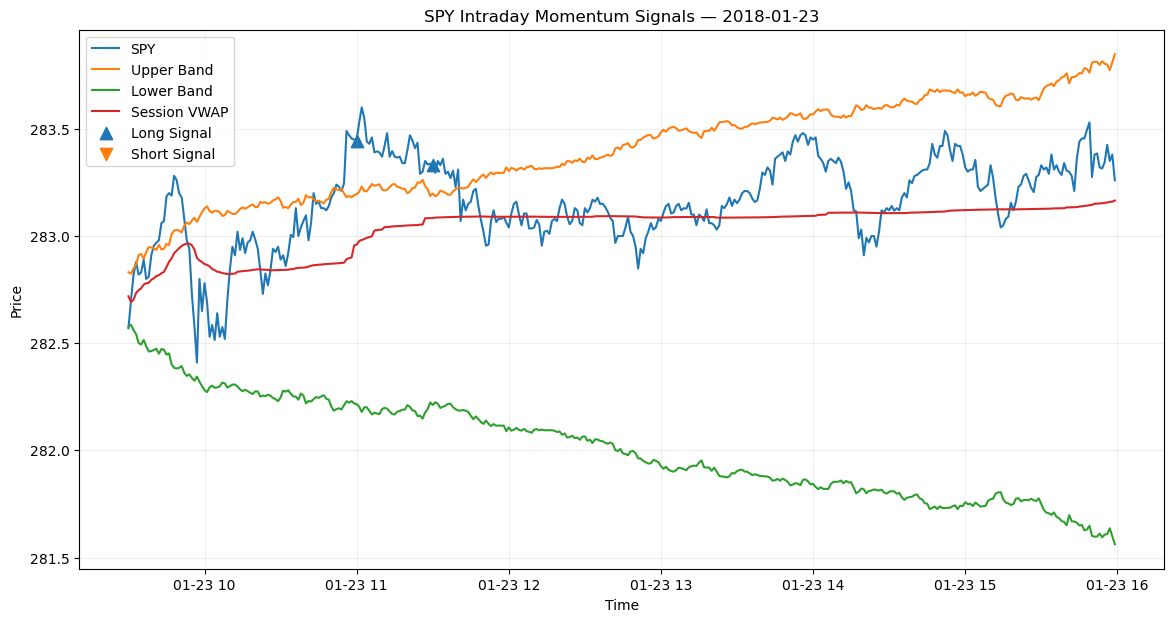

In [58]:
signal_dates = (
    df.loc[df["raw_signal"] != 0, "date"]
      .drop_duplicates()
      .reset_index(drop=True)
)

plot_date = signal_dates.iloc[0]

day = df[df["date"] == plot_date].copy()

long_signals = day[
    day["decision_time"]
    & (day["raw_signal"] == 1)
]

short_signals = day[
    day["decision_time"]
    & (day["raw_signal"] == -1)
]

plt.figure(figsize=(14, 7))

plt.plot(
    day["datetime"],
    day["close"],
    label="SPY"
)

plt.plot(
    day["datetime"],
    day["upper_band"],
    label="Upper Band"
)

plt.plot(
    day["datetime"],
    day["lower_band"],
    label="Lower Band"
)

plt.plot(
    day["datetime"],
    day["session_vwap"],
    label="Session VWAP"
)

plt.scatter(
    long_signals["datetime"],
    long_signals["open"],
    marker="^",
    s=80,
    label="Long Signal"
)

plt.scatter(
    short_signals["datetime"],
    short_signals["open"],
    marker="v",
    s=80,
    label="Short Signal"
)

plt.title(
    f"SPY Intraday Momentum Signals — {plot_date.date()}"
)

plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [60]:
FEATURE_FILE = (
    DATA_PROCESSED
    / "SPY_1min_features.csv"
)

df.to_csv(
    FEATURE_FILE,
    index=False
)

print("Saved:")
print(FEATURE_FILE)

print("\nShape:")
print(df.shape)

Saved:
data\processed\SPY_1min_features.csv

Shape:
(613470, 27)


# Backtesting

## Baseline Backtest

The first backtest replicates the simple version of the paper's
intraday momentum strategy.

Rules:

- Evaluate signals every 30 minutes from 10:00 to 15:30.
- Long when price exceeds the Upper Noise Boundary.
- Short when price falls below the Lower Noise Boundary.
- If already long, remain long until price crosses the Lower Boundary.
- If already short, remain short until price crosses the Upper Boundary.
- Reverse the position after an opposite-band crossing.
- Close all positions at the end of the trading session.
- Use fixed 1x notional exposure.
- Include commission and slippage.

In [65]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PROCESSED = Path("data/processed")
OUTPUT = Path("output")
RESULTS_DIR = OUTPUT / "results"

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FEATURE_FILE = DATA_PROCESSED / "SPY_1min_features.csv"

INITIAL_CAPITAL = 100_000

COMMISSION_PER_SHARE = 0.0035
SLIPPAGE_PER_SHARE = 0.001

df_bt = pd.read_csv(
    FEATURE_FILE,
    parse_dates=["datetime"]
)

print("Loaded:", FEATURE_FILE)
print("Shape:", df_bt.shape)

display(df_bt.head())

Loaded: data\processed\SPY_1min_features.csv
Shape: (613470, 27)


,datetime,symbol,open,high,low,close,volume,trade_count,vwap,date,time,hour,minute,minute_of_day,day_open,prev_close,abs_move_from_open,sigma_14,upper_band,lower_band,vwap_x_volume,cum_vwap_volume,cum_volume,session_vwap,session_vwap_prev,decision_time,raw_signal
0,2018-01-02 09:30:00,SPY,267.840,267.89,267.67,267.7300,1221610.0,2416.0,267.800296,2018-01-02,09:30:00,9,30,570,267.84,NaN,0.000411,NaN,NaN,NaN,3.271475e+08,3.271475e+08,1221610.0,267.800296,NaN,False,0
1,2018-01-02 09:31:00,SPY,267.730,267.74,267.60,267.6199,483876.0,1512.0,267.662334,2018-01-02,09:31:00,9,31,571,267.84,NaN,0.000822,NaN,NaN,NaN,1.295154e+08,4.566629e+08,1705486.0,267.761154,267.800296,False,0
2,2018-01-02 09:32:00,SPY,267.615,267.77,267.60,267.6900,269917.0,1121.0,267.710822,2018-01-02,09:32:00,9,32,572,267.84,NaN,0.000560,NaN,NaN,NaN,7.225970e+07,5.289226e+08,1975403.0,267.754277,267.761154,False,0
3,2018-01-02 09:33:00,SPY,267.690,267.70,267.54,267.5500,309337.0,1160.0,267.624496,2018-01-02,09:33:00,9,33,573,267.84,NaN,0.001083,NaN,NaN,NaN,8.278616e+07,6.117088e+08,2284740.0,267.736705,267.754277,False,0
4,2018-01-02 09:34:00,SPY,267.545,267.60,267.46,267.4700,326513.0,1312.0,267.512756,2018-01-02,09:34:00,9,34,574,267.84,NaN,0.001381,NaN,NaN,NaN,8.734639e+07,6.990552e+08,2611253.0,267.708702,267.736705,False,0


In [67]:
df_bt = (
    df_bt.sort_values("datetime")
         .reset_index(drop=True)
)

df_bt["date"] = df_bt["datetime"].dt.normalize()

df_bt["hour"] = df_bt["datetime"].dt.hour
df_bt["minute"] = df_bt["datetime"].dt.minute

df_bt["minute_of_day"] = (
    df_bt["hour"] * 60
    + df_bt["minute"]
)

df_bt["decision_time"] = (
    df_bt["minute"].isin([0, 30])
    &
    (df_bt["minute_of_day"] >= 600)   # 10:00
    &
    (df_bt["minute_of_day"] <= 930)   # 15:30
)

display(
    df_bt[
        [
            "datetime",
            "date",
            "open",
            "upper_band",
            "lower_band",
            "decision_time"
        ]
    ].dropna().head()
)

,datetime,date,open,upper_band,lower_band,decision_time
5460,2018-01-23 09:30:00,2018-01-23,282.74,282.831149,282.578874,False
5461,2018-01-23 09:31:00,2018-01-23,282.57,282.824150,282.585871,False
5462,2018-01-23 09:32:00,2018-01-23,282.69,282.849218,282.560809,False
5463,2018-01-23 09:33:00,2018-01-23,282.82,282.867238,282.542794,False
5464,2018-01-23 09:34:00,2018-01-23,282.88,282.909712,282.500330,False


In [69]:
required_backtest_columns = [
    "datetime",
    "date",
    "open",
    "close",
    "upper_band",
    "lower_band",
    "session_vwap_prev",
    "decision_time"
]

missing = [
    col
    for col in required_backtest_columns
    if col not in df_bt.columns
]

if missing:
    raise ValueError(
        f"Missing required backtest columns: {missing}"
    )

print("Required columns: OK")

print(
    "Date range:",
    df_bt["datetime"].min(),
    "->",
    df_bt["datetime"].max()
)

print(
    "Trading days:",
    df_bt["date"].nunique()
)

print(
    "Usable strategy days:",
    df_bt.loc[
        df_bt["upper_band"].notna(),
        "date"
    ].nunique()
)

print("\nDecision times per day:")

display(
    df_bt.groupby("date")["decision_time"]
         .sum()
         .value_counts()
         .sort_index()
)

Required columns: OK
Date range: 2018-01-02 09:30:00 -> 2024-04-30 15:59:00
Trading days: 1573
Usable strategy days: 1559

Decision times per day:


decision_time
12    1573
Name: count, dtype: int64

## Backtest State

At every semi-hourly decision time, the portfolio can be in one of three states:

- `0`: flat
- `1`: long SPY
- `-1`: short SPY

Baseline rules:

### Flat
- `price > upper_band` → enter long
- `price < lower_band` → enter short
- otherwise remain flat

### Long
- remain long unless price crosses below the lower band
- if lower band is crossed, close long and reverse short

### Short
- remain short unless price crosses above the upper band
- if upper band is crossed, close short and reverse long

Any remaining position is closed at the end of the trading day.

## Baseline Backtesting Function

In [74]:
def run_baseline_backtest(
    data,
    initial_capital=100_000,
    commission_per_share=0.0035,
    slippage_per_share=0.001
):
    """
    Baseline intraday momentum strategy.

    Rules
    -----
    1. Evaluate signals at 10:00, 10:30, ..., 15:30.
    2. Enter long when price > upper Noise Area boundary.
    3. Enter short when price < lower Noise Area boundary.
    4. Long positions reverse short after crossing lower band.
    5. Short positions reverse long after crossing upper band.
    6. Close any remaining position at the end of the day.
    7. Use fixed 1x daily notional exposure.
    8. Include per-share commission and slippage.
    """

    # Current portfolio value
    equity = initial_capital

    # One row per backtested trading day
    daily_results = []

    # One row per completed trade
    trades = []

    # Loop for long 
    for date, day in data.groupby("date", sort=True):

        day = (
            day.sort_values("datetime")
               .copy()
        )

        if day["upper_band"].isna().all():
            continue

        start_equity = equity

        day_open = day["open"].iloc[0]

        shares = int(
            np.floor(
                start_equity / day_open
            )
        )

        if shares <= 0:
            continue

        position = 0

        entry_price = None
        entry_time = None

        day_pnl = 0.0

        # Only inspect semi-hourly trading timestamps
        decision_rows = day.loc[
            day["decision_time"]
        ]

        # Intraday decision loop
        for _, row in decision_rows.iterrows():

            if pd.isna(row["upper_band"]):
                continue

            price = row["open"]

            upper = row["upper_band"]
            lower = row["lower_band"]

            # Flat position
            if position == 0:

                # LONG ENTRY
                if price > upper:

                    entry_price = (
                        price
                        + slippage_per_share
                    )

                    entry_time = row["datetime"]

                    position = 1

                # SHORT ENTRY
                elif price < lower:

                    entry_price = (
                        price
                        - slippage_per_share
                    )

                    entry_time = row["datetime"]

                    position = -1

            elif position == 1:

                # Long stop = opposite/lower boundary
                if price < lower:

                    exit_price = (
                        price
                        - slippage_per_share
                    )

                    gross_pnl = (
                        shares
                        * (exit_price - entry_price)
                    )

                    commission = (
                        2
                        * shares
                        * commission_per_share
                    )

                    net_pnl = (
                        gross_pnl
                        - commission
                    )

                    day_pnl += net_pnl

                    trades.append({
                        "date": date,
                        "side": "LONG",
                        "entry_time": entry_time,
                        "exit_time": row["datetime"],
                        "entry_price": entry_price,
                        "exit_price": exit_price,
                        "shares": shares,
                        "gross_pnl": gross_pnl,
                        "commission": commission,
                        "net_pnl": net_pnl,
                        "exit_reason": "opposite_band"
                    })

                    # Immediately reverse SHORT
                    entry_price = (
                        price
                        - slippage_per_share
                    )

                    entry_time = row["datetime"]

                    position = -1

            elif position == -1:

                # Short stop = opposite/upper boundary
                if price > upper:

                    exit_price = (
                        price
                        + slippage_per_share
                    )

                    gross_pnl = (
                        shares
                        * (entry_price - exit_price)
                    )

                    commission = (
                        2
                        * shares
                        * commission_per_share
                    )

                    net_pnl = (
                        gross_pnl
                        - commission
                    )

                    day_pnl += net_pnl

                    trades.append({
                        "date": date,
                        "side": "SHORT",
                        "entry_time": entry_time,
                        "exit_time": row["datetime"],
                        "entry_price": entry_price,
                        "exit_price": exit_price,
                        "shares": shares,
                        "gross_pnl": gross_pnl,
                        "commission": commission,
                        "net_pnl": net_pnl,
                        "exit_reason": "opposite_band"
                    })

                    # Immediately reverse LONG
                    entry_price = (
                        price
                        + slippage_per_share
                    )

                    entry_time = row["datetime"]

                    position = 1

        # Market close exit
        close_price = day["close"].iloc[-1]
        close_time = day["datetime"].iloc[-1]

        if position == 1:

            exit_price = (
                close_price
                - slippage_per_share
            )

            gross_pnl = (
                shares
                * (exit_price - entry_price)
            )

            commission = (
                2
                * shares
                * commission_per_share
            )

            net_pnl = (
                gross_pnl
                - commission
            )

            day_pnl += net_pnl

            trades.append({
                "date": date,
                "side": "LONG",
                "entry_time": entry_time,
                "exit_time": close_time,
                "entry_price": entry_price,
                "exit_price": exit_price,
                "shares": shares,
                "gross_pnl": gross_pnl,
                "commission": commission,
                "net_pnl": net_pnl,
                "exit_reason": "market_close"
            })

        elif position == -1:

            exit_price = (
                close_price
                + slippage_per_share
            )

            gross_pnl = (
                shares
                * (entry_price - exit_price)
            )

            commission = (
                2
                * shares
                * commission_per_share
            )

            net_pnl = (
                gross_pnl
                - commission
            )

            day_pnl += net_pnl

            trades.append({
                "date": date,
                "side": "SHORT",
                "entry_time": entry_time,
                "exit_time": close_time,
                "entry_price": entry_price,
                "exit_price": exit_price,
                "shares": shares,
                "gross_pnl": gross_pnl,
                "commission": commission,
                "net_pnl": net_pnl,
                "exit_reason": "market_close"
            })

        # Update portfolio equity
        equity = (
            start_equity
            + day_pnl
        )

        daily_return = (
            equity / start_equity
            - 1
        )

        daily_results.append({
            "date": date,
            "start_equity": start_equity,
            "end_equity": equity,
            "pnl": day_pnl,
            "return": daily_return,
            "shares": shares
        })

    # Convert output lists into DataFrames
    daily_results = pd.DataFrame(
        daily_results
    )

    trades = pd.DataFrame(
        trades
    )

    return daily_results, trades

In [79]:
# Run baseline function

baseline_daily, baseline_trades = (
    run_baseline_backtest(
        df_bt,
        initial_capital=INITIAL_CAPITAL,
        commission_per_share=COMMISSION_PER_SHARE,
        slippage_per_share=SLIPPAGE_PER_SHARE
    )
)

print("Backtested days:")
print(len(baseline_daily))

print("\nCompleted trades:")
print(len(baseline_trades))

print("\nInitial equity:")
print(f"${INITIAL_CAPITAL:,.2f}")

print("\nFinal equity:")
print(
    f"${baseline_daily['end_equity'].iloc[-1]:,.2f}"
)

Backtested days:
1559

Completed trades:
964

Initial equity:
$100,000.00

Final equity:
$147,389.87


In [81]:
display(
    baseline_daily.head(10)
)

print("\nLast 5 days:")

display(
    baseline_daily.tail()
)

,date,start_equity,end_equity,pnl,return,shares
0,2018-01-23,100000.0000,99931.5180,-68.4820,-0.000685,353
1,2018-01-24,99931.5180,99931.5180,0.0000,0.000000,351
2,2018-01-25,99931.5180,99931.5180,0.0000,0.000000,351
3,2018-01-26,99931.5180,100560.1590,628.6410,0.006291,351
4,2018-01-29,100560.1590,100757.0700,196.9110,0.001958,351
5,2018-01-30,100757.0700,100871.3460,114.2760,0.001134,356
6,2018-01-31,100871.3460,100871.3460,0.0000,0.000000,356
7,2018-02-01,100871.3460,100418.6908,-452.6552,-0.004487,358
8,2018-02-02,100418.6908,101800.9646,1382.2738,0.013765,358
9,2018-02-05,101800.9646,104528.0966,2727.1320,0.026789,372



Last 5 days:


,date,start_equity,end_equity,pnl,return,shares
1554,2024-04-24,148024.493,147516.705,-507.788,-0.003430,292
1555,2024-04-25,147516.705,145968.250,-1548.455,-0.010497,295
1556,2024-04-26,145968.250,146080.858,112.608,0.000771,288
1557,2024-04-29,146080.858,146080.858,0.000,0.000000,286
1558,2024-04-30,146080.858,147389.865,1309.007,0.008961,287


In [83]:
accounting_check = np.allclose(
    baseline_daily["end_equity"],
    baseline_daily["start_equity"]
    + baseline_daily["pnl"]
)

print(
    "Daily accounting correct:",
    accounting_check
)

Daily accounting correct: True


In [85]:
display(
    baseline_trades.head(20)
)

print("\nTrade columns:")
print(
    baseline_trades.columns.tolist()
)

print("\nExit reasons:")
display(
    baseline_trades["exit_reason"]
    .value_counts()
)

print("\nLong / Short:")
display(
    baseline_trades["side"]
    .value_counts()
)

,date,side,entry_time,exit_time,entry_price,exit_price,shares,gross_pnl,commission,net_pnl,exit_reason
0,2018-01-23,LONG,2018-01-23 11:00:00,2018-01-23 15:59:00,283.4460,283.259,353,-66.0110,2.471,-68.4820,market_close
1,2018-01-26,LONG,2018-01-26 11:30:00,2018-01-26 15:59:00,284.7710,286.569,351,631.0980,2.457,628.6410,market_close
2,2018-01-29,SHORT,2018-01-29 11:00:00,2018-01-29 15:59:00,285.2490,284.681,351,199.3680,2.457,196.9110,market_close
3,2018-01-30,SHORT,2018-01-30 10:00:00,2018-01-30 15:59:00,281.9890,281.661,356,116.7680,2.492,114.2760,market_close
4,2018-02-01,LONG,2018-02-01 12:00:00,2018-02-01 15:59:00,282.8564,281.599,358,-450.1492,2.506,-452.6552,market_close
5,2018-02-02,SHORT,2018-02-02 10:00:00,2018-02-02 15:59:00,279.3891,275.521,358,1384.7798,2.506,1382.2738,market_close
6,2018-02-05,SHORT,2018-02-05 13:30:00,2018-02-05 15:59:00,271.5190,264.181,372,2729.7360,2.604,2727.1320,market_close
7,2018-02-06,LONG,2018-02-06 10:00:00,2018-02-06 15:59:00,265.8210,269.179,402,1349.9160,2.814,1347.1020,market_close
8,2018-02-07,LONG,2018-02-07 10:00:00,2018-02-07 15:59:00,270.0610,267.659,394,-946.3880,2.758,-949.1460,market_close
9,2018-02-08,SHORT,2018-02-08 10:30:00,2018-02-08 15:59:00,266.0590,257.721,391,3260.1580,2.737,3257.4210,market_close



Trade columns:
['date', 'side', 'entry_time', 'exit_time', 'entry_price', 'exit_price', 'shares', 'gross_pnl', 'commission', 'net_pnl', 'exit_reason']

Exit reasons:


exit_reason
market_close     920
opposite_band     44
Name: count, dtype: int64


Long / Short:


side
LONG     498
SHORT    466
Name: count, dtype: int64

In [87]:
baseline_trades["entry_time"] = pd.to_datetime(
    baseline_trades["entry_time"]
)

baseline_trades["exit_time"] = pd.to_datetime(
    baseline_trades["exit_time"]
)

print(
    "All exits occur after or at entry:",
    (
        baseline_trades["exit_time"]
        >= baseline_trades["entry_time"]
    ).all()
)

print(
    "No overnight trades:",
    (
        baseline_trades["entry_time"].dt.normalize()
        ==
        baseline_trades["exit_time"].dt.normalize()
    ).all()
)

print(
    "All shares positive:",
    (
        baseline_trades["shares"] > 0
    ).all()
)

All exits occur after or at entry: True
No overnight trades: True
All shares positive: True


In [89]:
# Manual check
example_trade_date = (
    baseline_trades["date"]
    .iloc[0]
)

print("Checking date:")
print(example_trade_date)

print("\nTrades:")

display(
    baseline_trades.loc[
        baseline_trades["date"]
        == example_trade_date
    ]
)

print("\nDecision points:")

display(
    df_bt.loc[
        (df_bt["date"] == example_trade_date)
        &
        (df_bt["decision_time"]),
        [
            "datetime",
            "open",
            "lower_band",
            "upper_band"
        ]
    ]
)

Checking date:
2018-01-23 00:00:00

Trades:


,date,side,entry_time,exit_time,entry_price,exit_price,shares,gross_pnl,commission,net_pnl,exit_reason
0,2018-01-23,LONG,2018-01-23 11:00:00,2018-01-23 15:59:00,283.446,283.259,353,-66.011,2.471,-68.482,market_close



Decision points:


,datetime,open,lower_band,upper_band
5490,2018-01-23 10:00:00,282.650,282.280905,283.129191
5520,2018-01-23 10:30:00,282.960,282.246875,283.163229
5550,2018-01-23 11:00:00,283.445,282.215519,283.194594
5580,2018-01-23 11:30:00,283.330,282.211773,283.198340
5610,2018-01-23 12:00:00,283.060,282.107227,283.302913
5640,2018-01-23 12:30:00,283.045,282.065358,283.344791
5670,2018-01-23 13:00:00,283.080,281.925806,283.484378
5700,2018-01-23 13:30:00,283.170,281.902881,283.507309
5730,2018-01-23 14:00:00,283.470,281.843491,283.566714
5760,2018-01-23 14:30:00,283.140,281.806642,283.603571


In [91]:
from pathlib import Path

DATA_PROCESSED = Path("data/processed")
RESULTS_DIR = Path("output/results")

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_FILE = DATA_PROCESSED / "SPY_1min_features.csv"

if "df" in globals():
    df.to_csv(
        FEATURE_FILE,
        index=False
    )

    print("Saved feature data:")
    print(FEATURE_FILE)
    print("Shape:", df.shape)

else:
    print("df not currently in memory — feature file not rewritten.")

if "baseline_daily" in globals():

    baseline_daily.to_csv(
        RESULTS_DIR / "baseline_daily.csv",
        index=False
    )

    print("\nSaved baseline_daily.csv")

if "baseline_trades" in globals():

    baseline_trades.to_csv(
        RESULTS_DIR / "baseline_trades.csv",
        index=False
    )

    print("Saved baseline_trades.csv")

print("\nCheckpoint complete.")

Saved feature data:
data\processed\SPY_1min_features.csv
Shape: (613470, 27)

Saved baseline_daily.csv
Saved baseline_trades.csv

Checkpoint complete.


# Optimize code

In [2]:
from pathlib import Path

SRC = Path("src")
SRC.mkdir(exist_ok=True)

(SRC / "__init__.py").touch()

print("Created:")
print(SRC.resolve())
print((SRC / "__init__.py").resolve())

Created:
C:\Users\Arty\OneDrive\Рабочий стол\Python Scripts\Algo Trading WUTIS\src
C:\Users\Arty\OneDrive\Рабочий стол\Python Scripts\Algo Trading WUTIS\src\__init__.py


In [4]:
%%writefile src/config.py

from pathlib import Path
import pandas as pd

# PROJECT PATHS

PROJECT_ROOT = Path(__file__).resolve().parents[1]

DATA_DIR = PROJECT_ROOT / "data"
DATA_RAW = DATA_DIR / "raw"
DATA_PROCESSED = DATA_DIR / "processed"

OUTPUT_DIR = PROJECT_ROOT / "output"
RESULTS_DIR = OUTPUT_DIR / "results"

CLEAN_FILE = DATA_PROCESSED / "SPY_1min_clean.csv"
FEATURE_FILE = DATA_PROCESSED / "SPY_1min_features.csv"

# FEATURE PARAMETERS

LOOKBACK = 14
VOL_MULTIPLIER = 1.0

# BACKTEST PARAMETERS

INITIAL_CAPITAL = 100_000

COMMISSION_PER_SHARE = 0.0035
SLIPPAGE_PER_SHARE = 0.001

# DYNAMIC SIZING PARAMETERS

TARGET_DAILY_VOL = 0.02
MAX_LEVERAGE = 4.0

# TRAIN / TEST SPLIT

TRAIN_END = pd.Timestamp("2022-12-31")

Writing src/config.py


In [6]:
%%writefile src/features.py

import numpy as np
import pandas as pd


def prepare_datetime(data):
    """
    Standardize the timestamp column and convert timestamps
    to timezone-naive New York market time.
    """

    df = data.copy()

    # Standardize column name

    if "datetime" not in df.columns:

        if "timestamp" in df.columns:
            df = df.rename(
                columns={"timestamp": "datetime"}
            )

        else:
            raise ValueError(
                "Neither 'datetime' nor 'timestamp' column found."
            )

    # Parse timestamps

    if not pd.api.types.is_datetime64_any_dtype(
        df["datetime"]
    ):

        df["datetime"] = pd.to_datetime(
            df["datetime"],
            utc=True
        )

        df["datetime"] = (
            df["datetime"]
            .dt.tz_convert("America/New_York")
            .dt.tz_localize(None)
        )

    elif getattr(
        df["datetime"].dt,
        "tz",
        None
    ) is not None:

        df["datetime"] = (
            df["datetime"]
            .dt.tz_convert("America/New_York")
            .dt.tz_localize(None)
        )

    df = (
        df.sort_values("datetime")
          .reset_index(drop=True)
    )

    return df


def build_features(
    data,
    lookback=14,
    vol_multiplier=1.0
):
    """
    Construct the features required for the SPY intraday
    momentum strategy.

    Includes:
    - date/time variables
    - daily open
    - previous close
    - absolute movement from daily open
    - time-of-day rolling average movement
    - upper/lower Noise Area boundaries
    - cumulative session VWAP
    - lagged session VWAP
    - semi-hourly decision timestamps
    - raw momentum signal
    """

    df = prepare_datetime(data)

    # TIME VARIABLES

    df["date"] = (
        df["datetime"]
        .dt.normalize()
    )

    df["time"] = (
        df["datetime"]
        .dt.time
    )

    df["hour"] = (
        df["datetime"]
        .dt.hour
    )

    df["minute"] = (
        df["datetime"]
        .dt.minute
    )

    df["minute_of_day"] = (
        df["hour"] * 60
        + df["minute"]
    )

    # DAILY OPEN

    df["day_open"] = (
        df.groupby("date")["open"]
          .transform("first")
    )

    # PREVIOUS TRADING DAY CLOSE

    daily_close = (
        df.groupby("date")["close"]
          .last()
    )

    prev_close = (
        daily_close.shift(1)
    )

    df["prev_close"] = (
        df["date"]
        .map(prev_close)
    )

    # ABSOLUTE MOVE FROM OPEN

    df["abs_move_from_open"] = np.abs(
        df["close"]
        / df["day_open"]
        - 1
    )

    # TIME-OF-DAY HISTORICAL MOVE

    df["sigma_14"] = (
        df.groupby(
            "minute_of_day"
        )["abs_move_from_open"]
        .transform(
            lambda x:
                x.shift(1)
                 .rolling(
                     window=lookback,
                     min_periods=lookback
                 )
                 .mean()
        )
    )

    # NOISE AREA

    upper_reference = np.maximum(
        df["day_open"],
        df["prev_close"]
    )

    lower_reference = np.minimum(
        df["day_open"],
        df["prev_close"]
    )

    df["upper_band"] = (
        upper_reference
        * (
            1
            + vol_multiplier
            * df["sigma_14"]
        )
    )

    df["lower_band"] = (
        lower_reference
        * (
            1
            - vol_multiplier
            * df["sigma_14"]
        )
    )

    # CUMULATIVE SESSION VWAP

    required_vwap_columns = [
        "vwap",
        "volume"
    ]

    missing = [
        col
        for col in required_vwap_columns
        if col not in df.columns
    ]

    if missing:
        raise ValueError(
            f"Missing VWAP columns: {missing}"
        )

    df["vwap_x_volume"] = (
        df["vwap"]
        * df["volume"]
    )

    df["cum_vwap_volume"] = (
        df.groupby("date")[
            "vwap_x_volume"
        ]
        .cumsum()
    )

    df["cum_volume"] = (
        df.groupby("date")["volume"]
          .cumsum()
    )

    df["session_vwap"] = (
        df["cum_vwap_volume"]
        / df["cum_volume"]
    )

    # Only information available before current minute
    df["session_vwap_prev"] = (
        df.groupby("date")[
            "session_vwap"
        ]
        .shift(1)
    )

    # DECISION TIMES

    df["decision_time"] = (
        df["minute"].isin([0, 30])
        &
        (df["minute_of_day"] >= 600)
        &
        (df["minute_of_day"] <= 930)
    )

    # RAW SIGNAL

    df["raw_signal"] = 0

    df.loc[
        df["decision_time"]
        & (
            df["open"]
            > df["upper_band"]
        ),
        "raw_signal"
    ] = 1

    df.loc[
        df["decision_time"]
        & (
            df["open"]
            < df["lower_band"]
        ),
        "raw_signal"
    ] = -1

    return df

Writing src/features.py


In [8]:
%%writefile src/backtest.py

import numpy as np
import pandas as pd


def run_baseline_backtest(
    data,
    initial_capital=100_000,
    commission_per_share=0.0035,
    slippage_per_share=0.001
):
    """
    Baseline SPY intraday momentum strategy.

    Rules
    -----
    - Evaluate at semi-hourly decision times.
    - Enter long above the upper Noise Area boundary.
    - Enter short below the lower Noise Area boundary.
    - Long reverses short after crossing the lower boundary.
    - Short reverses long after crossing the upper boundary.
    - Close all exposure at the end of the trading day.
    - Fixed 1x daily notional exposure.
    - Commission and slippage included.
    """

    equity = initial_capital

    daily_results = []
    trades = []

    # LOOP THROUGH TRADING DAYS

    for date, day in data.groupby(
        "date",
        sort=True
    ):

        day = (
            day.sort_values("datetime")
               .copy()
        )

        # Skip feature warm-up period
        if day["upper_band"].isna().all():
            continue

        start_equity = equity

        day_open = (
            day["open"].iloc[0]
        )

        # POSITION SIZE

        shares = int(
            np.floor(
                start_equity
                / day_open
            )
        )

        if shares <= 0:
            continue

        # INITIAL STATE

        position = 0

        entry_price = None
        entry_time = None

        day_pnl = 0.0

        decision_rows = (
            day.loc[
                day["decision_time"]
            ]
        )

        # INTRADAY DECISION LOOP

        for _, row in decision_rows.iterrows():

            if pd.isna(
                row["upper_band"]
            ):
                continue

            price = row["open"]

            upper = row["upper_band"]
            lower = row["lower_band"]

            # FLAT

            if position == 0:

                # LONG ENTRY
                if price > upper:

                    entry_price = (
                        price
                        + slippage_per_share
                    )

                    entry_time = (
                        row["datetime"]
                    )

                    position = 1

                # SHORT ENTRY
                elif price < lower:

                    entry_price = (
                        price
                        - slippage_per_share
                    )

                    entry_time = (
                        row["datetime"]
                    )

                    position = -1

            # LONG

            elif position == 1:

                if price < lower:

                    exit_price = (
                        price
                        - slippage_per_share
                    )

                    gross_pnl = (
                        shares
                        * (
                            exit_price
                            - entry_price
                        )
                    )

                    commission = (
                        2
                        * shares
                        * commission_per_share
                    )

                    net_pnl = (
                        gross_pnl
                        - commission
                    )

                    day_pnl += net_pnl

                    trades.append({
                        "date": date,
                        "side": "LONG",
                        "entry_time": entry_time,
                        "exit_time": row["datetime"],
                        "entry_price": entry_price,
                        "exit_price": exit_price,
                        "shares": shares,
                        "gross_pnl": gross_pnl,
                        "commission": commission,
                        "net_pnl": net_pnl,
                        "exit_reason": "opposite_band"
                    })

                    # Reverse into SHORT
                    entry_price = (
                        price
                        - slippage_per_share
                    )

                    entry_time = (
                        row["datetime"]
                    )

                    position = -1

            # SHORT

            elif position == -1:

                if price > upper:

                    exit_price = (
                        price
                        + slippage_per_share
                    )

                    gross_pnl = (
                        shares
                        * (
                            entry_price
                            - exit_price
                        )
                    )

                    commission = (
                        2
                        * shares
                        * commission_per_share
                    )

                    net_pnl = (
                        gross_pnl
                        - commission
                    )

                    day_pnl += net_pnl

                    trades.append({
                        "date": date,
                        "side": "SHORT",
                        "entry_time": entry_time,
                        "exit_time": row["datetime"],
                        "entry_price": entry_price,
                        "exit_price": exit_price,
                        "shares": shares,
                        "gross_pnl": gross_pnl,
                        "commission": commission,
                        "net_pnl": net_pnl,
                        "exit_reason": "opposite_band"
                    })

                    # Reverse into LONG
                    entry_price = (
                        price
                        + slippage_per_share
                    )

                    entry_time = (
                        row["datetime"]
                    )

                    position = 1

        # END-OF-DAY EXIT

        close_price = (
            day["close"].iloc[-1]
        )

        close_time = (
            day["datetime"].iloc[-1]
        )

        # CLOSE LONG

        if position == 1:

            exit_price = (
                close_price
                - slippage_per_share
            )

            gross_pnl = (
                shares
                * (
                    exit_price
                    - entry_price
                )
            )

            commission = (
                2
                * shares
                * commission_per_share
            )

            net_pnl = (
                gross_pnl
                - commission
            )

            day_pnl += net_pnl

            trades.append({
                "date": date,
                "side": "LONG",
                "entry_time": entry_time,
                "exit_time": close_time,
                "entry_price": entry_price,
                "exit_price": exit_price,
                "shares": shares,
                "gross_pnl": gross_pnl,
                "commission": commission,
                "net_pnl": net_pnl,
                "exit_reason": "market_close"
            })

        # CLOSE SHORT

        elif position == -1:

            exit_price = (
                close_price
                + slippage_per_share
            )

            gross_pnl = (
                shares
                * (
                    entry_price
                    - exit_price
                )
            )

            commission = (
                2
                * shares
                * commission_per_share
            )

            net_pnl = (
                gross_pnl
                - commission
            )

            day_pnl += net_pnl

            trades.append({
                "date": date,
                "side": "SHORT",
                "entry_time": entry_time,
                "exit_time": close_time,
                "entry_price": entry_price,
                "exit_price": exit_price,
                "shares": shares,
                "gross_pnl": gross_pnl,
                "commission": commission,
                "net_pnl": net_pnl,
                "exit_reason": "market_close"
            })

        # PORTFOLIO UPDATE
        

        equity = (
            start_equity
            + day_pnl
        )

        daily_return = (
            equity
            / start_equity
            - 1
        )

        daily_results.append({
            "date": date,
            "start_equity": start_equity,
            "end_equity": equity,
            "pnl": day_pnl,
            "return": daily_return,
            "shares": shares
        })

    daily_results = pd.DataFrame(
        daily_results
    )

    trades = pd.DataFrame(
        trades
    )

    return daily_results, trades

Writing src/backtest.py


In [10]:
from pathlib import Path

for file in [
    "src/__init__.py",
    "src/config.py",
    "src/features.py",
    "src/backtest.py",
]:
    path = Path(file)

    print(
        f"{file:<25}",
        "OK" if path.exists() else "MISSING"
    )

src/__init__.py           OK
src/config.py             OK
src/features.py           OK
src/backtest.py           OK


## Test imports

In [13]:
from src.config import (
    FEATURE_FILE,
    INITIAL_CAPITAL,
    COMMISSION_PER_SHARE,
    SLIPPAGE_PER_SHARE,
    LOOKBACK,
    VOL_MULTIPLIER,
)

from src.features import build_features
from src.backtest import run_baseline_backtest

print("Imports successful.")

print("\nFeature file:")
print(FEATURE_FILE)

print("\nParameters:")
print("LOOKBACK =", LOOKBACK)
print("VOL_MULTIPLIER =", VOL_MULTIPLIER)
print("INITIAL_CAPITAL =", INITIAL_CAPITAL)
print("COMMISSION =", COMMISSION_PER_SHARE)
print("SLIPPAGE =", SLIPPAGE_PER_SHARE)

Imports successful.

Feature file:
C:\Users\Arty\OneDrive\Рабочий стол\Python Scripts\Algo Trading WUTIS\data\processed\SPY_1min_features.csv

Parameters:
LOOKBACK = 14
VOL_MULTIPLIER = 1.0
INITIAL_CAPITAL = 100000
COMMISSION = 0.0035
SLIPPAGE = 0.001


In [15]:
# allow automatic updates

%load_ext autoreload
%autoreload 2

In [17]:
# BACKTESTING SETUP

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import (
    FEATURE_FILE,
    RESULTS_DIR,
    INITIAL_CAPITAL,
    COMMISSION_PER_SHARE,
    SLIPPAGE_PER_SHARE,
)

from src.backtest import (
    run_baseline_backtest
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

df_bt = pd.read_csv(
    FEATURE_FILE,
    parse_dates=["datetime"]
)

print("Loaded:")
print(FEATURE_FILE)

print("\nShape:")
print(df_bt.shape)

display(df_bt.head())

Loaded:
C:\Users\Arty\OneDrive\Рабочий стол\Python Scripts\Algo Trading WUTIS\data\processed\SPY_1min_features.csv

Shape:
(613470, 27)


,datetime,symbol,open,high,low,close,volume,trade_count,vwap,date,...,sigma_14,upper_band,lower_band,vwap_x_volume,cum_vwap_volume,cum_volume,session_vwap,session_vwap_prev,decision_time,raw_signal
0,2018-01-02 09:30:00,SPY,267.840,267.89,267.67,267.7300,1221610.0,2416.0,267.800296,2018-01-02,...,NaN,NaN,NaN,3.271475e+08,3.271475e+08,1221610.0,267.800296,NaN,False,0
1,2018-01-02 09:31:00,SPY,267.730,267.74,267.60,267.6199,483876.0,1512.0,267.662334,2018-01-02,...,NaN,NaN,NaN,1.295154e+08,4.566629e+08,1705486.0,267.761154,267.800296,False,0
2,2018-01-02 09:32:00,SPY,267.615,267.77,267.60,267.6900,269917.0,1121.0,267.710822,2018-01-02,...,NaN,NaN,NaN,7.225970e+07,5.289226e+08,1975403.0,267.754277,267.761154,False,0
3,2018-01-02 09:33:00,SPY,267.690,267.70,267.54,267.5500,309337.0,1160.0,267.624496,2018-01-02,...,NaN,NaN,NaN,8.278616e+07,6.117088e+08,2284740.0,267.736705,267.754277,False,0
4,2018-01-02 09:34:00,SPY,267.545,267.60,267.46,267.4700,326513.0,1312.0,267.512756,2018-01-02,...,NaN,NaN,NaN,8.734639e+07,6.990552e+08,2611253.0,267.708702,267.736705,False,0


In [19]:
baseline_daily, baseline_trades = (
    run_baseline_backtest(
        df_bt,
        initial_capital=INITIAL_CAPITAL,
        commission_per_share=COMMISSION_PER_SHARE,
        slippage_per_share=SLIPPAGE_PER_SHARE
    )
)

print("Backtested days:")
print(len(baseline_daily))

print("\nCompleted trades:")
print(len(baseline_trades))

print("\nInitial equity:")
print(f"${INITIAL_CAPITAL:,.2f}")

print("\nFinal equity:")
print(
    f"${baseline_daily['end_equity'].iloc[-1]:,.2f}"
)

Backtested days:
1559

Completed trades:
964

Initial equity:
$100,000.00

Final equity:
$147,389.87


## metrics.py

In [22]:
%%writefile src/metrics.py

import numpy as np
import pandas as pd


def performance_metrics(returns):
    """
    Calculate standard performance statistics from daily returns.
    """

    returns = pd.Series(returns).dropna()

    n = len(returns)

    if n == 0:
        return {}

    # TOTAL RETURN

    total_return = (
        (1 + returns).prod()
        - 1
    )

    # ANNUALIZED RETURN

    annualized_return = (
        (1 + total_return) ** (252 / n)
        - 1
    )

    # ANNUALIZED VOLATILITY

    annualized_volatility = (
        returns.std(ddof=1)
        * np.sqrt(252)
    )

    # SHARPE RATIO

    if returns.std(ddof=1) > 0:

        sharpe = (
            returns.mean()
            / returns.std(ddof=1)
            * np.sqrt(252)
        )

    else:
        sharpe = np.nan

    # EQUITY CURVE

    equity_curve = (
        1 + returns
    ).cumprod()

    # MAXIMUM DRAWDOWN

    running_max = (
        equity_curve.cummax()
    )

    drawdown = (
        equity_curve
        / running_max
        - 1
    )

    max_drawdown = (
        drawdown.min()
    )

    # HIT RATIO

    hit_ratio = (
        returns > 0
    ).mean()

    return {
        "Observations": n,
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown,
        "Hit Ratio": hit_ratio,
    }


def trade_metrics(trades):
    """
    Calculate trade-level statistics.
    """

    if len(trades) == 0:
        return {}

    pnl = trades["net_pnl"]

    return {
        "Trades": len(trades),
        "Win Rate": (pnl > 0).mean(),
        "Average Trade PnL": pnl.mean(),
        "Median Trade PnL": pnl.median(),
        "Best Trade": pnl.max(),
        "Worst Trade": pnl.min(),
    }

Writing src/metrics.py


In [24]:
from src.metrics import (
    performance_metrics,
    trade_metrics
)

print("Metrics imported successfully.")

Metrics imported successfully.


# Baseline Perfomance

In [27]:
baseline_metrics = performance_metrics(
    baseline_daily["return"]
)

baseline_trade_metrics = trade_metrics(
    baseline_trades
)

display(
    pd.DataFrame(
        baseline_metrics,
        index=["Baseline"]
    )
)

display(
    pd.DataFrame(
        baseline_trade_metrics,
        index=["Baseline"]
    )
)

,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio
Baseline,1559,0.473899,0.06471,0.102626,0.662625,-0.177626,0.339962


,Trades,Win Rate,Average Trade PnL,Median Trade PnL,Best Trade,Worst Trade
Baseline,964,0.574689,49.159611,81.56,4314.175,-7217.55


In [29]:
print(
    "Equity accounting:",
    np.allclose(
        baseline_daily["end_equity"],
        baseline_daily["start_equity"]
        + baseline_daily["pnl"]
    )
)

print(
    "No overnight trades:",
    (
        pd.to_datetime(
            baseline_trades["entry_time"]
        ).dt.normalize()
        ==
        pd.to_datetime(
            baseline_trades["exit_time"]
        ).dt.normalize()
    ).all()
)

print(
    "Positive share counts:",
    (
        baseline_trades["shares"] > 0
    ).all()
)

Equity accounting: True
No overnight trades: True
Positive share counts: True


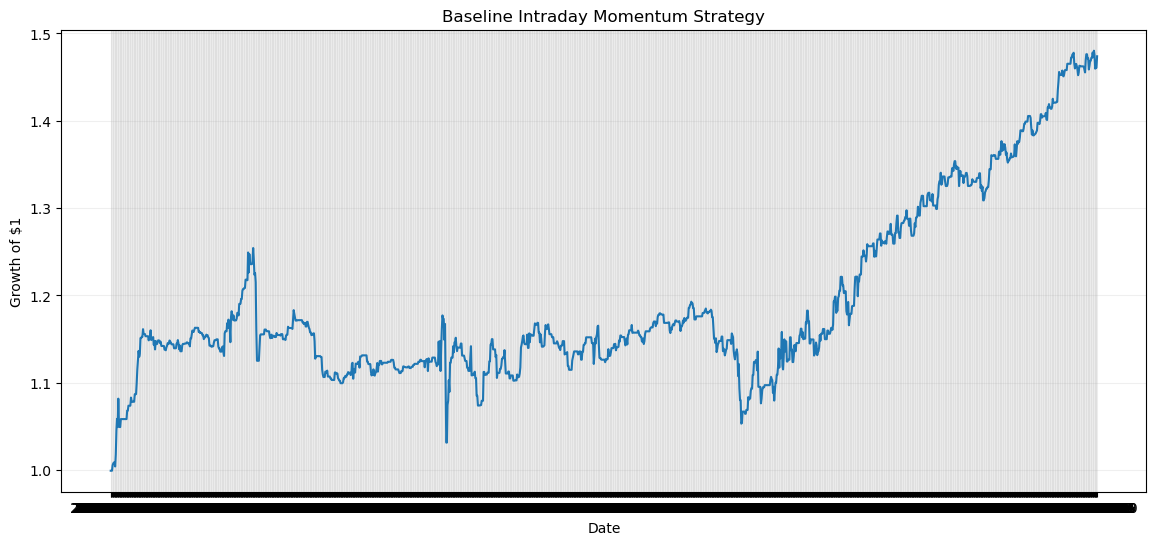

In [31]:
baseline_plot = baseline_daily.copy()

baseline_plot["equity_curve"] = (
    baseline_plot["end_equity"]
    / INITIAL_CAPITAL
)

plt.figure(figsize=(14, 6))

plt.plot(
    baseline_plot["date"],
    baseline_plot["equity_curve"]
)

plt.title(
    "Baseline Intraday Momentum Strategy"
)

plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(alpha=0.2)

plt.show()

# Band + VWAP Stop

In [34]:
%%writefile src/backtest.py

import numpy as np
import pandas as pd


def run_momentum_backtest(
    data,
    initial_capital=100_000,
    commission_per_share=0.0035,
    slippage_per_share=0.001,
    stop_mode="opposite_band",
    sizing_mode="fixed",
):
    """
    Backtest the SPY intraday momentum strategy.

    Parameters
    ----------
    stop_mode:
        "opposite_band"
        "band_vwap"

    sizing_mode:
        "fixed"
        "dynamic"
    """

    equity = initial_capital

    daily_results = []
    trades = []

    # LOOP THROUGH DAYS

    for date, day in data.groupby(
        "date",
        sort=True
    ):

        day = (
            day.sort_values("datetime")
               .copy()
        )

        # Skip initial feature warm-up
        if day["upper_band"].isna().all():
            continue

        start_equity = equity

        day_open = (
            day["open"].iloc[0]
        )

        # POSITION SIZING

        if sizing_mode == "fixed":

            leverage = 1.0

        elif sizing_mode == "dynamic":

            if "dynamic_leverage" not in day.columns:
                raise ValueError(
                    "dynamic_leverage column missing."
                )

            leverage = (
                day["dynamic_leverage"]
                .iloc[0]
            )

            if pd.isna(leverage):
                continue

        else:

            raise ValueError(
                f"Unknown sizing_mode: {sizing_mode}"
            )

        shares = int(
            np.floor(
                start_equity
                * leverage
                / day_open
            )
        )

        if shares <= 0:
            continue

        # INITIAL STATE

        position = 0

        entry_price = None
        entry_time = None

        day_pnl = 0.0

        decision_rows = (
            day.loc[
                day["decision_time"]
            ]
        )

        # HELPER: RECORD TRADE

        def record_trade(
            side,
            exit_price,
            exit_time,
            exit_reason
        ):

            if side == "LONG":

                gross_pnl = (
                    shares
                    * (
                        exit_price
                        - entry_price
                    )
                )

            else:

                gross_pnl = (
                    shares
                    * (
                        entry_price
                        - exit_price
                    )
                )

            commission = (
                2
                * shares
                * commission_per_share
            )

            net_pnl = (
                gross_pnl
                - commission
            )

            trades.append({
                "date": date,
                "side": side,
                "entry_time": entry_time,
                "exit_time": exit_time,
                "entry_price": entry_price,
                "exit_price": exit_price,
                "shares": shares,
                "leverage": leverage,
                "gross_pnl": gross_pnl,
                "commission": commission,
                "net_pnl": net_pnl,
                "exit_reason": exit_reason,
            })

            return net_pnl

        # INTRADAY LOOP

        for _, row in decision_rows.iterrows():

            if pd.isna(
                row["upper_band"]
            ):
                continue

            price = row["open"]

            upper = row["upper_band"]
            lower = row["lower_band"]

            vwap = (
                row["session_vwap_prev"]
            )

            # FLAT

            if position == 0:

                if price > upper:

                    entry_price = (
                        price
                        + slippage_per_share
                    )

                    entry_time = (
                        row["datetime"]
                    )

                    position = 1

                elif price < lower:

                    entry_price = (
                        price
                        - slippage_per_share
                    )

                    entry_time = (
                        row["datetime"]
                    )

                    position = -1

            # LONG

            elif position == 1:

                if stop_mode == "opposite_band":

                    stop = lower

                elif stop_mode == "band_vwap":

                    stop = max(
                        upper,
                        vwap
                    )

                else:

                    raise ValueError(
                        f"Unknown stop_mode: {stop_mode}"
                    )

                if price < stop:

                    exit_price = (
                        price
                        - slippage_per_share
                    )

                    day_pnl += record_trade(
                        "LONG",
                        exit_price,
                        row["datetime"],
                        stop_mode
                    )

                    position = 0
                    entry_price = None
                    entry_time = None

                    # Only reverse if actual opposite
                    # momentum signal exists.
                    if price < lower:

                        entry_price = (
                            price
                            - slippage_per_share
                        )

                        entry_time = (
                            row["datetime"]
                        )

                        position = -1

            # SHORT

            elif position == -1:

                if stop_mode == "opposite_band":

                    stop = upper

                elif stop_mode == "band_vwap":

                    stop = min(
                        lower,
                        vwap
                    )

                else:

                    raise ValueError(
                        f"Unknown stop_mode: {stop_mode}"
                    )

                if price > stop:

                    exit_price = (
                        price
                        + slippage_per_share
                    )

                    day_pnl += record_trade(
                        "SHORT",
                        exit_price,
                        row["datetime"],
                        stop_mode
                    )

                    position = 0
                    entry_price = None
                    entry_time = None

                    # Only reverse if actual opposite
                    # momentum signal exists.
                    if price > upper:

                        entry_price = (
                            price
                            + slippage_per_share
                        )

                        entry_time = (
                            row["datetime"]
                        )

                        position = 1

        # MARKET CLOSE

        close_price = (
            day["close"].iloc[-1]
        )

        close_time = (
            day["datetime"].iloc[-1]
        )

        if position == 1:

            exit_price = (
                close_price
                - slippage_per_share
            )

            day_pnl += record_trade(
                "LONG",
                exit_price,
                close_time,
                "market_close"
            )

        elif position == -1:

            exit_price = (
                close_price
                + slippage_per_share
            )

            day_pnl += record_trade(
                "SHORT",
                exit_price,
                close_time,
                "market_close"
            )

        # DAILY EQUITY

        equity = (
            start_equity
            + day_pnl
        )

        daily_return = (
            equity
            / start_equity
            - 1
        )

        daily_results.append({
            "date": date,
            "start_equity": start_equity,
            "end_equity": equity,
            "pnl": day_pnl,
            "return": daily_return,
            "shares": shares,
            "leverage": leverage,
        })

    return (
        pd.DataFrame(daily_results),
        pd.DataFrame(trades)
    )


def run_baseline_backtest(
    data,
    initial_capital=100_000,
    commission_per_share=0.0035,
    slippage_per_share=0.001,
):
    """
    Convenience wrapper for the paper's
    opposite-band fixed-size baseline.
    """

    return run_momentum_backtest(
        data=data,
        initial_capital=initial_capital,
        commission_per_share=commission_per_share,
        slippage_per_share=slippage_per_share,
        stop_mode="opposite_band",
        sizing_mode="fixed",
    )

Overwriting src/backtest.py


In [36]:
from src.backtest import (
    run_momentum_backtest,
    run_baseline_backtest
)

In [38]:
baseline_daily_new, baseline_trades_new = (
    run_momentum_backtest(
        df_bt,
        initial_capital=INITIAL_CAPITAL,
        commission_per_share=COMMISSION_PER_SHARE,
        slippage_per_share=SLIPPAGE_PER_SHARE,
        stop_mode="opposite_band",
        sizing_mode="fixed",
    )
)

print(
    "Old final equity:",
    baseline_daily["end_equity"].iloc[-1]
)

print(
    "New final equity:",
    baseline_daily_new["end_equity"].iloc[-1]
)

print(
    "Old trades:",
    len(baseline_trades)
)

print(
    "New trades:",
    len(baseline_trades_new)
)

Old final equity: 147389.8650000147
New final equity: 147389.8650000147
Old trades: 964
New trades: 964


In [40]:
baseline_daily = baseline_daily_new
baseline_trades = baseline_trades_new

In [42]:
vwap_daily, vwap_trades = (
    run_momentum_backtest(
        df_bt,
        initial_capital=INITIAL_CAPITAL,
        commission_per_share=COMMISSION_PER_SHARE,
        slippage_per_share=SLIPPAGE_PER_SHARE,
        stop_mode="band_vwap",
        sizing_mode="fixed",
    )
)

print("Trades:")
print(len(vwap_trades))

print("\nFinal equity:")
print(
    f"${vwap_daily['end_equity'].iloc[-1]:,.2f}"
)

Trades:
1384

Final equity:
$172,493.10


In [44]:
comparison_1 = pd.DataFrame({
    "Opposite Band": performance_metrics(
        baseline_daily["return"]
    ),

    "Band + VWAP": performance_metrics(
        vwap_daily["return"]
    ),
}).T

display(comparison_1)

,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio
Opposite Band,1559.0,0.473899,0.064710,0.102626,0.662625,-0.177626,0.339962
Band + VWAP,1559.0,0.724931,0.092125,0.074080,1.226854,-0.112821,0.273894


# Volatility sizing

In [49]:
from src.config import (
    TARGET_DAILY_VOL,
    MAX_LEVERAGE
)

print("TARGET_DAILY_VOL =", TARGET_DAILY_VOL)
print("MAX_LEVERAGE =", MAX_LEVERAGE)

TARGET_DAILY_VOL = 0.02
MAX_LEVERAGE = 4.0


In [51]:
# DAILY VOLATILITY FOR DYNAMIC SIZING

daily_spy = (
    df_bt.groupby("date")
         .agg(
             close=("close", "last")
         )
         .reset_index()
)

daily_spy["spy_return"] = (
    daily_spy["close"]
    .pct_change()
)

daily_spy["vol_14"] = (
    daily_spy["spy_return"]
    .rolling(
        window=14,
        min_periods=14
    )
    .std(ddof=1)
    .shift(1)
)

daily_spy["dynamic_leverage"] = (
    TARGET_DAILY_VOL
    / daily_spy["vol_14"]
)

daily_spy["dynamic_leverage"] = (
    daily_spy["dynamic_leverage"]
    .clip(
        upper=MAX_LEVERAGE
    )
)

display(
    daily_spy.head(25)
)

,date,close,spy_return,vol_14,dynamic_leverage
0,2018-01-02,268.80,NaN,NaN,NaN
1,2018-01-03,270.47,0.006213,NaN,NaN
2,2018-01-04,271.63,0.004289,NaN,NaN
3,2018-01-05,273.39,0.006479,NaN,NaN
4,2018-01-08,273.93,0.001975,NaN,NaN
5,2018-01-09,274.53,0.002190,NaN,NaN
6,2018-01-10,274.10,-0.001566,NaN,NaN
7,2018-01-11,276.08,0.007224,NaN,NaN
8,2018-01-12,277.91,0.006629,NaN,NaN
9,2018-01-16,276.96,-0.003418,NaN,NaN


In [53]:
df_bt = df_bt.drop(
    columns=[
        "vol_14",
        "dynamic_leverage"
    ],
    errors="ignore"
)

df_bt = df_bt.merge(
    daily_spy[
        [
            "date",
            "vol_14",
            "dynamic_leverage"
        ]
    ],
    on="date",
    how="left"
)

display(
    df_bt[
        [
            "datetime",
            "vol_14",
            "dynamic_leverage"
        ]
    ]
    .dropna()
    .head()
)

,datetime,vol_14,dynamic_leverage
5850,2018-01-24 09:30:00,0.003959,4.0
5851,2018-01-24 09:31:00,0.003959,4.0
5852,2018-01-24 09:32:00,0.003959,4.0
5853,2018-01-24 09:33:00,0.003959,4.0
5854,2018-01-24 09:34:00,0.003959,4.0


In [55]:
display(
    daily_spy["dynamic_leverage"]
    .describe()
)

print(
    "\nDays at 4x cap:",
    (
        daily_spy["dynamic_leverage"]
        == MAX_LEVERAGE
    ).sum()
)

count    1558.000000
mean        2.401950
std         0.986938
min         0.402968
25%         1.556057
50%         2.330574
75%         3.168007
max         4.000000
Name: dynamic_leverage, dtype: float64


Days at 4x cap: 198


In [57]:
dynamic_daily, dynamic_trades = (
    run_momentum_backtest(
        df_bt,
        initial_capital=INITIAL_CAPITAL,
        commission_per_share=COMMISSION_PER_SHARE,
        slippage_per_share=SLIPPAGE_PER_SHARE,
        stop_mode="band_vwap",
        sizing_mode="dynamic",
    )
)

print("Trades:")
print(len(dynamic_trades))

print("\nFinal equity:")
print(
    f"${dynamic_daily['end_equity'].iloc[-1]:,.2f}"
)

Trades:
1383

Final equity:
$432,107.05


# Compare all strategies

In [60]:
paper_comparison = pd.DataFrame({
    "Opposite Band": performance_metrics(
        baseline_daily["return"]
    ),

    "Band + VWAP": performance_metrics(
        vwap_daily["return"]
    ),

    "Band + VWAP + Dynamic": performance_metrics(
        dynamic_daily["return"]
    ),
}).T

display(paper_comparison)

,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio
Opposite Band,1559.0,0.473899,0.064710,0.102626,0.662625,-0.177626,0.339962
Band + VWAP,1559.0,0.724931,0.092125,0.074080,1.226854,-0.112821,0.273894
Band + VWAP + Dynamic,1558.0,3.321070,0.267081,0.146572,1.688076,-0.113154,0.274069


In [62]:
paper_comparison_display = (
    paper_comparison.copy()
)

percentage_cols = [
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Max Drawdown",
    "Hit Ratio",
]

for col in percentage_cols:

    paper_comparison_display[col] *= 100

display(
    paper_comparison_display.round(2)
)

,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio
Opposite Band,1559.0,47.39,6.47,10.26,0.66,-17.76,34.00
Band + VWAP,1559.0,72.49,9.21,7.41,1.23,-11.28,27.39
Band + VWAP + Dynamic,1558.0,332.11,26.71,14.66,1.69,-11.32,27.41


# SPY Benchmark

In [65]:
spy_daily = (
    df_bt.groupby("date")
         .agg(
             close=("close", "last")
         )
         .reset_index()
)

spy_daily["return"] = (
    spy_daily["close"]
    .pct_change()
)

spy_daily = (
    spy_daily.dropna()
             .reset_index(drop=True)
)

spy_metrics = performance_metrics(
    spy_daily["return"]
)

display(
    pd.DataFrame(
        spy_metrics,
        index=["SPY Buy & Hold"]
    )
)

,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio
SPY Buy & Hold,1572,0.867708,0.105331,0.186226,0.630981,-0.34229,0.542621


In [67]:
full_comparison = pd.DataFrame({
    "Opposite Band": performance_metrics(
        baseline_daily["return"]
    ),

    "Band + VWAP": performance_metrics(
        vwap_daily["return"]
    ),

    "Band + VWAP + Dynamic": performance_metrics(
        dynamic_daily["return"]
    ),

    "SPY Buy & Hold": performance_metrics(
        spy_daily["return"]
    ),
}).T

display(full_comparison)

,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio
Opposite Band,1559.0,0.473899,0.064710,0.102626,0.662625,-0.177626,0.339962
Band + VWAP,1559.0,0.724931,0.092125,0.074080,1.226854,-0.112821,0.273894
Band + VWAP + Dynamic,1558.0,3.321070,0.267081,0.146572,1.688076,-0.113154,0.274069
SPY Buy & Hold,1572.0,0.867708,0.105331,0.186226,0.630981,-0.342290,0.542621


# Equity curve

In [70]:
def growth_curve(data):

    x = data.copy()

    x["growth"] = (
        1 + x["return"]
    ).cumprod()

    return x

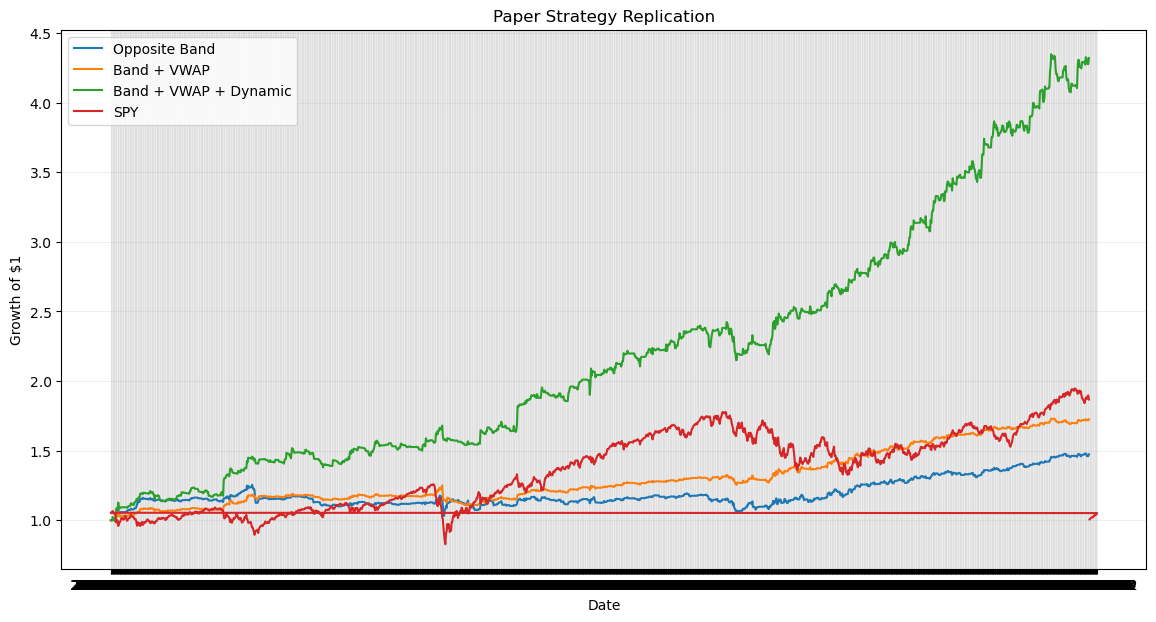

In [72]:
base_curve = growth_curve(
    baseline_daily
)

vwap_curve = growth_curve(
    vwap_daily
)

dynamic_curve = growth_curve(
    dynamic_daily
)

spy_curve = growth_curve(
    spy_daily
)

plt.figure(figsize=(14, 7))

plt.plot(
    base_curve["date"],
    base_curve["growth"],
    label="Opposite Band"
)

plt.plot(
    vwap_curve["date"],
    vwap_curve["growth"],
    label="Band + VWAP"
)

plt.plot(
    dynamic_curve["date"],
    dynamic_curve["growth"],
    label="Band + VWAP + Dynamic"
)

plt.plot(
    spy_curve["date"],
    spy_curve["growth"],
    label="SPY"
)

plt.title(
    "Paper Strategy Replication"
)

plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

# Train/split Test

In [75]:
TRAIN_END = pd.Timestamp(
    "2022-12-31"
)


def train_test_metrics(
    daily_results,
    train_end=TRAIN_END
):

    x = daily_results.copy()

    x["date"] = pd.to_datetime(
        x["date"]
    )

    train = x.loc[
        x["date"] <= train_end
    ]

    test = x.loc[
        x["date"] > train_end
    ]

    return {
        "Train": performance_metrics(
            train["return"]
        ),

        "Test": performance_metrics(
            test["return"]
        ),
    }

In [77]:
strategies = {
    "Opposite Band": baseline_daily,
    "Band + VWAP": vwap_daily,
    "Band + VWAP + Dynamic": dynamic_daily,
    "SPY": spy_daily,
}

rows = []

for strategy_name, data in strategies.items():

    split = train_test_metrics(data)

    for sample_name, metrics in split.items():

        rows.append({
            "Strategy": strategy_name,
            "Sample": sample_name,
            **metrics
        })

train_test_table = (
    pd.DataFrame(rows)
)

display(train_test_table)

,Strategy,Sample,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio
0,Opposite Band,Train,1229,0.273257,0.050782,0.110352,0.504383,-0.177626,0.324654
1,Opposite Band,Test,330,0.157581,0.118228,0.066421,1.715874,-0.033160,0.396970
2,Band + VWAP,Train,1229,0.499453,0.086611,0.079523,1.084470,-0.112821,0.262002
3,Band + VWAP,Test,330,0.150373,0.112907,0.048808,2.216511,-0.023286,0.318182
4,Band + VWAP + Dynamic,Train,1228,1.878271,0.242279,0.150102,1.519903,-0.113154,0.262215
5,Band + VWAP + Dynamic,Test,330,0.501273,0.363801,0.132729,2.404795,-0.062846,0.318182
6,SPY,Train,1242,0.422768,0.074164,0.198760,0.459369,-0.342290,0.540258
7,SPY,Test,330,0.312729,0.230957,0.128585,1.680716,-0.102798,0.551515


# Save results

In [80]:
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

baseline_daily.to_csv(
    RESULTS_DIR / "baseline_daily.csv",
    index=False
)

baseline_trades.to_csv(
    RESULTS_DIR / "baseline_trades.csv",
    index=False
)

vwap_daily.to_csv(
    RESULTS_DIR / "vwap_daily.csv",
    index=False
)

vwap_trades.to_csv(
    RESULTS_DIR / "vwap_trades.csv",
    index=False
)

dynamic_daily.to_csv(
    RESULTS_DIR / "dynamic_daily.csv",
    index=False
)

dynamic_trades.to_csv(
    RESULTS_DIR / "dynamic_trades.csv",
    index=False
)

train_test_table.to_csv(
    RESULTS_DIR / "train_test_metrics.csv",
    index=False
)

full_comparison.to_csv(
    RESULTS_DIR / "paper_strategy_comparison.csv"
)

print("Results saved.")

Results saved.


# Robustness testing

In [83]:
lookbacks = [
    5,
    10,
    14,
    20,
    30,
    60,
    90
]

In [85]:
vol_multipliers = [
    0.5,
    0.75,
    1.0,
    1.25,
    1.5,
    1.75,
    2.0
]

In [116]:
# ROBUSTNESS TESTING SETUP

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.config import (
    CLEAN_FILE,
    RESULTS_DIR,
    INITIAL_CAPITAL,
    COMMISSION_PER_SHARE,
    SLIPPAGE_PER_SHARE,
    TARGET_DAILY_VOL,
    MAX_LEVERAGE,
    TRAIN_END,
)

from src.features import build_features
from src.backtest import run_momentum_backtest
from src.metrics import performance_metrics


FIGURES_DIR = Path("output/figures")

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Robustness setup complete.")
print("Train end:", TRAIN_END)

Robustness setup complete.
Train end: 2022-12-31 00:00:00


In [118]:
# LOAD CLEAN DATA

robust_raw = pd.read_csv(
    CLEAN_FILE
)

print("Shape:")
print(robust_raw.shape)

print("\nColumns:")
print(robust_raw.columns.tolist())

display(
    robust_raw.head()
)

Shape:
(613470, 11)

Columns:
['timestamp', 'symbol', 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap', 'date', 'time']


,timestamp,symbol,open,high,low,close,volume,trade_count,vwap,date,time
0,2018-01-02 09:30:00-05:00,SPY,267.840,267.89,267.67,267.7300,1221610.0,2416.0,267.800296,2018-01-02,09:30:00
1,2018-01-02 09:31:00-05:00,SPY,267.730,267.74,267.60,267.6199,483876.0,1512.0,267.662334,2018-01-02,09:31:00
2,2018-01-02 09:32:00-05:00,SPY,267.615,267.77,267.60,267.6900,269917.0,1121.0,267.710822,2018-01-02,09:32:00
3,2018-01-02 09:33:00-05:00,SPY,267.690,267.70,267.54,267.5500,309337.0,1160.0,267.624496,2018-01-02,09:33:00
4,2018-01-02 09:34:00-05:00,SPY,267.545,267.60,267.46,267.4700,326513.0,1312.0,267.512756,2018-01-02,09:34:00


In [120]:
# DYNAMIC LEVERAGE HELPER

def add_dynamic_leverage(
    data,
    target_vol=0.02,
    max_leverage=4.0
):
    """
    Add the paper-style volatility-based leverage rule.

    Leverage_t = min(
        max_leverage,
        target_vol / previous 14-day daily volatility
    )
    """

    df = data.copy()

    daily = (
        df.groupby("date")
          .agg(
              close=("close", "last")
          )
          .reset_index()
    )

    daily["spy_return"] = (
        daily["close"]
        .pct_change()
    )

    daily["vol_14"] = (
        daily["spy_return"]
        .rolling(
            window=14,
            min_periods=14
        )
        .std(ddof=1)
        .shift(1)
    )

    daily["dynamic_leverage"] = (
        target_vol
        / daily["vol_14"]
    )

    daily["dynamic_leverage"] = (
        daily["dynamic_leverage"]
        .clip(
            upper=max_leverage
        )
    )

    df = df.merge(
        daily[
            [
                "date",
                "vol_14",
                "dynamic_leverage"
            ]
        ],
        on="date",
        how="left"
    )

    return df

In [122]:
# ROBUSTNESS EVALUATION HELPER

def evaluate_parameter_set(
    raw_data,
    lookback=14,
    vol_multiplier=1.0
):
    """
    Build features, add dynamic sizing, restrict evaluation
    to the train period, and run the final paper strategy.
    """

    # 1. Build strategy features

    features = build_features(
        raw_data,
        lookback=lookback,
        vol_multiplier=vol_multiplier
    )

    # 2. Add dynamic leverage

    features = add_dynamic_leverage(
        features,
        target_vol=TARGET_DAILY_VOL,
        max_leverage=MAX_LEVERAGE
    )

    # 3. Restrict evaluation to TRAIN period

    train = features.loc[
        features["date"] <= TRAIN_END
    ].copy()

    # 4. Run final paper strategy

    daily, trades = run_momentum_backtest(
        train,
        initial_capital=INITIAL_CAPITAL,
        commission_per_share=COMMISSION_PER_SHARE,
        slippage_per_share=SLIPPAGE_PER_SHARE,
        stop_mode="band_vwap",
        sizing_mode="dynamic"
    )

    # 5. Calculate metrics

    metrics = performance_metrics(
        daily["return"]
    )

    metrics["Trades"] = len(trades)

    if len(trades) > 0:
        metrics["Average Trades / Day"] = (
            len(trades)
            / len(daily)
        )
    else:
        metrics["Average Trades / Day"] = 0

    return metrics

In [124]:
# SANITY CHECK: PAPER PARAMETERS

paper_parameter_check = (
    evaluate_parameter_set(
        robust_raw,
        lookback=14,
        vol_multiplier=1.0
    )
)

display(
    pd.DataFrame(
        paper_parameter_check,
        index=["L=14, VM=1"]
    )
)

,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio,Trades,Average Trades / Day
"L=14, VM=1",1228,1.878271,0.242279,0.150102,1.519903,-0.113154,0.262215,1071,0.87215


## Lookback robustness

In [127]:
# LOOKBACK ROBUSTNESS

lookback_results = []

for lookback in lookbacks:

    print(
        f"Running lookback = {lookback}..."
    )

    metrics = evaluate_parameter_set(
        robust_raw,
        lookback=lookback,
        vol_multiplier=1.0
    )

    lookback_results.append({
        "Lookback": lookback,
        **metrics
    })


lookback_results = pd.DataFrame(
    lookback_results
)

display(
    lookback_results
)

Running lookback = 5...
Running lookback = 10...
Running lookback = 14...
Running lookback = 20...
Running lookback = 30...
Running lookback = 60...
Running lookback = 90...


,Lookback,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio,Trades,Average Trades / Day
0,5,1228,1.252833,0.181365,0.153122,1.164299,-0.115755,0.283388,1188,0.967427
1,10,1228,1.550306,0.211818,0.150207,1.353504,-0.097502,0.272801,1110,0.903909
2,14,1228,1.878271,0.242279,0.150102,1.519903,-0.113154,0.262215,1071,0.872150
3,20,1223,1.786294,0.235089,0.151025,1.472979,-0.106730,0.259199,1035,0.846280
4,30,1213,1.391634,0.198598,0.145581,1.316587,-0.104553,0.253092,994,0.819456
5,60,1183,1.025606,0.162256,0.145110,1.108031,-0.120897,0.234996,959,0.810651
6,90,1153,1.009770,0.164812,0.143012,1.137510,-0.122070,0.235039,929,0.805724


In [129]:
lookback_display = (
    lookback_results.copy()
)

percentage_columns = [
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Max Drawdown",
    "Hit Ratio"
]

for col in percentage_columns:

    lookback_display[col] = (
        lookback_display[col] * 100
    )

display(
    lookback_display.round(2)
)

,Lookback,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio,Trades,Average Trades / Day
0,5,1228,125.28,18.14,15.31,1.16,-11.58,28.34,1188,0.97
1,10,1228,155.03,21.18,15.02,1.35,-9.75,27.28,1110,0.90
2,14,1228,187.83,24.23,15.01,1.52,-11.32,26.22,1071,0.87
3,20,1223,178.63,23.51,15.10,1.47,-10.67,25.92,1035,0.85
4,30,1213,139.16,19.86,14.56,1.32,-10.46,25.31,994,0.82
5,60,1183,102.56,16.23,14.51,1.11,-12.09,23.50,959,0.81
6,90,1153,100.98,16.48,14.30,1.14,-12.21,23.50,929,0.81


In [131]:
lookback_results.to_csv(
    RESULTS_DIR / "robustness_lookback.csv",
    index=False
)

print(
    "Saved:",
    RESULTS_DIR / "robustness_lookback.csv"
)

Saved: C:\Users\Arty\OneDrive\Рабочий стол\Python Scripts\Algo Trading WUTIS\output\results\robustness_lookback.csv


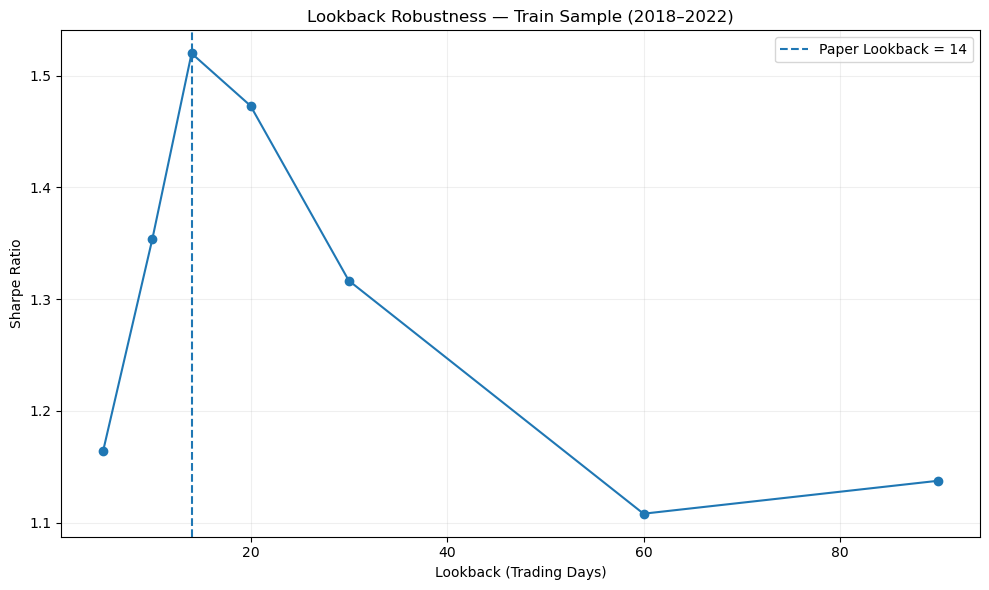

In [133]:
# LOOKBACK ROBUSTNESS PLOT

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    lookback_results["Lookback"],
    lookback_results["Sharpe Ratio"],
    marker="o"
)

# Paper parameter
ax.axvline(
    14,
    linestyle="--",
    label="Paper Lookback = 14"
)

ax.set_title(
    "Lookback Robustness — Train Sample (2018–2022)"
)

ax.set_xlabel(
    "Lookback (Trading Days)"
)

ax.set_ylabel(
    "Sharpe Ratio"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "robustness_lookback_sharpe.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

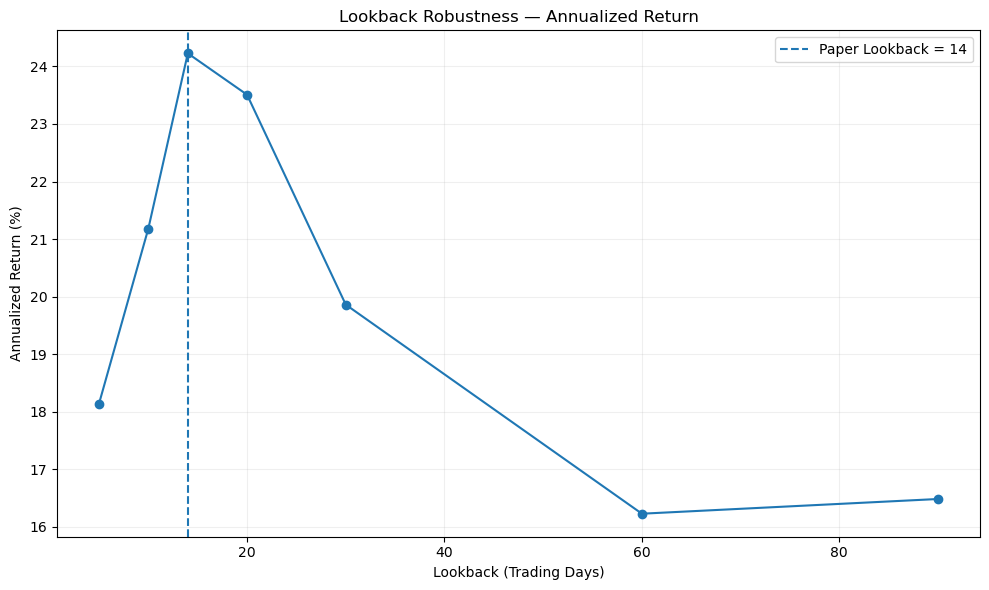

In [135]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    lookback_results["Lookback"],
    lookback_results["Annualized Return"] * 100,
    marker="o"
)

ax.axvline(
    14,
    linestyle="--",
    label="Paper Lookback = 14"
)

ax.set_title(
    "Lookback Robustness — Annualized Return"
)

ax.set_xlabel(
    "Lookback (Trading Days)"
)

ax.set_ylabel(
    "Annualized Return (%)"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "robustness_lookback_return.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Volatility Multiplier robustness

In [138]:
# VOLATILITY MULTIPLIER ROBUSTNESS

vm_results = []

for vm in vol_multipliers:

    print(
        f"Running VM = {vm}..."
    )

    metrics = evaluate_parameter_set(
        robust_raw,
        lookback=14,
        vol_multiplier=vm
    )

    vm_results.append({
        "Volatility Multiplier": vm,
        **metrics
    })


vm_results = pd.DataFrame(
    vm_results
)

display(
    vm_results
)

Running VM = 0.5...
Running VM = 0.75...
Running VM = 1.0...
Running VM = 1.25...
Running VM = 1.5...
Running VM = 1.75...
Running VM = 2.0...


,Volatility Multiplier,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio,Trades,Average Trades / Day
0,0.50,1228,1.528434,0.209678,0.181762,1.137517,-0.153299,0.364007,1715,1.396580
1,0.75,1228,1.891695,0.243466,0.164541,1.406047,-0.133444,0.316775,1358,1.105863
2,1.00,1228,1.878271,0.242279,0.150102,1.519903,-0.113154,0.262215,1071,0.872150
3,1.25,1228,1.494747,0.206353,0.140572,1.404222,-0.092883,0.219055,837,0.681596
4,1.50,1228,1.158609,0.171053,0.124282,1.331840,-0.113517,0.172638,677,0.551303
5,1.75,1228,0.460407,0.080817,0.114071,0.737210,-0.134753,0.140879,570,0.464169
6,2.00,1228,0.187862,0.035960,0.104790,0.388422,-0.132363,0.114821,471,0.383550


In [140]:
vm_display = vm_results.copy()

for col in percentage_columns:

    vm_display[col] = (
        vm_display[col] * 100
    )

display(
    vm_display.round(2)
)

,Volatility Multiplier,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio,Trades,Average Trades / Day
0,0.50,1228,152.84,20.97,18.18,1.14,-15.33,36.40,1715,1.40
1,0.75,1228,189.17,24.35,16.45,1.41,-13.34,31.68,1358,1.11
2,1.00,1228,187.83,24.23,15.01,1.52,-11.32,26.22,1071,0.87
3,1.25,1228,149.47,20.64,14.06,1.40,-9.29,21.91,837,0.68
4,1.50,1228,115.86,17.11,12.43,1.33,-11.35,17.26,677,0.55
5,1.75,1228,46.04,8.08,11.41,0.74,-13.48,14.09,570,0.46
6,2.00,1228,18.79,3.60,10.48,0.39,-13.24,11.48,471,0.38


In [142]:
vm_results.to_csv(
    RESULTS_DIR
    / "robustness_vol_multiplier.csv",
    index=False
)

print(
    "Saved:",
    RESULTS_DIR
    / "robustness_vol_multiplier.csv"
)

Saved: C:\Users\Arty\OneDrive\Рабочий стол\Python Scripts\Algo Trading WUTIS\output\results\robustness_vol_multiplier.csv


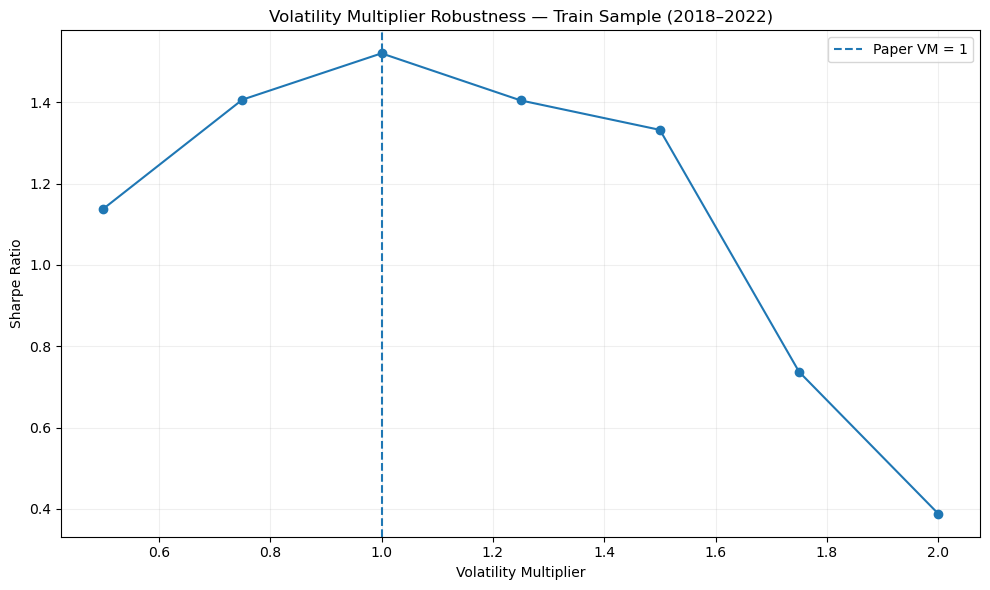

In [144]:
# VOLATILITY MULTIPLIER ROBUSTNESS PLOT

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    vm_results["Volatility Multiplier"],
    vm_results["Sharpe Ratio"],
    marker="o"
)

ax.axvline(
    1.0,
    linestyle="--",
    label="Paper VM = 1"
)

ax.set_title(
    "Volatility Multiplier Robustness — Train Sample (2018–2022)"
)

ax.set_xlabel(
    "Volatility Multiplier"
)

ax.set_ylabel(
    "Sharpe Ratio"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "robustness_vol_multiplier_sharpe.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

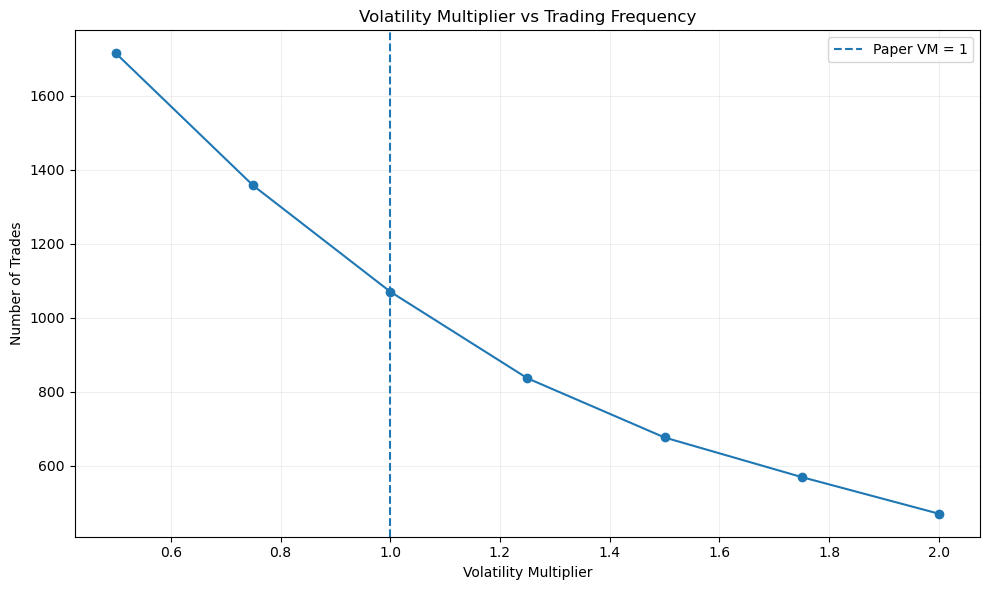

In [146]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    vm_results["Volatility Multiplier"],
    vm_results["Trades"],
    marker="o"
)

ax.axvline(
    1.0,
    linestyle="--",
    label="Paper VM = 1"
)

ax.set_title(
    "Volatility Multiplier vs Trading Frequency"
)

ax.set_xlabel(
    "Volatility Multiplier"
)

ax.set_ylabel(
    "Number of Trades"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "robustness_vol_multiplier_trades.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Master summary

In [149]:
best_lookback = (
    lookback_results
    .loc[
        lookback_results[
            "Sharpe Ratio"
        ].idxmax()
    ]
)

best_vm = (
    vm_results
    .loc[
        vm_results[
            "Sharpe Ratio"
        ].idxmax()
    ]
)

print("Highest train-sample Sharpe by lookback:")
display(
    best_lookback.to_frame().T
)

print(
    "\nHighest train-sample Sharpe by volatility multiplier:"
)

display(
    best_vm.to_frame().T
)

Highest train-sample Sharpe by lookback:


,Lookback,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio,Trades,Average Trades / Day
2,14.0,1228.0,1.878271,0.242279,0.150102,1.519903,-0.113154,0.262215,1071.0,0.87215



Highest train-sample Sharpe by volatility multiplier:


,Volatility Multiplier,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio,Trades,Average Trades / Day
2,1.0,1228.0,1.878271,0.242279,0.150102,1.519903,-0.113154,0.262215,1071.0,0.87215


In [151]:
print("ROBUSTNESS CHECKPOINT")
print("-" * 50)

print("\nResults:")
print(
    RESULTS_DIR
    / "robustness_lookback.csv"
)

print(
    RESULTS_DIR
    / "robustness_vol_multiplier.csv"
)

print("\nFigures:")
print(
    FIGURES_DIR
    / "robustness_lookback_sharpe.png"
)

print(
    FIGURES_DIR
    / "robustness_lookback_return.png"
)

print(
    FIGURES_DIR
    / "robustness_vol_multiplier_sharpe.png"
)

print(
    FIGURES_DIR
    / "robustness_vol_multiplier_trades.png"
)

ROBUSTNESS CHECKPOINT
--------------------------------------------------

Results:
C:\Users\Arty\OneDrive\Рабочий стол\Python Scripts\Algo Trading WUTIS\output\results\robustness_lookback.csv
C:\Users\Arty\OneDrive\Рабочий стол\Python Scripts\Algo Trading WUTIS\output\results\robustness_vol_multiplier.csv

Figures:
output\figures\robustness_lookback_sharpe.png
output\figures\robustness_lookback_return.png
output\figures\robustness_vol_multiplier_sharpe.png
output\figures\robustness_vol_multiplier_trades.png


In [153]:
%%writefile src/robustness.py

import pandas as pd

from src.backtest import run_momentum_backtest
from src.features import build_features


def add_dynamic_leverage(
    data,
    target_vol=0.02,
    max_leverage=4.0,
    vol_window=14,
):
    """
    Add paper-style volatility-based position sizing.

    Daily leverage =
        min(max_leverage, target_vol / recent daily volatility)

    The volatility estimate uses information available before
    the current trading day.
    """

    df = data.copy()

    daily = (
        df.groupby("date")
          .agg(
              close=("close", "last")
          )
          .reset_index()
    )

    daily["spy_return"] = (
        daily["close"]
        .pct_change()
    )

    daily["vol_14"] = (
        daily["spy_return"]
        .rolling(
            window=vol_window,
            min_periods=vol_window
        )
        .std(ddof=1)
        .shift(1)
    )

    daily["dynamic_leverage"] = (
        target_vol
        / daily["vol_14"]
    )

    daily["dynamic_leverage"] = (
        daily["dynamic_leverage"]
        .clip(
            upper=max_leverage
        )
    )

    df = df.merge(
        daily[
            [
                "date",
                "vol_14",
                "dynamic_leverage"
            ]
        ],
        on="date",
        how="left"
    )

    return df


def evaluate_parameter_set(
    raw_data,
    performance_function,
    train_end,
    lookback=14,
    vol_multiplier=1.0,
    initial_capital=100_000,
    commission_per_share=0.0035,
    slippage_per_share=0.001,
    target_vol=0.02,
    max_leverage=4.0,
):
    """
    Evaluate one parameter specification on the train sample.
    """

    features = build_features(
        raw_data,
        lookback=lookback,
        vol_multiplier=vol_multiplier
    )

    features = add_dynamic_leverage(
        features,
        target_vol=target_vol,
        max_leverage=max_leverage
    )

    train = features.loc[
        features["date"] <= train_end
    ].copy()

    daily, trades = run_momentum_backtest(
        train,
        initial_capital=initial_capital,
        commission_per_share=commission_per_share,
        slippage_per_share=slippage_per_share,
        stop_mode="band_vwap",
        sizing_mode="dynamic"
    )

    metrics = performance_function(
        daily["return"]
    )

    metrics["Trades"] = len(trades)

    metrics["Average Trades / Day"] = (
        len(trades) / len(daily)
        if len(daily) > 0
        else 0
    )

    return metrics

Writing src/robustness.py


In [155]:
from src.robustness import (
    add_dynamic_leverage,
    evaluate_parameter_set
)

print("Robustness module imported.")

Robustness module imported.


In [157]:
lookback_results = pd.read_csv(
    RESULTS_DIR / "robustness_lookback.csv"
)

vm_results = pd.read_csv(
    RESULTS_DIR / "robustness_vol_multiplier.csv"
)

display(lookback_results)
display(vm_results)

,Lookback,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio,Trades,Average Trades / Day
0,5,1228,1.252833,0.181365,0.153122,1.164299,-0.115755,0.283388,1188,0.967427
1,10,1228,1.550306,0.211818,0.150207,1.353504,-0.097502,0.272801,1110,0.903909
2,14,1228,1.878271,0.242279,0.150102,1.519903,-0.113154,0.262215,1071,0.872150
3,20,1223,1.786294,0.235089,0.151025,1.472979,-0.106730,0.259199,1035,0.846280
4,30,1213,1.391634,0.198598,0.145581,1.316587,-0.104553,0.253092,994,0.819456
5,60,1183,1.025606,0.162256,0.145110,1.108031,-0.120897,0.234996,959,0.810651
6,90,1153,1.009770,0.164812,0.143012,1.137510,-0.122070,0.235039,929,0.805724


,Volatility Multiplier,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio,Trades,Average Trades / Day
0,0.50,1228,1.528434,0.209678,0.181762,1.137517,-0.153299,0.364007,1715,1.396580
1,0.75,1228,1.891695,0.243466,0.164541,1.406047,-0.133444,0.316775,1358,1.105863
2,1.00,1228,1.878271,0.242279,0.150102,1.519903,-0.113154,0.262215,1071,0.872150
3,1.25,1228,1.494747,0.206353,0.140572,1.404222,-0.092883,0.219055,837,0.681596
4,1.50,1228,1.158609,0.171053,0.124282,1.331840,-0.113517,0.172638,677,0.551303
5,1.75,1228,0.460407,0.080817,0.114071,0.737210,-0.134753,0.140879,570,0.464169
6,2.00,1228,0.187862,0.035960,0.104790,0.388422,-0.132363,0.114821,471,0.383550


In [159]:
print("LOOKBACK ROBUSTNESS")
print("-" * 50)

print(
    "Positive-return specifications:",
    (
        lookback_results["Annualized Return"] > 0
    ).sum(),
    "/",
    len(lookback_results)
)

print(
    "Sharpe range:",
    round(
        lookback_results["Sharpe Ratio"].min(),
        3
    ),
    "to",
    round(
        lookback_results["Sharpe Ratio"].max(),
        3
    )
)

paper_L = lookback_results.loc[
    lookback_results["Lookback"] == 14
]

display(paper_L)


print("\nVOLATILITY MULTIPLIER ROBUSTNESS")
print("-" * 50)

print(
    "Positive-return specifications:",
    (
        vm_results["Annualized Return"] > 0
    ).sum(),
    "/",
    len(vm_results)
)

print(
    "Sharpe range:",
    round(
        vm_results["Sharpe Ratio"].min(),
        3
    ),
    "to",
    round(
        vm_results["Sharpe Ratio"].max(),
        3
    )
)

paper_vm = vm_results.loc[
    vm_results["Volatility Multiplier"] == 1.0
]

display(paper_vm)

LOOKBACK ROBUSTNESS
--------------------------------------------------
Positive-return specifications: 7 / 7
Sharpe range: 1.108 to 1.52


,Lookback,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio,Trades,Average Trades / Day
2,14,1228,1.878271,0.242279,0.150102,1.519903,-0.113154,0.262215,1071,0.87215



VOLATILITY MULTIPLIER ROBUSTNESS
--------------------------------------------------
Positive-return specifications: 7 / 7
Sharpe range: 0.388 to 1.52


,Volatility Multiplier,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio,Trades,Average Trades / Day
2,1.0,1228,1.878271,0.242279,0.150102,1.519903,-0.113154,0.262215,1071,0.87215


# Original Strategy 

## v1
*"Volatility-Regime Adaptive Noise Area"*

In [163]:
%%writefile src/extensions.py

import numpy as np
import pandas as pd

from src.features import build_features


def build_adaptive_vm_features(
    data,
    lookback=14,
    vol_window=14,
    regime_reference_window=60,
    low_ratio=0.80,
    high_ratio=1.20,
    low_vm=0.75,
    normal_vm=1.00,
    high_vm=1.25,
    target_vol=0.02,
    max_leverage=4.0,
):
    """
    Original extension:
    volatility-regime adaptive Noise Area.

    The Noise Area multiplier changes according to recent
    daily volatility relative to its trailing historical median.

    All volatility measures use information available before
    the current trading session.
    """

    # Start from paper-style features
    df = build_features(
        data,
        lookback=lookback,
        vol_multiplier=1.0
    )

    # DAILY VOLATILITY

    daily = (
        df.groupby("date")
          .agg(
              close=("close", "last")
          )
          .reset_index()
    )

    daily["spy_return"] = (
        daily["close"]
        .pct_change()
    )

    # Available before day t
    daily["vol_14"] = (
        daily["spy_return"]
        .rolling(
            window=vol_window,
            min_periods=vol_window
        )
        .std(ddof=1)
        .shift(1)
    )

    # Historical reference level
    daily["vol_reference"] = (
        daily["vol_14"]
        .rolling(
            window=regime_reference_window,
            min_periods=regime_reference_window
        )
        .median()
    )

    daily["vol_ratio"] = (
        daily["vol_14"]
        / daily["vol_reference"]
    )

    # VOLATILITY REGIME

    daily["vol_regime"] = "Normal"

    daily.loc[
        daily["vol_ratio"] < low_ratio,
        "vol_regime"
    ] = "Low"

    daily.loc[
        daily["vol_ratio"] > high_ratio,
        "vol_regime"
    ] = "High"

    # ADAPTIVE VOLATILITY MULTIPLIER

    daily["adaptive_vm"] = normal_vm

    daily.loc[
        daily["vol_regime"] == "Low",
        "adaptive_vm"
    ] = low_vm

    daily.loc[
        daily["vol_regime"] == "High",
        "adaptive_vm"
    ] = high_vm

    # DYNAMIC POSITION SIZING

    daily["dynamic_leverage"] = (
        target_vol
        / daily["vol_14"]
    )

    daily["dynamic_leverage"] = (
        daily["dynamic_leverage"]
        .clip(
            upper=max_leverage
        )
    )

    # MERGE DAILY VARIABLES

    df = df.merge(
        daily[
            [
                "date",
                "vol_14",
                "vol_reference",
                "vol_ratio",
                "vol_regime",
                "adaptive_vm",
                "dynamic_leverage",
            ]
        ],
        on="date",
        how="left"
    )

    # SAVE PAPER BANDS FOR DIAGNOSTICS

    df["paper_upper_band"] = (
        df["upper_band"]
    )

    df["paper_lower_band"] = (
        df["lower_band"]
    )

    # REBUILD NOISE AREA USING ADAPTIVE VM

    upper_reference = np.maximum(
        df["day_open"],
        df["prev_close"]
    )

    lower_reference = np.minimum(
        df["day_open"],
        df["prev_close"]
    )

    df["upper_band"] = (
        upper_reference
        * (
            1
            + df["adaptive_vm"]
            * df["sigma_14"]
        )
    )

    df["lower_band"] = (
        lower_reference
        * (
            1
            - df["adaptive_vm"]
            * df["sigma_14"]
        )
    )

    # REBUILD RAW SIGNAL USING ADAPTIVE BANDS

    df["raw_signal"] = 0

    df.loc[
        df["decision_time"]
        & (
            df["open"]
            > df["upper_band"]
        ),
        "raw_signal"
    ] = 1

    df.loc[
        df["decision_time"]
        & (
            df["open"]
            < df["lower_band"]
        ),
        "raw_signal"
    ] = -1

    return df

Writing src/extensions.py


In [165]:
from src.extensions import (
    build_adaptive_vm_features
)

print("Extension module imported.")

Extension module imported.


In [167]:
adaptive_features = build_adaptive_vm_features(
    robust_raw,
    lookback=14,
    vol_window=14,
    regime_reference_window=60,
    low_ratio=0.80,
    high_ratio=1.20,
    low_vm=0.75,
    normal_vm=1.00,
    high_vm=1.25,
    target_vol=TARGET_DAILY_VOL,
    max_leverage=MAX_LEVERAGE,
)

print(adaptive_features.shape)

display(
    adaptive_features[
        [
            "datetime",
            "vol_14",
            "vol_reference",
            "vol_ratio",
            "vol_regime",
            "adaptive_vm",
            "lower_band",
            "upper_band",
            "dynamic_leverage",
        ]
    ]
    .dropna()
    .head()
)

(613470, 35)


,datetime,vol_14,vol_reference,vol_ratio,vol_regime,adaptive_vm,lower_band,upper_band,dynamic_leverage
28860,2018-04-19 09:30:00,0.01236,0.013598,0.90898,Normal,1.0,269.499281,270.521121,1.618071
28861,2018-04-19 09:31:00,0.01236,0.013598,0.90898,Normal,1.0,269.424912,270.595689,1.618071
28862,2018-04-19 09:32:00,0.01236,0.013598,0.90898,Normal,1.0,269.412323,270.608312,1.618071
28863,2018-04-19 09:33:00,0.01236,0.013598,0.90898,Normal,1.0,269.397020,270.623655,1.618071
28864,2018-04-19 09:34:00,0.01236,0.013598,0.90898,Normal,1.0,269.339361,270.681468,1.618071


In [169]:
adaptive_daily_regimes = (
    adaptive_features
    .groupby("date")
    .agg(
        vol_14=("vol_14", "first"),
        vol_reference=("vol_reference", "first"),
        vol_ratio=("vol_ratio", "first"),
        vol_regime=("vol_regime", "first"),
        adaptive_vm=("adaptive_vm", "first"),
        dynamic_leverage=("dynamic_leverage", "first"),
    )
    .reset_index()
)

display(
    adaptive_daily_regimes[
        "vol_regime"
    ].value_counts()
)

display(
    adaptive_daily_regimes[
        [
            "vol_ratio",
            "adaptive_vm",
            "dynamic_leverage"
        ]
    ].describe()
)

vol_regime
Normal    712
Low       478
High      383
Name: count, dtype: int64

,vol_ratio,adaptive_vm,dynamic_leverage
count,1499.000000,1573.000000,1558.000000
mean,1.088091,0.984901,2.401950
std,0.633088,0.184401,0.986938
min,0.345961,0.750000,0.402968
25%,0.750790,0.750000,1.556057
50%,0.962529,1.000000,2.330574
75%,1.206574,1.000000,3.168007
max,5.621363,1.250000,4.000000


In [171]:
print(
    "Low regime uses 0.75:",
    (
        adaptive_daily_regimes.loc[
            adaptive_daily_regimes["vol_regime"] == "Low",
            "adaptive_vm"
        ]
        == 0.75
    ).all()
)

print(
    "Normal regime uses 1.00:",
    (
        adaptive_daily_regimes.loc[
            adaptive_daily_regimes["vol_regime"] == "Normal",
            "adaptive_vm"
        ]
        == 1.00
    ).all()
)

print(
    "High regime uses 1.25:",
    (
        adaptive_daily_regimes.loc[
            adaptive_daily_regimes["vol_regime"] == "High",
            "adaptive_vm"
        ]
        == 1.25
    ).all()
)

Low regime uses 0.75: True
Normal regime uses 1.00: True
High regime uses 1.25: True


In [173]:
adaptive_train = (
    adaptive_features.loc[
        adaptive_features["date"] <= TRAIN_END
    ]
    .copy()
)

In [175]:
adaptive_train_daily, adaptive_train_trades = (
    run_momentum_backtest(
        adaptive_train,
        initial_capital=INITIAL_CAPITAL,
        commission_per_share=COMMISSION_PER_SHARE,
        slippage_per_share=SLIPPAGE_PER_SHARE,
        stop_mode="band_vwap",
        sizing_mode="dynamic",
    )
)

In [177]:
paper_features = build_features(
    robust_raw,
    lookback=14,
    vol_multiplier=1.0
)

paper_features = add_dynamic_leverage(
    paper_features,
    target_vol=TARGET_DAILY_VOL,
    max_leverage=MAX_LEVERAGE
)

In [179]:
paper_train = (
    paper_features.loc[
        paper_features["date"] <= TRAIN_END
    ]
    .copy()
)

paper_test = (
    paper_features.loc[
        paper_features["date"] > TRAIN_END
    ]
    .copy()
)

In [181]:
paper_train_daily, paper_train_trades = (
    run_momentum_backtest(
        paper_train,
        initial_capital=INITIAL_CAPITAL,
        commission_per_share=COMMISSION_PER_SHARE,
        slippage_per_share=SLIPPAGE_PER_SHARE,
        stop_mode="band_vwap",
        sizing_mode="dynamic",
    )
)

In [183]:
train_original_comparison = pd.DataFrame({
    "Paper Dynamic": performance_metrics(
        paper_train_daily["return"]
    ),

    "Adaptive VM": performance_metrics(
        adaptive_train_daily["return"]
    ),
}).T

train_original_comparison["Trades"] = [
    len(paper_train_trades),
    len(adaptive_train_trades)
]

display(
    train_original_comparison
)

,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio,Trades
Paper Dynamic,1228.0,1.878271,0.242279,0.150102,1.519903,-0.113154,0.262215,1071
Adaptive VM,1228.0,1.647117,0.221119,0.154984,1.365906,-0.143195,0.265472,1112


In [185]:
train_display = (
    train_original_comparison.copy()
)

for col in [
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Max Drawdown",
    "Hit Ratio"
]:
    train_display[col] *= 100

display(
    train_display.round(2)
)

,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio,Trades
Paper Dynamic,1228.0,187.83,24.23,15.01,1.52,-11.32,26.22,1071
Adaptive VM,1228.0,164.71,22.11,15.50,1.37,-14.32,26.55,1112


In [192]:
train_original_comparison.to_csv(
    RESULTS_DIR / "adaptive_vm_v1_train_results.csv"
)

print("Adaptive VM v1 saved as rejected development experiment.")

Adaptive VM v1 saved as rejected development experiment.


## v2
Hypothesis: 
A single boundary breach may be transient noise. Require the imbalance to persist across two consecutive 30-minute decision points before entering.

In [194]:
from pathlib import Path

extensions_file = Path("src/extensions.py")

addition = r'''

def add_confirmation_signal(data):
    """
    Require two consecutive semi-hourly momentum signals
    in the same direction before allowing a new entry.

    confirmed_signal:
         1 = confirmed long
        -1 = confirmed short
         0 = no confirmed entry
    """

    df = data.copy()

    df["confirmed_signal"] = 0

    # Work only with actual strategy decision timestamps
    decision_mask = df["decision_time"]

    decisions = (
        df.loc[
            decision_mask,
            [
                "date",
                "datetime",
                "raw_signal"
            ]
        ]
        .copy()
    )

    # Previous semi-hourly signal within the SAME trading day
    decisions["previous_signal"] = (
        decisions.groupby("date")["raw_signal"]
                 .shift(1)
    )

    decisions["confirmed_signal"] = 0

    # Two consecutive bullish breakouts
    decisions.loc[
        (decisions["raw_signal"] == 1)
        &
        (decisions["previous_signal"] == 1),
        "confirmed_signal"
    ] = 1

    # Two consecutive bearish breakouts
    decisions.loc[
        (decisions["raw_signal"] == -1)
        &
        (decisions["previous_signal"] == -1),
        "confirmed_signal"
    ] = -1

    df.loc[
        decisions.index,
        "confirmed_signal"
    ] = decisions["confirmed_signal"]

    return df
'''

text = extensions_file.read_text(
    encoding="utf-8"
)

if "def add_confirmation_signal" not in text:
    extensions_file.write_text(
        text + addition,
        encoding="utf-8"
    )

print("Confirmation signal added.")

Confirmation signal added.


In [196]:
from pathlib import Path

backtest_file = Path("src/backtest.py")

text = backtest_file.read_text(
    encoding="utf-8"
)

old_header = '''def run_momentum_backtest(
    data,
    initial_capital=100_000,
    commission_per_share=0.0035,
    slippage_per_share=0.001,
    stop_mode="opposite_band",
    sizing_mode="fixed",
):'''

new_header = '''def run_momentum_backtest(
    data,
    initial_capital=100_000,
    commission_per_share=0.0035,
    slippage_per_share=0.001,
    stop_mode="opposite_band",
    sizing_mode="fixed",
    entry_signal_col=None,
):'''

if old_header in text:

    text = text.replace(
        old_header,
        new_header
    )

    backtest_file.write_text(
        text,
        encoding="utf-8"
    )

    print("Function header updated successfully.")

else:

    print(
        "Original function header not found. "
        "It may already have been updated."
    )

Function header updated successfully.


In [202]:
%%writefile src/backtest.py

import numpy as np
import pandas as pd


def run_momentum_backtest(
    data,
    initial_capital=100_000,
    commission_per_share=0.0035,
    slippage_per_share=0.001,
    stop_mode="opposite_band",
    sizing_mode="fixed",
    entry_signal_col=None,
):
    """
    Backtest the SPY intraday momentum strategy.

    Parameters
    ----------
    data : pd.DataFrame
        Feature-engineered intraday SPY data.

    initial_capital : float
        Starting portfolio value.

    commission_per_share : float
        Commission charged per share per transaction.

    slippage_per_share : float
        Adverse execution slippage per share.

    stop_mode : str
        "opposite_band"
        "band_vwap"

    sizing_mode : str
        "fixed"
        "dynamic"

    entry_signal_col : str or None
        None:
            Use original paper breakout conditions.

        Example "confirmed_signal":
            Only enter when that column equals +1 or -1.
    """

    # VALIDATION

    if entry_signal_col is not None:

        if entry_signal_col not in data.columns:

            raise ValueError(
                f"Entry signal column "
                f"'{entry_signal_col}' not found."
            )

    # INITIAL PORTFOLIO

    equity = initial_capital

    daily_results = []
    trades = []

    # LOOP THROUGH TRADING DAYS

    for date, day in data.groupby(
        "date",
        sort=True
    ):

        day = (
            day.sort_values("datetime")
               .copy()
        )

        # Skip initial Noise Area warm-up days
        if day["upper_band"].isna().all():
            continue

        start_equity = equity

        day_open = (
            day["open"].iloc[0]
        )

        # POSITION SIZING

        if sizing_mode == "fixed":

            leverage = 1.0

        elif sizing_mode == "dynamic":

            if "dynamic_leverage" not in day.columns:

                raise ValueError(
                    "dynamic_leverage column missing."
                )

            leverage = (
                day["dynamic_leverage"]
                .iloc[0]
            )

            if pd.isna(leverage):
                continue

        else:

            raise ValueError(
                f"Unknown sizing_mode: {sizing_mode}"
            )

        shares = int(
            np.floor(
                start_equity
                * leverage
                / day_open
            )
        )

        if shares <= 0:
            continue

        # INITIAL POSITION STATE

        position = 0

        entry_price = None
        entry_time = None

        day_pnl = 0.0

        decision_rows = (
            day.loc[
                day["decision_time"]
            ]
        )

        # TRADE RECORDING HELPER

        def record_trade(
            side,
            exit_price,
            exit_time,
            exit_reason
        ):

            if side == "LONG":

                gross_pnl = (
                    shares
                    * (
                        exit_price
                        - entry_price
                    )
                )

            elif side == "SHORT":

                gross_pnl = (
                    shares
                    * (
                        entry_price
                        - exit_price
                    )
                )

            else:

                raise ValueError(
                    f"Unknown side: {side}"
                )

            commission = (
                2
                * shares
                * commission_per_share
            )

            net_pnl = (
                gross_pnl
                - commission
            )

            trades.append({
                "date": date,
                "side": side,
                "entry_time": entry_time,
                "exit_time": exit_time,
                "entry_price": entry_price,
                "exit_price": exit_price,
                "shares": shares,
                "leverage": leverage,
                "gross_pnl": gross_pnl,
                "commission": commission,
                "net_pnl": net_pnl,
                "exit_reason": exit_reason,
            })

            return net_pnl

        # INTRADAY DECISION LOOP

        for _, row in decision_rows.iterrows():

            if pd.isna(
                row["upper_band"]
            ):
                continue

            price = row["open"]

            upper = row["upper_band"]
            lower = row["lower_band"]

            vwap = (
                row["session_vwap_prev"]
            )

            # ENTRY CONDITIONS

            if entry_signal_col is None:

                long_entry = (
                    price > upper
                )

                short_entry = (
                    price < lower
                )

            else:

                signal = (
                    row[entry_signal_col]
                )

                long_entry = (
                    signal == 1
                )

                short_entry = (
                    signal == -1
                )

            # FLAT

            if position == 0:

                if long_entry:

                    entry_price = (
                        price
                        + slippage_per_share
                    )

                    entry_time = (
                        row["datetime"]
                    )

                    position = 1

                elif short_entry:

                    entry_price = (
                        price
                        - slippage_per_share
                    )

                    entry_time = (
                        row["datetime"]
                    )

                    position = -1

            # LONG POSITION

            elif position == 1:

                if stop_mode == "opposite_band":

                    stop = lower

                elif stop_mode == "band_vwap":

                    if pd.isna(vwap):
                        stop = upper

                    else:
                        stop = max(
                            upper,
                            vwap
                        )

                else:

                    raise ValueError(
                        f"Unknown stop_mode: "
                        f"{stop_mode}"
                    )

                # LONG EXIT

                if price < stop:

                    exit_price = (
                        price
                        - slippage_per_share
                    )

                    day_pnl += record_trade(
                        side="LONG",
                        exit_price=exit_price,
                        exit_time=row["datetime"],
                        exit_reason=stop_mode
                    )

                    position = 0

                    entry_price = None
                    entry_time = None

                    # OPTIONAL SHORT REVERSAL

                    if short_entry:

                        entry_price = (
                            price
                            - slippage_per_share
                        )

                        entry_time = (
                            row["datetime"]
                        )

                        position = -1

            # SHORT POSITION

            elif position == -1:

                if stop_mode == "opposite_band":

                    stop = upper

                elif stop_mode == "band_vwap":

                    if pd.isna(vwap):
                        stop = lower

                    else:
                        stop = min(
                            lower,
                            vwap
                        )

                else:

                    raise ValueError(
                        f"Unknown stop_mode: "
                        f"{stop_mode}"
                    )

                # SHORT EXIT

                if price > stop:

                    exit_price = (
                        price
                        + slippage_per_share
                    )

                    day_pnl += record_trade(
                        side="SHORT",
                        exit_price=exit_price,
                        exit_time=row["datetime"],
                        exit_reason=stop_mode
                    )

                    position = 0

                    entry_price = None
                    entry_time = None

                    # OPTIONAL LONG REVERSAL

                    if long_entry:

                        entry_price = (
                            price
                            + slippage_per_share
                        )

                        entry_time = (
                            row["datetime"]
                        )

                        position = 1

        # END-OF-DAY EXIT

        close_price = (
            day["close"].iloc[-1]
        )

        close_time = (
            day["datetime"].iloc[-1]
        )

        if position == 1:

            exit_price = (
                close_price
                - slippage_per_share
            )

            day_pnl += record_trade(
                side="LONG",
                exit_price=exit_price,
                exit_time=close_time,
                exit_reason="market_close"
            )

        elif position == -1:

            exit_price = (
                close_price
                + slippage_per_share
            )

            day_pnl += record_trade(
                side="SHORT",
                exit_price=exit_price,
                exit_time=close_time,
                exit_reason="market_close"
            )

        # DAILY PORTFOLIO UPDATE

        equity = (
            start_equity
            + day_pnl
        )

        daily_return = (
            equity
            / start_equity
            - 1
        )

        daily_results.append({
            "date": date,
            "start_equity": start_equity,
            "end_equity": equity,
            "pnl": day_pnl,
            "return": daily_return,
            "shares": shares,
            "leverage": leverage,
        })

    return (
        pd.DataFrame(daily_results),
        pd.DataFrame(trades)
    )


def run_baseline_backtest(
    data,
    initial_capital=100_000,
    commission_per_share=0.0035,
    slippage_per_share=0.001,
):
    """
    Convenience wrapper for the original fixed-size,
    opposite-band strategy.
    """

    return run_momentum_backtest(
        data=data,
        initial_capital=initial_capital,
        commission_per_share=commission_per_share,
        slippage_per_share=slippage_per_share,
        stop_mode="opposite_band",
        sizing_mode="fixed",
        entry_signal_col=None,
    )

Overwriting src/backtest.py


In [204]:
from src.backtest import (
    run_momentum_backtest,
    run_baseline_backtest
)

print("Updated backtest module imported.")

Updated backtest module imported.


In [206]:
paper_control_daily, paper_control_trades = (
    run_momentum_backtest(
        paper_features,
        initial_capital=INITIAL_CAPITAL,
        commission_per_share=COMMISSION_PER_SHARE,
        slippage_per_share=SLIPPAGE_PER_SHARE,
        stop_mode="band_vwap",
        sizing_mode="dynamic",
        entry_signal_col=None,
    )
)

print("OLD PAPER RESULTS")
print(
    "Final equity:",
    dynamic_daily["end_equity"].iloc[-1]
)
print(
    "Trades:",
    len(dynamic_trades)
)

print("\nNEW CONTROL RESULTS")
print(
    "Final equity:",
    paper_control_daily["end_equity"].iloc[-1]
)
print(
    "Trades:",
    len(paper_control_trades)
)

print("\nEquity matches:")
print(
    np.isclose(
        dynamic_daily["end_equity"].iloc[-1],
        paper_control_daily["end_equity"].iloc[-1]
    )
)

print("\nTrade count matches:")
print(
    len(dynamic_trades)
    ==
    len(paper_control_trades)
)

OLD PAPER RESULTS
Final equity: 432107.04640009266
Trades: 1383

NEW CONTROL RESULTS
Final equity: 432107.04640009266
Trades: 1383

Equity matches:
True

Trade count matches:
True


In [208]:
from pathlib import Path

extensions_file = Path(
    "src/extensions.py"
)

text = extensions_file.read_text(
    encoding="utf-8"
)

addition = r'''

def add_confirmation_signal(data):
    """
    Require two consecutive semi-hourly breakout signals
    in the same direction before allowing an entry.

    confirmed_signal:
         1 = confirmed bullish breakout
        -1 = confirmed bearish breakout
         0 = no confirmed breakout
    """

    df = data.copy()

    df["confirmed_signal"] = 0

    decisions = (
        df.loc[
            df["decision_time"],
            [
                "date",
                "datetime",
                "raw_signal"
            ]
        ]
        .copy()
    )

    # Previous decision signal within the same trading day
    decisions["previous_signal"] = (
        decisions.groupby("date")[
            "raw_signal"
        ]
        .shift(1)
    )

    decisions["confirmed_signal"] = 0

    # Two consecutive bullish signals
    decisions.loc[
        (
            decisions["raw_signal"] == 1
        )
        &
        (
            decisions["previous_signal"] == 1
        ),
        "confirmed_signal"
    ] = 1

    # Two consecutive bearish signals
    decisions.loc[
        (
            decisions["raw_signal"] == -1
        )
        &
        (
            decisions["previous_signal"] == -1
        ),
        "confirmed_signal"
    ] = -1

    df.loc[
        decisions.index,
        "confirmed_signal"
    ] = (
        decisions["confirmed_signal"]
    )

    return df
'''

if (
    "def add_confirmation_signal"
    not in text
):

    extensions_file.write_text(
        text + addition,
        encoding="utf-8"
    )

    print(
        "Confirmation function added."
    )

else:

    print(
        "Confirmation function already exists."
    )

Confirmation function already exists.


In [210]:
from src.extensions import (
    add_confirmation_signal
)

print(
    "Confirmation function imported."
)

Confirmation function imported.


In [212]:
confirmed_features = (
    add_confirmation_signal(
        paper_features
    )
)

print(
    "Shape:",
    confirmed_features.shape
)

display(
    confirmed_features.loc[
        confirmed_features[
            "decision_time"
        ],
        [
            "datetime",
            "open",
            "lower_band",
            "upper_band",
            "raw_signal",
            "confirmed_signal",
        ]
    ]
    .dropna()
    .head(40)
)

Shape: (613470, 30)


,datetime,open,lower_band,upper_band,raw_signal,confirmed_signal
5490,2018-01-23 10:00:00,282.6500,282.280905,283.129191,0,0
5520,2018-01-23 10:30:00,282.9600,282.246875,283.163229,0,0
5550,2018-01-23 11:00:00,283.4450,282.215519,283.194594,1,0
5580,2018-01-23 11:30:00,283.3300,282.211773,283.198340,1,1
5610,2018-01-23 12:00:00,283.0600,282.107227,283.302913,0,0
5640,2018-01-23 12:30:00,283.0450,282.065358,283.344791,0,0
5670,2018-01-23 13:00:00,283.0800,281.925806,283.484378,0,0
5700,2018-01-23 13:30:00,283.1700,281.902881,283.507309,0,0
5730,2018-01-23 14:00:00,283.4700,281.843491,283.566714,0,0
5760,2018-01-23 14:30:00,283.1400,281.806642,283.603571,0,0


In [214]:
decision_data = (
    confirmed_features.loc[
        confirmed_features[
            "decision_time"
        ]
    ]
    .copy()
)

print("RAW SIGNALS")
display(
    decision_data[
        "raw_signal"
    ]
    .value_counts()
    .sort_index()
)

print("\nCONFIRMED SIGNALS")
display(
    decision_data[
        "confirmed_signal"
    ]
    .value_counts()
    .sort_index()
)

raw_entries = (
    decision_data[
        "raw_signal"
    ]
    .ne(0)
    .sum()
)

confirmed_entries = (
    decision_data[
        "confirmed_signal"
    ]
    .ne(0)
    .sum()
)

print(
    "\nRaw non-zero signals:",
    raw_entries
)

print(
    "Confirmed non-zero signals:",
    confirmed_entries
)

print(
    "Signal reduction:",
    round(
        100
        * (
            1
            - confirmed_entries
            / raw_entries
        ),
        2
    ),
    "%"
)

RAW SIGNALS


raw_signal
-1     2435
 0    13620
 1     2821
Name: count, dtype: int64


CONFIRMED SIGNALS


confirmed_signal
-1     1808
 0    14929
 1     2139
Name: count, dtype: int64


Raw non-zero signals: 5256
Confirmed non-zero signals: 3947
Signal reduction: 24.9 %


In [216]:
confirmed_train = (
    confirmed_features.loc[
        confirmed_features["date"]
        <= TRAIN_END
    ]
    .copy()
)

print(
    "Train start:",
    confirmed_train["date"].min()
)

print(
    "Train end:",
    confirmed_train["date"].max()
)

Train start: 2018-01-02 00:00:00
Train end: 2022-12-30 00:00:00


In [218]:
confirmed_train_daily, confirmed_train_trades = (
    run_momentum_backtest(
        confirmed_train,
        initial_capital=INITIAL_CAPITAL,
        commission_per_share=COMMISSION_PER_SHARE,
        slippage_per_share=SLIPPAGE_PER_SHARE,
        stop_mode="band_vwap",
        sizing_mode="dynamic",
        entry_signal_col="confirmed_signal",
    )
)

print(
    "Backtested days:",
    len(confirmed_train_daily)
)

print(
    "Completed trades:",
    len(confirmed_train_trades)
)

print(
    "Final train equity:",
    f"${confirmed_train_daily['end_equity'].iloc[-1]:,.2f}"
)

Backtested days: 1228
Completed trades: 685
Final train equity: $235,988.30


In [220]:
confirmation_train_comparison = (
    pd.DataFrame({
        "Paper Dynamic":
            performance_metrics(
                paper_train_daily[
                    "return"
                ]
            ),

        "Confirmed Breakout":
            performance_metrics(
                confirmed_train_daily[
                    "return"
                ]
            ),
    }).T
)

confirmation_train_comparison[
    "Trades"
] = [
    len(paper_train_trades),
    len(confirmed_train_trades)
]

display(
    confirmation_train_comparison
)

,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio,Trades
Paper Dynamic,1228.0,1.878271,0.242279,0.150102,1.519903,-0.113154,0.262215,1071
Confirmed Breakout,1228.0,1.359883,0.192673,0.123979,1.482616,-0.100522,0.204397,685


In [222]:
confirmation_display = (
    confirmation_train_comparison
    .copy()
)

percentage_columns = [
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Max Drawdown",
    "Hit Ratio",
]

for col in percentage_columns:

    confirmation_display[col] = (
        confirmation_display[col]
        * 100
    )

display(
    confirmation_display.round(2)
)

,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio,Trades
Paper Dynamic,1228.0,187.83,24.23,15.01,1.52,-11.32,26.22,1071
Confirmed Breakout,1228.0,135.99,19.27,12.40,1.48,-10.05,20.44,685


In [224]:
def actual_trade_metrics(
    trades
):

    if len(trades) == 0:

        return pd.Series({
            "Trades": 0,
            "Trade Win Rate": np.nan,
            "Average Trade PnL": np.nan,
            "Median Trade PnL": np.nan,
            "Profit Factor": np.nan,
        })

    winners = (
        trades.loc[
            trades["net_pnl"] > 0,
            "net_pnl"
        ]
    )

    losers = (
        trades.loc[
            trades["net_pnl"] < 0,
            "net_pnl"
        ]
    )

    gross_profit = (
        winners.sum()
    )

    gross_loss = (
        abs(
            losers.sum()
        )
    )

    profit_factor = (
        gross_profit / gross_loss
        if gross_loss > 0
        else np.nan
    )

    return pd.Series({
        "Trades":
            len(trades),

        "Trade Win Rate":
            (
                trades["net_pnl"] > 0
            ).mean(),

        "Average Trade PnL":
            trades["net_pnl"].mean(),

        "Median Trade PnL":
            trades["net_pnl"].median(),

        "Profit Factor":
            profit_factor,
    })

In [226]:
trade_comparison = (
    pd.DataFrame({
        "Paper Dynamic":
            actual_trade_metrics(
                paper_train_trades
            ),

        "Confirmed Breakout":
            actual_trade_metrics(
                confirmed_train_trades
            ),
    })
    .T
)

trade_comparison[
    "Trade Win Rate"
] *= 100

display(
    trade_comparison.round(2)
)

,Trades,Trade Win Rate,Average Trade PnL,Median Trade PnL,Profit Factor
Paper Dynamic,1071.0,39.96,175.38,-209.00,1.35
Confirmed Breakout,685.0,43.07,198.52,-143.82,1.44


In [228]:
confirmation_train_comparison.to_csv(
    RESULTS_DIR
    / "confirmed_breakout_train_results.csv"
)

confirmed_train_daily.to_csv(
    RESULTS_DIR
    / "confirmed_breakout_train_daily.csv",
    index=False
)

confirmed_train_trades.to_csv(
    RESULTS_DIR
    / "confirmed_breakout_train_trades.csv",
    index=False
)

trade_comparison.to_csv(
    RESULTS_DIR
    / "confirmed_breakout_trade_metrics.csv"
)

print(
    "Confirmed-breakout train experiment saved."
)

Confirmed-breakout train experiment saved.


In [230]:
# SAVE CONFIRMED BREAKOUT SPECIFICATION

confirmed_breakout_spec = pd.DataFrame({
    "Parameter": [
        "Strategy Name",
        "Noise Area Lookback",
        "Volatility Multiplier",
        "Confirmation Requirement",
        "Decision Frequency",
        "First Decision Time",
        "Last Decision Time",
        "Stop Rule",
        "Sizing Rule",
        "Target Daily Volatility",
        "Maximum Leverage",
        "Commission Per Share",
        "Slippage Per Share",
        "Train End",
        "Test Start",
        "Development Status",
    ],

    "Value": [
        "Confirmed Breakout v1",
        14,
        1.0,
        "2 consecutive same-direction breakout signals",
        "30 minutes",
        "10:00",
        "15:30",
        "Current Band + VWAP",
        "Dynamic volatility sizing",
        TARGET_DAILY_VOL,
        MAX_LEVERAGE,
        COMMISSION_PER_SHARE,
        SLIPPAGE_PER_SHARE,
        "2022-12-31",
        "2023-01-01",
        "Frozen before OOS evaluation",
    ]
})

confirmed_breakout_spec.to_csv(
    RESULTS_DIR / "confirmed_breakout_specification.csv",
    index=False
)

print("Saved confirmed-breakout specification.")

print("\nCurrent confirmed-breakout files:")

for file in sorted(
    RESULTS_DIR.glob("confirmed_breakout*")
):
    print(" -", file.name)

Saved confirmed-breakout specification.

Current confirmed-breakout files:
 - confirmed_breakout_specification.csv
 - confirmed_breakout_trade_metrics.csv
 - confirmed_breakout_train_daily.csv
 - confirmed_breakout_train_results.csv
 - confirmed_breakout_train_trades.csv


# Out-of-Sample Evaluation — Original Strategy v2

## Confirmed Breakout Strategy

Original Strategy v1, the Adaptive Volatility Multiplier approach,
was rejected during development because it underperformed the Paper
Dynamic strategy on the 2018–2022 train sample.

Original Strategy v2 introduces signal confirmation.

Instead of entering immediately after a single Noise Area breakout,
the strategy requires two consecutive semi-hourly breakout signals
in the same direction before opening a position.

The economic hypothesis is that persistent price movement outside
the Noise Area provides stronger evidence of a genuine demand/supply
imbalance than a single boundary breach.

The Confirmed Breakout v2 specification was developed and frozen
using the 2018–2022 development sample.

This section evaluates the frozen strategy once on the untouched
2023–2024 out-of-sample period and compares it against:

1. Paper Dynamic strategy
2. Confirmed Breakout v2
3. SPY Buy & Hold

Both trading strategies begin the test period with $100,000 and use
identical transaction-cost and slippage assumptions.

No parameters are modified after observing the out-of-sample results.

In [3]:
# OUT-OF-SAMPLE EVALUATION SETUP

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.config import (
    CLEAN_FILE,
    RESULTS_DIR,
    INITIAL_CAPITAL,
    COMMISSION_PER_SHARE,
    SLIPPAGE_PER_SHARE,
    TARGET_DAILY_VOL,
    MAX_LEVERAGE,
    TRAIN_END,
)

from src.features import (
    build_features
)

from src.robustness import (
    add_dynamic_leverage
)

from src.extensions import (
    add_confirmation_signal
)

from src.backtest import (
    run_momentum_backtest
)

from src.metrics import (
    performance_metrics
)

FIGURES_DIR = Path("output/figures")

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Initial capital:", INITIAL_CAPITAL)
print("Train end:", TRAIN_END)
print("Test start:", TRAIN_END + pd.Timedelta(days=1))

Initial capital: 100000
Train end: 2022-12-31 00:00:00
Test start: 2023-01-01 00:00:00


In [5]:
# LOAD CLEAN DATA

raw = pd.read_csv(
    CLEAN_FILE
)

print("Shape:")
print(raw.shape)

print("\nColumns:")
print(raw.columns.tolist())

display(raw.head())

Shape:
(613470, 11)

Columns:
['timestamp', 'symbol', 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap', 'date', 'time']


,timestamp,symbol,open,high,low,close,volume,trade_count,vwap,date,time
0,2018-01-02 09:30:00-05:00,SPY,267.840,267.89,267.67,267.7300,1221610.0,2416.0,267.800296,2018-01-02,09:30:00
1,2018-01-02 09:31:00-05:00,SPY,267.730,267.74,267.60,267.6199,483876.0,1512.0,267.662334,2018-01-02,09:31:00
2,2018-01-02 09:32:00-05:00,SPY,267.615,267.77,267.60,267.6900,269917.0,1121.0,267.710822,2018-01-02,09:32:00
3,2018-01-02 09:33:00-05:00,SPY,267.690,267.70,267.54,267.5500,309337.0,1160.0,267.624496,2018-01-02,09:33:00
4,2018-01-02 09:34:00-05:00,SPY,267.545,267.60,267.46,267.4700,326513.0,1312.0,267.512756,2018-01-02,09:34:00


In [7]:
# PAPER DYNAMIC FEATURES

paper_features = build_features(
    raw,
    lookback=14,
    vol_multiplier=1.0
)

paper_features = add_dynamic_leverage(
    paper_features,
    target_vol=TARGET_DAILY_VOL,
    max_leverage=MAX_LEVERAGE
)

print("Paper feature data:")
print(paper_features.shape)

display(
    paper_features[
        [
            "datetime",
            "lower_band",
            "upper_band",
            "session_vwap_prev",
            "dynamic_leverage"
        ]
    ]
    .dropna()
    .head()
)

Paper feature data:
(613470, 29)


,datetime,lower_band,upper_band,session_vwap_prev,dynamic_leverage
5851,2018-01-24 09:31:00,283.189438,284.060744,284.028039,4.0
5852,2018-01-24 09:32:00,283.156187,284.094080,284.022629,4.0
5853,2018-01-24 09:33:00,283.144417,284.105881,284.013436,4.0
5854,2018-01-24 09:34:00,283.112201,284.138180,284.017904,4.0
5855,2018-01-24 09:35:00,283.104553,284.145848,284.008905,4.0


In [9]:
# CONFIRMED BREAKOUT V2 FEATURES

confirmed_features = (
    add_confirmation_signal(
        paper_features
    )
)

display(
    confirmed_features.loc[
        confirmed_features["decision_time"],
        [
            "datetime",
            "open",
            "lower_band",
            "upper_band",
            "raw_signal",
            "confirmed_signal"
        ]
    ]
    .dropna()
    .head(30)
)

,datetime,open,lower_band,upper_band,raw_signal,confirmed_signal
5490,2018-01-23 10:00:00,282.6500,282.280905,283.129191,0,0
5520,2018-01-23 10:30:00,282.9600,282.246875,283.163229,0,0
5550,2018-01-23 11:00:00,283.4450,282.215519,283.194594,1,0
5580,2018-01-23 11:30:00,283.3300,282.211773,283.198340,1,1
5610,2018-01-23 12:00:00,283.0600,282.107227,283.302913,0,0
5640,2018-01-23 12:30:00,283.0450,282.065358,283.344791,0,0
5670,2018-01-23 13:00:00,283.0800,281.925806,283.484378,0,0
5700,2018-01-23 13:30:00,283.1700,281.902881,283.507309,0,0
5730,2018-01-23 14:00:00,283.4700,281.843491,283.566714,0,0
5760,2018-01-23 14:30:00,283.1400,281.806642,283.603571,0,0


In [11]:
# FROZEN ORIGINAL STRATEGY V2 SPECIFICATION

confirmed_v2_spec = pd.DataFrame({
    "Parameter": [
        "Strategy Name",
        "Noise Area Lookback",
        "Volatility Multiplier",
        "Confirmation Requirement",
        "Decision Frequency",
        "First Decision Time",
        "Last Decision Time",
        "Stop Rule",
        "Sizing Rule",
        "Target Daily Volatility",
        "Maximum Leverage",
        "Commission Per Share",
        "Slippage Per Share",
        "Train End",
        "Test Start",
        "Status"
    ],

    "Value": [
        "Confirmed Breakout v2",
        14,
        1.0,
        "2 consecutive same-direction breakout signals",
        "30 minutes",
        "10:00",
        "15:30",
        "Current Band + VWAP",
        "Dynamic volatility sizing",
        TARGET_DAILY_VOL,
        MAX_LEVERAGE,
        COMMISSION_PER_SHARE,
        SLIPPAGE_PER_SHARE,
        "2022-12-31",
        "2023-01-01",
        "Frozen before OOS evaluation"
    ]
})

confirmed_v2_spec.to_csv(
    RESULTS_DIR
    / "confirmed_breakout_v2_specification.csv",
    index=False
)

display(confirmed_v2_spec)

,Parameter,Value
0,Strategy Name,Confirmed Breakout v2
1,Noise Area Lookback,14
2,Volatility Multiplier,1.0
3,Confirmation Requirement,2 consecutive same-direction breakout signals
4,Decision Frequency,30 minutes
5,First Decision Time,10:00
6,Last Decision Time,15:30
7,Stop Rule,Current Band + VWAP
8,Sizing Rule,Dynamic volatility sizing
9,Target Daily Volatility,0.02


In [13]:
# CREATE OOS SAMPLE

paper_test = (
    paper_features.loc[
        paper_features["date"] > TRAIN_END
    ]
    .copy()
)

confirmed_test = (
    confirmed_features.loc[
        confirmed_features["date"] > TRAIN_END
    ]
    .copy()
)

print("OOS range:")
print(
    paper_test["date"].min(),
    "->",
    paper_test["date"].max()
)

print("\nTrading days:")
print(
    paper_test["date"].nunique()
)

print("\nSame rows in both datasets:")
print(
    len(paper_test)
    ==
    len(confirmed_test)
)

OOS range:
2023-01-03 00:00:00 -> 2024-04-30 00:00:00

Trading days:
330

Same rows in both datasets:
True


In [15]:
# PAPER DYNAMIC — OOS BACKTEST

paper_oos_daily, paper_oos_trades = (
    run_momentum_backtest(
        paper_test,
        initial_capital=INITIAL_CAPITAL,
        commission_per_share=COMMISSION_PER_SHARE,
        slippage_per_share=SLIPPAGE_PER_SHARE,
        stop_mode="band_vwap",
        sizing_mode="dynamic",
        entry_signal_col=None,
    )
)

print("Paper Dynamic OOS")

print(
    "Backtested days:",
    len(paper_oos_daily)
)

print(
    "Trades:",
    len(paper_oos_trades)
)

print(
    "Final equity:",
    f"${paper_oos_daily['end_equity'].iloc[-1]:,.2f}"
)

Paper Dynamic OOS
Backtested days: 330
Trades: 312
Final equity: $150,110.24


In [17]:
# CONFIRMED BREAKOUT V2 — OOS BACKTEST

confirmed_oos_daily, confirmed_oos_trades = (
    run_momentum_backtest(
        confirmed_test,
        initial_capital=INITIAL_CAPITAL,
        commission_per_share=COMMISSION_PER_SHARE,
        slippage_per_share=SLIPPAGE_PER_SHARE,
        stop_mode="band_vwap",
        sizing_mode="dynamic",
        entry_signal_col="confirmed_signal",
    )
)

print("Confirmed Breakout v2 OOS")

print(
    "Backtested days:",
    len(confirmed_oos_daily)
)

print(
    "Trades:",
    len(confirmed_oos_trades)
)

print(
    "Final equity:",
    f"${confirmed_oos_daily['end_equity'].iloc[-1]:,.2f}"
)

Confirmed Breakout v2 OOS
Backtested days: 330
Trades: 202
Final equity: $116,112.68


In [19]:
# SPY BUY & HOLD — OOS

spy_daily = (
    paper_features
    .groupby("date")
    .agg(
        close=("close", "last")
    )
    .reset_index()
)

spy_daily["return"] = (
    spy_daily["close"]
    .pct_change()
)

spy_oos = (
    spy_daily.loc[
        spy_daily["date"] > TRAIN_END
    ]
    .dropna()
    .reset_index(drop=True)
)

print("SPY OOS range:")
print(
    spy_oos["date"].min(),
    "->",
    spy_oos["date"].max()
)

print(
    "Observations:",
    len(spy_oos)
)

display(
    spy_oos.head()
)

SPY OOS range:
2023-01-03 00:00:00 -> 2024-04-30 00:00:00
Observations: 330


,date,close,return
0,2023-01-03,380.8400,-0.004184
1,2023-01-04,383.7400,0.007615
2,2023-01-05,379.4000,-0.011310
3,2023-01-06,388.0300,0.022746
4,2023-01-09,387.8657,-0.000423


In [21]:
# MAIN OOS PERFORMANCE COMPARISON

oos_comparison = pd.DataFrame({

    "Paper Dynamic":
        performance_metrics(
            paper_oos_daily["return"]
        ),

    "Confirmed Breakout v2":
        performance_metrics(
            confirmed_oos_daily["return"]
        ),

    "SPY Buy & Hold":
        performance_metrics(
            spy_oos["return"]
        ),

}).T

oos_comparison["Trades"] = [
    len(paper_oos_trades),
    len(confirmed_oos_trades),
    np.nan
]

display(oos_comparison)

,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio,Trades
Paper Dynamic,330.0,0.501102,0.363683,0.132672,2.405116,-0.062815,0.318182,312.0
Confirmed Breakout v2,330.0,0.161127,0.120842,0.108082,1.109390,-0.090601,0.227273,202.0
SPY Buy & Hold,330.0,0.312729,0.230957,0.128585,1.680716,-0.102798,0.551515,NaN


In [23]:
# FORMAT OOS PERFORMANCE TABLE

oos_display = (
    oos_comparison
    .copy()
    .rename(
        columns={
            "Hit Ratio":
                "Positive Day Ratio"
        }
    )
)

percentage_columns = [
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Max Drawdown",
    "Positive Day Ratio",
]

for col in percentage_columns:

    oos_display[col] = (
        oos_display[col]
        * 100
    )

display(
    oos_display.round(2)
)

,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Positive Day Ratio,Trades
Paper Dynamic,330.0,50.11,36.37,13.27,2.41,-6.28,31.82,312.0
Confirmed Breakout v2,330.0,16.11,12.08,10.81,1.11,-9.06,22.73,202.0
SPY Buy & Hold,330.0,31.27,23.10,12.86,1.68,-10.28,55.15,NaN


In [25]:
# TRADE-LEVEL METRICS

def calculate_trade_metrics(
    trades
):

    if len(trades) == 0:

        return pd.Series({
            "Trades": 0,
            "Trade Win Rate": np.nan,
            "Average Trade PnL": np.nan,
            "Median Trade PnL": np.nan,
            "Profit Factor": np.nan,
        })

    winners = (
        trades.loc[
            trades["net_pnl"] > 0,
            "net_pnl"
        ]
    )

    losers = (
        trades.loc[
            trades["net_pnl"] < 0,
            "net_pnl"
        ]
    )

    gross_profit = (
        winners.sum()
    )

    gross_loss = (
        abs(
            losers.sum()
        )
    )

    profit_factor = (
        gross_profit / gross_loss
        if gross_loss > 0
        else np.nan
    )

    return pd.Series({

        "Trades":
            len(trades),

        "Trade Win Rate":
            (
                trades["net_pnl"] > 0
            ).mean(),

        "Average Trade PnL":
            trades["net_pnl"].mean(),

        "Median Trade PnL":
            trades["net_pnl"].median(),

        "Profit Factor":
            profit_factor,
    })

In [27]:
# OOS TRADE QUALITY

oos_trade_comparison = pd.DataFrame({

    "Paper Dynamic":
        calculate_trade_metrics(
            paper_oos_trades
        ),

    "Confirmed Breakout v2":
        calculate_trade_metrics(
            confirmed_oos_trades
        ),

}).T

oos_trade_comparison[
    "Trade Win Rate"
] *= 100

display(
    oos_trade_comparison.round(2)
)

,Trades,Trade Win Rate,Average Trade PnL,Median Trade PnL,Profit Factor
Paper Dynamic,312.0,46.15,160.61,-70.30,1.53
Confirmed Breakout v2,202.0,42.08,79.77,-140.59,1.24


In [29]:
# SAVE OOS RESULTS

paper_oos_daily.to_csv(
    RESULTS_DIR
    / "paper_dynamic_oos_daily.csv",
    index=False
)

paper_oos_trades.to_csv(
    RESULTS_DIR
    / "paper_dynamic_oos_trades.csv",
    index=False
)

confirmed_oos_daily.to_csv(
    RESULTS_DIR
    / "confirmed_breakout_v2_oos_daily.csv",
    index=False
)

confirmed_oos_trades.to_csv(
    RESULTS_DIR
    / "confirmed_breakout_v2_oos_trades.csv",
    index=False
)

oos_comparison.to_csv(
    RESULTS_DIR
    / "final_oos_comparison.csv"
)

oos_trade_comparison.to_csv(
    RESULTS_DIR
    / "final_oos_trade_comparison.csv"
)

print("OOS results saved.")

OOS results saved.


## Final Diagnostics and Generalization Analysis

Confirmed Breakout v2 materially underperformed the Paper Dynamic
strategy in the untouched 2023–April 2024 test period.

The remaining analysis investigates:

- equity-curve behavior,
- drawdowns,
- long versus short performance,
- holding periods,
- trading frequency,
- yearly performance,
- and train-versus-test generalization.

No strategy parameters are modified during this analysis.

In [32]:
# BUILD NORMALIZED OOS EQUITY CURVES

paper_oos_curve = (
    paper_oos_daily.copy()
)

confirmed_oos_curve = (
    confirmed_oos_daily.copy()
)

spy_oos_curve = (
    spy_oos.copy()
)


# Make sure dates are proper datetime objects
paper_oos_curve["date"] = pd.to_datetime(
    paper_oos_curve["date"]
)

confirmed_oos_curve["date"] = pd.to_datetime(
    confirmed_oos_curve["date"]
)

spy_oos_curve["date"] = pd.to_datetime(
    spy_oos_curve["date"]
)


# Normalize each strategy to growth of $1
paper_oos_curve["growth"] = (
    paper_oos_curve["end_equity"]
    / INITIAL_CAPITAL
)

confirmed_oos_curve["growth"] = (
    confirmed_oos_curve["end_equity"]
    / INITIAL_CAPITAL
)

spy_oos_curve["growth"] = (
    1
    + spy_oos_curve["return"]
).cumprod()


display(
    paper_oos_curve[
        ["date", "growth"]
    ].head()
)

,date,growth
0,2023-01-03,1.002070
1,2023-01-04,1.002070
2,2023-01-05,1.002012
3,2023-01-06,1.010757
4,2023-01-09,1.011140


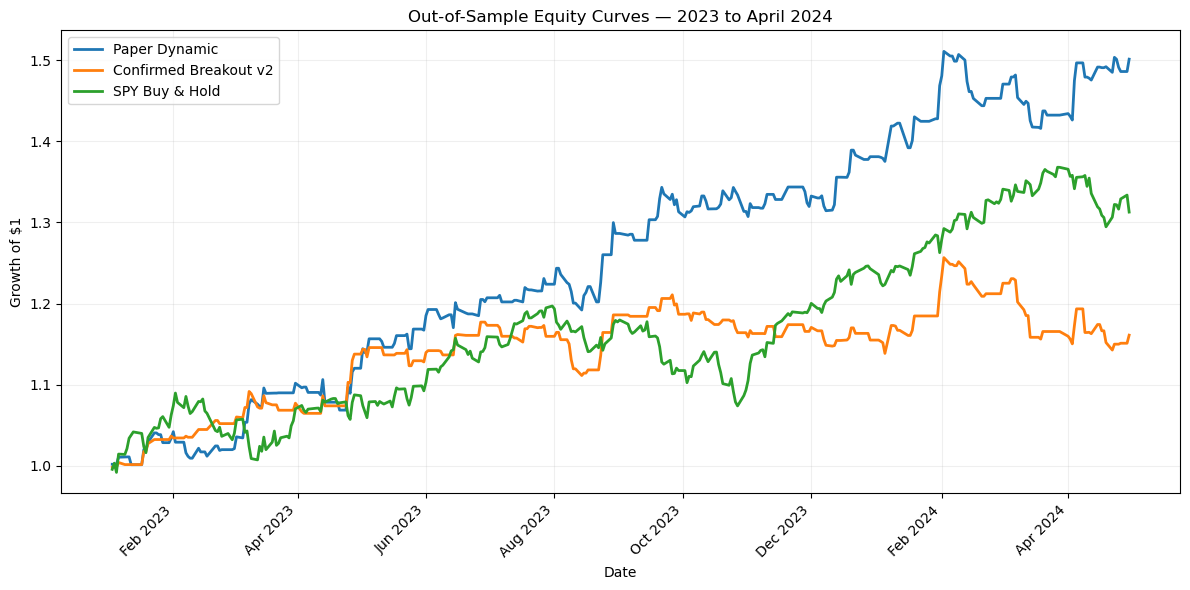

In [34]:
# OOS EQUITY CURVE COMPARISON

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    paper_oos_curve["date"],
    paper_oos_curve["growth"],
    label="Paper Dynamic",
    linewidth=2
)

ax.plot(
    confirmed_oos_curve["date"],
    confirmed_oos_curve["growth"],
    label="Confirmed Breakout v2",
    linewidth=2
)

ax.plot(
    spy_oos_curve["date"],
    spy_oos_curve["growth"],
    label="SPY Buy & Hold",
    linewidth=2
)

ax.set_title(
    "Out-of-Sample Equity Curves — 2023 to April 2024"
)

ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")

ax.xaxis.set_major_locator(
    mdates.MonthLocator(
        interval=2
    )
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%b %Y"
    )
)

ax.legend()
ax.grid(alpha=0.2)

fig.autofmt_xdate(
    rotation=45
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "final_oos_equity_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
# BUILD OOS DRAWDOWNS

def build_drawdown(
    daily
):

    x = daily.copy()

    x["date"] = pd.to_datetime(
        x["date"]
    )

    x["growth"] = (
        1
        + x["return"]
    ).cumprod()

    x["running_max"] = (
        x["growth"]
        .cummax()
    )

    x["drawdown"] = (
        x["growth"]
        / x["running_max"]
        - 1
    )

    return x


paper_oos_dd = (
    build_drawdown(
        paper_oos_daily
    )
)

confirmed_oos_dd = (
    build_drawdown(
        confirmed_oos_daily
    )
)


print(
    "Paper Dynamic max drawdown:",
    round(
        paper_oos_dd["drawdown"].min()
        * 100,
        2
    ),
    "%"
)

print(
    "Confirmed Breakout v2 max drawdown:",
    round(
        confirmed_oos_dd["drawdown"].min()
        * 100,
        2
    ),
    "%"
)

Paper Dynamic max drawdown: -6.28 %
Confirmed Breakout v2 max drawdown: -9.06 %


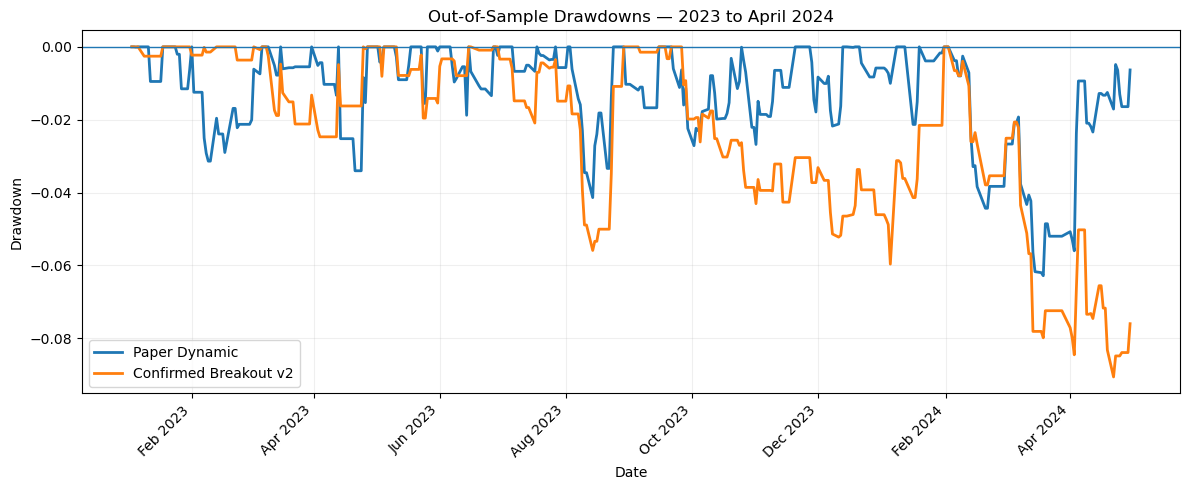

In [38]:
# OOS DRAWDOWN COMPARISON

fig, ax = plt.subplots(
    figsize=(12, 5)
)

ax.plot(
    paper_oos_dd["date"],
    paper_oos_dd["drawdown"],
    label="Paper Dynamic",
    linewidth=2
)

ax.plot(
    confirmed_oos_dd["date"],
    confirmed_oos_dd["drawdown"],
    label="Confirmed Breakout v2",
    linewidth=2
)

ax.axhline(
    y=0,
    linewidth=1
)

ax.set_title(
    "Out-of-Sample Drawdowns — 2023 to April 2024"
)

ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")

ax.xaxis.set_major_locator(
    mdates.MonthLocator(
        interval=2
    )
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%b %Y"
    )
)

ax.legend()
ax.grid(alpha=0.2)

fig.autofmt_xdate(
    rotation=45
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "final_oos_drawdowns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
# LONG / SHORT DIAGNOSTIC FUNCTION

def side_summary(
    trades
):

    summary = (
        trades
        .groupby("side")
        .agg(

            Trades=(
                "net_pnl",
                "count"
            ),

            Total_PnL=(
                "net_pnl",
                "sum"
            ),

            Average_PnL=(
                "net_pnl",
                "mean"
            ),

            Median_PnL=(
                "net_pnl",
                "median"
            ),

            Win_Rate=(
                "net_pnl",
                lambda x:
                    (x > 0).mean()
            )
        )
    )

    summary["Win_Rate"] = (
        summary["Win_Rate"]
        * 100
    )

    return summary

In [42]:
# LONG / SHORT OOS RESULTS

paper_side = (
    side_summary(
        paper_oos_trades
    )
)

confirmed_side = (
    side_summary(
        confirmed_oos_trades
    )
)


print("PAPER DYNAMIC")
display(
    paper_side.round(2)
)


print("\nCONFIRMED BREAKOUT V2")
display(
    confirmed_side.round(2)
)

PAPER DYNAMIC


,Trades,Total_PnL,Average_PnL,Median_PnL,Win_Rate
side,,,,,
LONG,173,35683.72,206.26,10.33,50.29
SHORT,139,14426.51,103.79,-125.72,41.01



CONFIRMED BREAKOUT V2


,Trades,Total_PnL,Average_PnL,Median_PnL,Win_Rate
side,,,,,
LONG,109,22886.72,209.97,26.35,50.46
SHORT,93,-6774.04,-72.84,-277.43,32.26


In [44]:
# HOLDING PERIOD ANALYSIS

def add_holding_period(
    trades
):

    x = trades.copy()

    x["entry_time"] = pd.to_datetime(
        x["entry_time"]
    )

    x["exit_time"] = pd.to_datetime(
        x["exit_time"]
    )

    x["holding_minutes"] = (
        (
            x["exit_time"]
            - x["entry_time"]
        )
        .dt.total_seconds()
        / 60
    )

    return x


paper_oos_hp = (
    add_holding_period(
        paper_oos_trades
    )
)

confirmed_oos_hp = (
    add_holding_period(
        confirmed_oos_trades
    )
)


holding_comparison = pd.DataFrame({

    "Paper Dynamic": {

        "Average Holding Minutes":
            paper_oos_hp[
                "holding_minutes"
            ].mean(),

        "Median Holding Minutes":
            paper_oos_hp[
                "holding_minutes"
            ].median(),

        "Maximum Holding Minutes":
            paper_oos_hp[
                "holding_minutes"
            ].max(),
    },

    "Confirmed Breakout v2": {

        "Average Holding Minutes":
            confirmed_oos_hp[
                "holding_minutes"
            ].mean(),

        "Median Holding Minutes":
            confirmed_oos_hp[
                "holding_minutes"
            ].median(),

        "Maximum Holding Minutes":
            confirmed_oos_hp[
                "holding_minutes"
            ].max(),
    },

}).T


display(
    holding_comparison.round(2)
)

,Average Holding Minutes,Median Holding Minutes,Maximum Holding Minutes
Paper Dynamic,105.91,60.0,359.0
Confirmed Breakout v2,118.97,89.5,329.0


In [46]:
# TRADING FREQUENCY COMPARISON

frequency_comparison = pd.DataFrame({

    "Paper Dynamic": {

        "Total Trades":
            len(
                paper_oos_trades
            ),

        "Trades / Backtest Day":
            (
                len(
                    paper_oos_trades
                )
                / len(
                    paper_oos_daily
                )
            ),

        "Trading Days":
            len(
                paper_oos_daily
            ),
    },

    "Confirmed Breakout v2": {

        "Total Trades":
            len(
                confirmed_oos_trades
            ),

        "Trades / Backtest Day":
            (
                len(
                    confirmed_oos_trades
                )
                / len(
                    confirmed_oos_daily
                )
            ),

        "Trading Days":
            len(
                confirmed_oos_daily
            ),
    },

}).T


display(
    frequency_comparison.round(3)
)

,Total Trades,Trades / Backtest Day,Trading Days
Paper Dynamic,312.0,0.945,330.0
Confirmed Breakout v2,202.0,0.612,330.0


In [48]:
# YEARLY OOS RETURNS

def yearly_returns(
    daily
):

    x = daily.copy()

    x["date"] = pd.to_datetime(
        x["date"]
    )

    x["year"] = (
        x["date"]
        .dt.year
    )

    return (
        x.groupby("year")[
            "return"
        ]
        .apply(
            lambda r:
                (1 + r).prod()
                - 1
        )
    )


oos_yearly = pd.DataFrame({

    "Paper Dynamic":
        yearly_returns(
            paper_oos_daily
        ),

    "Confirmed Breakout v2":
        yearly_returns(
            confirmed_oos_daily
        ),

    "SPY Buy & Hold":
        yearly_returns(
            spy_oos
        ),

})


oos_yearly_display = (
    oos_yearly
    * 100
)


display(
    oos_yearly_display.round(2)
)

,Paper Dynamic,Confirmed Breakout v2,SPY Buy & Hold
year,,,
2023,38.1,15.51,24.29
2024,8.7,0.52,5.61


In [50]:
# SAVE OOS DIAGNOSTICS

paper_side.to_csv(
    RESULTS_DIR
    / "paper_dynamic_oos_long_short.csv"
)

confirmed_side.to_csv(
    RESULTS_DIR
    / "confirmed_breakout_v2_oos_long_short.csv"
)

holding_comparison.to_csv(
    RESULTS_DIR
    / "oos_holding_period_comparison.csv"
)

frequency_comparison.to_csv(
    RESULTS_DIR
    / "oos_trade_frequency_comparison.csv"
)

oos_yearly.to_csv(
    RESULTS_DIR
    / "oos_yearly_returns.csv"
)


print(
    "OOS diagnostic tables saved."
)

OOS diagnostic tables saved.


In [52]:
# RECONSTRUCT TRAIN SAMPLE

paper_train = (
    paper_features.loc[
        paper_features["date"]
        <= TRAIN_END
    ]
    .copy()
)

confirmed_train = (
    confirmed_features.loc[
        confirmed_features["date"]
        <= TRAIN_END
    ]
    .copy()
)


paper_train_daily_final, paper_train_trades_final = (
    run_momentum_backtest(
        paper_train,
        initial_capital=INITIAL_CAPITAL,
        commission_per_share=COMMISSION_PER_SHARE,
        slippage_per_share=SLIPPAGE_PER_SHARE,
        stop_mode="band_vwap",
        sizing_mode="dynamic",
        entry_signal_col=None,
    )
)


confirmed_train_daily_final, confirmed_train_trades_final = (
    run_momentum_backtest(
        confirmed_train,
        initial_capital=INITIAL_CAPITAL,
        commission_per_share=COMMISSION_PER_SHARE,
        slippage_per_share=SLIPPAGE_PER_SHARE,
        stop_mode="band_vwap",
        sizing_mode="dynamic",
        entry_signal_col="confirmed_signal",
    )
)


print(
    "Paper train trades:",
    len(
        paper_train_trades_final
    )
)

print(
    "Confirmed v2 train trades:",
    len(
        confirmed_train_trades_final
    )
)

Paper train trades: 1071
Confirmed v2 train trades: 685


In [54]:
# FINAL TRAIN / TEST COMPARISON

final_rows = []


datasets = {

    ("Paper Dynamic", "Train 2018-2022"):
        paper_train_daily_final,

    ("Confirmed Breakout v2", "Train 2018-2022"):
        confirmed_train_daily_final,

    ("Paper Dynamic", "Test 2023-Apr 2024"):
        paper_oos_daily,

    ("Confirmed Breakout v2", "Test 2023-Apr 2024"):
        confirmed_oos_daily,
}


trade_counts = {

    ("Paper Dynamic", "Train 2018-2022"):
        len(
            paper_train_trades_final
        ),

    ("Confirmed Breakout v2", "Train 2018-2022"):
        len(
            confirmed_train_trades_final
        ),

    ("Paper Dynamic", "Test 2023-Apr 2024"):
        len(
            paper_oos_trades
        ),

    ("Confirmed Breakout v2", "Test 2023-Apr 2024"):
        len(
            confirmed_oos_trades
        ),
}


for (
    strategy,
    sample
), daily_data in datasets.items():

    metrics = (
        performance_metrics(
            daily_data["return"]
        )
    )

    final_rows.append({

        "Strategy":
            strategy,

        "Sample":
            sample,

        **metrics,

        "Trades":
            trade_counts[
                (
                    strategy,
                    sample
                )
            ]
    })


final_train_test = (
    pd.DataFrame(
        final_rows
    )
)


display(
    final_train_test
)

,Strategy,Sample,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio,Trades
0,Paper Dynamic,Train 2018-2022,1228,1.878271,0.242279,0.150102,1.519903,-0.113154,0.262215,1071
1,Confirmed Breakout v2,Train 2018-2022,1228,1.359883,0.192673,0.123979,1.482616,-0.100522,0.204397,685
2,Paper Dynamic,Test 2023-Apr 2024,330,0.501102,0.363683,0.132672,2.405116,-0.062815,0.318182,312
3,Confirmed Breakout v2,Test 2023-Apr 2024,330,0.161127,0.120842,0.108082,1.109390,-0.090601,0.227273,202


In [56]:
# FORMAT FINAL TRAIN / TEST TABLE

final_train_test_display = (
    final_train_test
    .copy()
    .rename(
        columns={
            "Hit Ratio":
                "Positive Day Ratio"
        }
    )
)


percentage_columns = [
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Max Drawdown",
    "Positive Day Ratio",
]


for col in percentage_columns:

    final_train_test_display[col] = (
        final_train_test_display[col]
        * 100
    )


display(
    final_train_test_display.round(2)
)

,Strategy,Sample,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Positive Day Ratio,Trades
0,Paper Dynamic,Train 2018-2022,1228,187.83,24.23,15.01,1.52,-11.32,26.22,1071
1,Confirmed Breakout v2,Train 2018-2022,1228,135.99,19.27,12.40,1.48,-10.05,20.44,685
2,Paper Dynamic,Test 2023-Apr 2024,330,50.11,36.37,13.27,2.41,-6.28,31.82,312
3,Confirmed Breakout v2,Test 2023-Apr 2024,330,16.11,12.08,10.81,1.11,-9.06,22.73,202


In [58]:
# SAVE FINAL TRAIN / TEST COMPARISON

final_train_test.to_csv(
    RESULTS_DIR
    / "final_train_test_comparison.csv",
    index=False
)

final_train_test_display.to_csv(
    RESULTS_DIR
    / "final_train_test_comparison_readable.csv",
    index=False
)


print(
    "Final train/test comparison saved."
)

Final train/test comparison saved.


In [60]:
# FINAL QUANTITATIVE CHECKPOINT

print(
    "QUANTITATIVE RESEARCH COMPLETE"
)

print(
    "=" * 60
)

print(
    "\nOriginal Strategy v1:"
)

print(
    "Adaptive VM — rejected on train."
)

print(
    "\nOriginal Strategy v2:"
)

print(
    "Confirmed Breakout — "
    "promising on train, "
    "rejected after OOS evaluation."
)

print(
    "\nFinal benchmark conclusion:"
)

print(
    "Paper Dynamic remains the strongest "
    "strategy in this dataset."
)


print(
    "\nSaved final comparison:"
)

print(
    RESULTS_DIR
    / "final_train_test_comparison.csv"
)


print(
    "\nSaved OOS figures:"
)

for file in sorted(
    FIGURES_DIR.glob(
        "*oos*"
    )
):

    print(
        " -",
        file.name
    )

QUANTITATIVE RESEARCH COMPLETE

Original Strategy v1:
Adaptive VM — rejected on train.

Original Strategy v2:
Confirmed Breakout — promising on train, rejected after OOS evaluation.

Final benchmark conclusion:
Paper Dynamic remains the strongest strategy in this dataset.

Saved final comparison:
C:\Users\Arty\OneDrive\Рабочий стол\Python Scripts\Algo Trading WUTIS\output\results\final_train_test_comparison.csv

Saved OOS figures:
 - final_oos_drawdowns.png
 - final_oos_equity_curves.png


# Final Engineering and Documentation

The strategy-development phase is complete.

This section performs the final engineering steps required to make
the project reproducible and presentation-ready:

1. Standardize metric naming
2. Verify project structure
3. Build a reproducible pipeline
4. Reproduce final results from clean data
5. Update project documentation
6. Inspect all saved outputs
7. Prepare the final research conclusions

In [63]:
%%writefile src/metrics.py

import numpy as np
import pandas as pd


def performance_metrics(returns):
    """
    Calculate portfolio-level performance metrics
    from a series of daily returns.

    Notes
    -----
    Sharpe ratio assumes a zero risk-free rate.

    Positive Day Ratio is the percentage of daily
    observations with a return greater than zero.
    It is NOT the trade win rate.
    """

    returns = (
        pd.Series(returns)
        .dropna()
        .astype(float)
    )

    n = len(returns)

    if n == 0:
        return {
            "Observations": 0,
            "Total Return": np.nan,
            "Annualized Return": np.nan,
            "Annualized Volatility": np.nan,
            "Sharpe Ratio": np.nan,
            "Max Drawdown": np.nan,
            "Positive Day Ratio": np.nan,
        }

    growth = (
        1
        + returns
    ).cumprod()

    total_return = (
        growth.iloc[-1]
        - 1
    )

    annualized_return = (
        (1 + total_return)
        ** (252 / n)
        - 1
    )

    annualized_volatility = (
        returns.std(ddof=1)
        * np.sqrt(252)
    )

    if returns.std(ddof=1) > 0:

        sharpe = (
            returns.mean()
            / returns.std(ddof=1)
            * np.sqrt(252)
        )

    else:

        sharpe = np.nan

    running_max = (
        growth.cummax()
    )

    drawdown = (
        growth
        / running_max
        - 1
    )

    max_drawdown = (
        drawdown.min()
    )

    positive_day_ratio = (
        returns > 0
    ).mean()

    return {
        "Observations":
            n,

        "Total Return":
            total_return,

        "Annualized Return":
            annualized_return,

        "Annualized Volatility":
            annualized_volatility,

        "Sharpe Ratio":
            sharpe,

        "Max Drawdown":
            max_drawdown,

        "Positive Day Ratio":
            positive_day_ratio,
    }


def trade_metrics(trades):
    """
    Calculate trade-level statistics.
    """

    if trades is None or len(trades) == 0:

        return {
            "Trades": 0,
            "Trade Win Rate": np.nan,
            "Average Trade PnL": np.nan,
            "Median Trade PnL": np.nan,
            "Best Trade": np.nan,
            "Worst Trade": np.nan,
            "Profit Factor": np.nan,
        }

    pnl = (
        trades["net_pnl"]
        .dropna()
    )

    winners = (
        pnl[pnl > 0]
    )

    losers = (
        pnl[pnl < 0]
    )

    gross_profit = (
        winners.sum()
    )

    gross_loss = (
        abs(
            losers.sum()
        )
    )

    profit_factor = (
        gross_profit / gross_loss
        if gross_loss > 0
        else np.nan
    )

    return {
        "Trades":
            len(pnl),

        "Trade Win Rate":
            (pnl > 0).mean(),

        "Average Trade PnL":
            pnl.mean(),

        "Median Trade PnL":
            pnl.median(),

        "Best Trade":
            pnl.max(),

        "Worst Trade":
            pnl.min(),

        "Profit Factor":
            profit_factor,
    }

Overwriting src/metrics.py


In [65]:
from importlib import reload

import src.metrics as metrics_module

reload(metrics_module)

from src.metrics import (
    performance_metrics,
    trade_metrics
)

print("Updated metrics module loaded.")

Updated metrics module loaded.


In [67]:
# PROJECT STRUCTURE CHECK

from pathlib import Path

PROJECT_ROOT = Path.cwd()

expected_paths = [
    Path("data"),
    Path("data/raw"),
    Path("data/processed"),
    Path("output"),
    Path("output/results"),
    Path("output/figures"),
    Path("src"),
    Path("src/__init__.py"),
    Path("src/config.py"),
    Path("src/features.py"),
    Path("src/backtest.py"),
    Path("src/metrics.py"),
    Path("src/robustness.py"),
    Path("src/extensions.py"),
    Path("research.ipynb"),
    Path("requirements.txt"),
]

structure_check = []

for path in expected_paths:

    structure_check.append({
        "Path":
            str(path),

        "Exists":
            path.exists()
    })


structure_check = pd.DataFrame(
    structure_check
)

display(structure_check)

,Path,Exists
0,data,True
1,data\raw,True
2,data\processed,True
3,output,True
4,output\results,True
5,output\figures,True
6,src,True
7,src\__init__.py,True
8,src\config.py,True
9,src\features.py,True


## Reproducible Pipeline

In [70]:
%%writefile run_pipeline.py

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.config import (
    CLEAN_FILE,
    RESULTS_DIR,
    INITIAL_CAPITAL,
    COMMISSION_PER_SHARE,
    SLIPPAGE_PER_SHARE,
    TARGET_DAILY_VOL,
    MAX_LEVERAGE,
    TRAIN_END,
)

from src.features import (
    build_features
)

from src.robustness import (
    add_dynamic_leverage
)

from src.extensions import (
    add_confirmation_signal
)

from src.backtest import (
    run_momentum_backtest
)

from src.metrics import (
    performance_metrics,
    trade_metrics
)


FIGURES_DIR = Path("output/figures")

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)


def yearly_returns(daily):
    """
    Compound daily strategy returns by calendar year.
    """

    x = daily.copy()

    x["date"] = pd.to_datetime(
        x["date"]
    )

    x["year"] = (
        x["date"]
        .dt.year
    )

    return (
        x.groupby("year")["return"]
        .apply(
            lambda r:
                (1 + r).prod() - 1
        )
    )


def build_drawdown(daily):
    """
    Construct cumulative growth and drawdown series.
    """

    x = daily.copy()

    x["date"] = pd.to_datetime(
        x["date"]
    )

    x["growth"] = (
        1
        + x["return"]
    ).cumprod()

    x["running_max"] = (
        x["growth"]
        .cummax()
    )

    x["drawdown"] = (
        x["growth"]
        / x["running_max"]
        - 1
    )

    return x


def main():

    # 1. LOAD CLEAN DATA

    print("Loading clean SPY data...")

    raw = pd.read_csv(
        CLEAN_FILE
    )

    # 2. PAPER STRATEGY FEATURES

    print("Building Paper Dynamic features...")

    paper_features = build_features(
        raw,
        lookback=14,
        vol_multiplier=1.0
    )

    paper_features = add_dynamic_leverage(
        paper_features,
        target_vol=TARGET_DAILY_VOL,
        max_leverage=MAX_LEVERAGE
    )

    # 3. ORIGINAL STRATEGY V2

    print("Building Confirmed Breakout v2 features...")

    confirmed_features = (
        add_confirmation_signal(
            paper_features
        )
    )

    # 4. TRAIN / TEST SPLIT

    paper_train = (
        paper_features.loc[
            paper_features["date"]
            <= TRAIN_END
        ]
        .copy()
    )

    paper_test = (
        paper_features.loc[
            paper_features["date"]
            > TRAIN_END
        ]
        .copy()
    )

    confirmed_train = (
        confirmed_features.loc[
            confirmed_features["date"]
            <= TRAIN_END
        ]
        .copy()
    )

    confirmed_test = (
        confirmed_features.loc[
            confirmed_features["date"]
            > TRAIN_END
        ]
        .copy()
    )

    # 5. PAPER DYNAMIC BACKTESTS

    print("Running Paper Dynamic train...")

    paper_train_daily, paper_train_trades = (
        run_momentum_backtest(
            paper_train,
            initial_capital=INITIAL_CAPITAL,
            commission_per_share=COMMISSION_PER_SHARE,
            slippage_per_share=SLIPPAGE_PER_SHARE,
            stop_mode="band_vwap",
            sizing_mode="dynamic",
            entry_signal_col=None,
        )
    )

    print("Running Paper Dynamic test...")

    paper_test_daily, paper_test_trades = (
        run_momentum_backtest(
            paper_test,
            initial_capital=INITIAL_CAPITAL,
            commission_per_share=COMMISSION_PER_SHARE,
            slippage_per_share=SLIPPAGE_PER_SHARE,
            stop_mode="band_vwap",
            sizing_mode="dynamic",
            entry_signal_col=None,
        )
    )

    # 6. CONFIRMED BREAKOUT V2 BACKTESTS

    print("Running Confirmed Breakout v2 train...")

    confirmed_train_daily, confirmed_train_trades = (
        run_momentum_backtest(
            confirmed_train,
            initial_capital=INITIAL_CAPITAL,
            commission_per_share=COMMISSION_PER_SHARE,
            slippage_per_share=SLIPPAGE_PER_SHARE,
            stop_mode="band_vwap",
            sizing_mode="dynamic",
            entry_signal_col="confirmed_signal",
        )
    )

    print("Running Confirmed Breakout v2 test...")

    confirmed_test_daily, confirmed_test_trades = (
        run_momentum_backtest(
            confirmed_test,
            initial_capital=INITIAL_CAPITAL,
            commission_per_share=COMMISSION_PER_SHARE,
            slippage_per_share=SLIPPAGE_PER_SHARE,
            stop_mode="band_vwap",
            sizing_mode="dynamic",
            entry_signal_col="confirmed_signal",
        )
    )

    # 7. SPY BUY & HOLD

    spy_daily = (
        paper_features
        .groupby("date")
        .agg(
            close=("close", "last")
        )
        .reset_index()
    )

    spy_daily["return"] = (
        spy_daily["close"]
        .pct_change()
    )

    spy_train = (
        spy_daily.loc[
            spy_daily["date"]
            <= TRAIN_END
        ]
        .dropna()
        .copy()
    )

    spy_test = (
        spy_daily.loc[
            spy_daily["date"]
            > TRAIN_END
        ]
        .dropna()
        .copy()
    )

    # 8. FINAL TRAIN / TEST PERFORMANCE TABLE

    rows = []

    strategies = {
        ("Paper Dynamic", "Train 2018-2022"):
            (
                paper_train_daily,
                paper_train_trades
            ),

        ("Confirmed Breakout v2", "Train 2018-2022"):
            (
                confirmed_train_daily,
                confirmed_train_trades
            ),

        ("SPY Buy & Hold", "Train 2018-2022"):
            (
                spy_train,
                None
            ),

        ("Paper Dynamic", "Test 2023-Apr 2024"):
            (
                paper_test_daily,
                paper_test_trades
            ),

        ("Confirmed Breakout v2", "Test 2023-Apr 2024"):
            (
                confirmed_test_daily,
                confirmed_test_trades
            ),

        ("SPY Buy & Hold", "Test 2023-Apr 2024"):
            (
                spy_test,
                None
            ),
    }

    for (
        strategy,
        sample
    ), (
        daily,
        trades
    ) in strategies.items():

        metrics = performance_metrics(
            daily["return"]
        )

        rows.append({
            "Strategy":
                strategy,

            "Sample":
                sample,

            **metrics,

            "Trades":
                (
                    len(trades)
                    if trades is not None
                    else np.nan
                )
        })

    final_comparison = (
        pd.DataFrame(rows)
    )

    final_comparison.to_csv(
        RESULTS_DIR
        / "final_train_test_comparison.csv",
        index=False
    )

    # 9. TRADE-LEVEL TEST COMPARISON

    trade_comparison = pd.DataFrame({
        "Paper Dynamic":
            trade_metrics(
                paper_test_trades
            ),

        "Confirmed Breakout v2":
            trade_metrics(
                confirmed_test_trades
            ),
    }).T

    trade_comparison.to_csv(
        RESULTS_DIR
        / "final_oos_trade_comparison.csv"
    )

    # 10. SAVE FINAL DAILY / TRADE DATA

    paper_train_daily.to_csv(
        RESULTS_DIR
        / "paper_dynamic_train_daily.csv",
        index=False
    )

    paper_train_trades.to_csv(
        RESULTS_DIR
        / "paper_dynamic_train_trades.csv",
        index=False
    )

    paper_test_daily.to_csv(
        RESULTS_DIR
        / "paper_dynamic_oos_daily.csv",
        index=False
    )

    paper_test_trades.to_csv(
        RESULTS_DIR
        / "paper_dynamic_oos_trades.csv",
        index=False
    )

    confirmed_train_daily.to_csv(
        RESULTS_DIR
        / "confirmed_breakout_v2_train_daily.csv",
        index=False
    )

    confirmed_train_trades.to_csv(
        RESULTS_DIR
        / "confirmed_breakout_v2_train_trades.csv",
        index=False
    )

    confirmed_test_daily.to_csv(
        RESULTS_DIR
        / "confirmed_breakout_v2_oos_daily.csv",
        index=False
    )

    confirmed_test_trades.to_csv(
        RESULTS_DIR
        / "confirmed_breakout_v2_oos_trades.csv",
        index=False
    )

    # 11. YEARLY RETURNS

    yearly = pd.DataFrame({
        "Paper Dynamic":
            yearly_returns(
                pd.concat(
                    [
                        paper_train_daily,
                        paper_test_daily
                    ],
                    ignore_index=True
                )
            ),

        "Confirmed Breakout v2":
            yearly_returns(
                pd.concat(
                    [
                        confirmed_train_daily,
                        confirmed_test_daily
                    ],
                    ignore_index=True
                )
            ),

        "SPY Buy & Hold":
            yearly_returns(
                spy_daily.dropna()
            ),
    })

    yearly.to_csv(
        RESULTS_DIR
        / "yearly_strategy_comparison.csv"
    )

    # 12. OOS EQUITY CURVE

    paper_test_plot = (
        paper_test_daily.copy()
    )

    confirmed_test_plot = (
        confirmed_test_daily.copy()
    )

    spy_test_plot = (
        spy_test.copy()
    )

    paper_test_plot["date"] = pd.to_datetime(
        paper_test_plot["date"]
    )

    confirmed_test_plot["date"] = pd.to_datetime(
        confirmed_test_plot["date"]
    )

    spy_test_plot["date"] = pd.to_datetime(
        spy_test_plot["date"]
    )

    paper_test_plot["growth"] = (
        paper_test_plot["end_equity"]
        / INITIAL_CAPITAL
    )

    confirmed_test_plot["growth"] = (
        confirmed_test_plot["end_equity"]
        / INITIAL_CAPITAL
    )

    spy_test_plot["growth"] = (
        1
        + spy_test_plot["return"]
    ).cumprod()

    fig, ax = plt.subplots(
        figsize=(12, 6)
    )

    ax.plot(
        paper_test_plot["date"],
        paper_test_plot["growth"],
        label="Paper Dynamic"
    )

    ax.plot(
        confirmed_test_plot["date"],
        confirmed_test_plot["growth"],
        label="Confirmed Breakout v2"
    )

    ax.plot(
        spy_test_plot["date"],
        spy_test_plot["growth"],
        label="SPY Buy & Hold"
    )

    ax.set_title(
        "Out-of-Sample Performance — 2023 to April 2024"
    )

    ax.set_xlabel("Date")
    ax.set_ylabel("Growth of $1")

    ax.xaxis.set_major_locator(
        mdates.MonthLocator(
            interval=2
        )
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter(
            "%b %Y"
        )
    )

    ax.legend()
    ax.grid(alpha=0.2)

    fig.autofmt_xdate(
        rotation=45
    )

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR
        / "final_oos_equity_curves.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    # 13. OOS DRAWDOWN FIGURE

    paper_dd = build_drawdown(
        paper_test_daily
    )

    confirmed_dd = build_drawdown(
        confirmed_test_daily
    )

    fig, ax = plt.subplots(
        figsize=(12, 5)
    )

    ax.plot(
        paper_dd["date"],
        paper_dd["drawdown"],
        label="Paper Dynamic"
    )

    ax.plot(
        confirmed_dd["date"],
        confirmed_dd["drawdown"],
        label="Confirmed Breakout v2"
    )

    ax.set_title(
        "Out-of-Sample Drawdowns — 2023 to April 2024"
    )

    ax.set_xlabel("Date")
    ax.set_ylabel("Drawdown")

    ax.legend()
    ax.grid(alpha=0.2)

    fig.autofmt_xdate(
        rotation=45
    )

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR
        / "final_oos_drawdowns.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    # COMPLETE

    print()
    print("=" * 60)
    print("PIPELINE COMPLETE")
    print("=" * 60)

    print(
        "\nData range:",
        paper_features["date"].min(),
        "to",
        paper_features["date"].max()
    )

    print(
        "\nTrain:",
        paper_train["date"].min(),
        "to",
        paper_train["date"].max()
    )

    print(
        "\nTest:",
        paper_test["date"].min(),
        "to",
        paper_test["date"].max()
    )

    print(
        "\nFinal comparison saved to:"
    )

    print(
        RESULTS_DIR
        / "final_train_test_comparison.csv"
    )


if __name__ == "__main__":
    main()

Writing run_pipeline.py


In [72]:
%run run_pipeline.py

Loading clean SPY data...
Building Paper Dynamic features...
Building Confirmed Breakout v2 features...
Running Paper Dynamic train...
Running Paper Dynamic test...
Running Confirmed Breakout v2 train...
Running Confirmed Breakout v2 test...

PIPELINE COMPLETE

Data range: 2018-01-02 00:00:00 to 2024-04-30 00:00:00

Train: 2018-01-02 00:00:00 to 2022-12-30 00:00:00

Test: 2023-01-03 00:00:00 to 2024-04-30 00:00:00

Final comparison saved to:
C:\Users\Arty\OneDrive\Рабочий стол\Python Scripts\Algo Trading WUTIS\output\results\final_train_test_comparison.csv


In [74]:
# VERIFY PIPELINE OUTPUT

final_results = pd.read_csv(
    RESULTS_DIR
    / "final_train_test_comparison.csv"
)

display(final_results)

,Strategy,Sample,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Positive Day Ratio,Trades
0,Paper Dynamic,Train 2018-2022,1228,1.878271,0.242279,0.150102,1.519903,-0.113154,0.262215,1071.0
1,Confirmed Breakout v2,Train 2018-2022,1228,1.359883,0.192673,0.123979,1.482616,-0.100522,0.204397,685.0
2,SPY Buy & Hold,Train 2018-2022,1242,0.422768,0.074164,0.198760,0.459369,-0.342290,0.540258,NaN
3,Paper Dynamic,Test 2023-Apr 2024,330,0.501102,0.363683,0.132672,2.405116,-0.062815,0.318182,312.0
4,Confirmed Breakout v2,Test 2023-Apr 2024,330,0.161127,0.120842,0.108082,1.109390,-0.090601,0.227273,202.0
5,SPY Buy & Hold,Test 2023-Apr 2024,330,0.312729,0.230957,0.128585,1.680716,-0.102798,0.551515,NaN


In [76]:
# READABLE FINAL COMPARISON

final_results_display = (
    final_results.copy()
)

percentage_columns = [
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Max Drawdown",
    "Positive Day Ratio",
]

for col in percentage_columns:

    final_results_display[col] *= 100


display(
    final_results_display.round(2)
)

,Strategy,Sample,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Positive Day Ratio,Trades
0,Paper Dynamic,Train 2018-2022,1228,187.83,24.23,15.01,1.52,-11.32,26.22,1071.0
1,Confirmed Breakout v2,Train 2018-2022,1228,135.99,19.27,12.40,1.48,-10.05,20.44,685.0
2,SPY Buy & Hold,Train 2018-2022,1242,42.28,7.42,19.88,0.46,-34.23,54.03,NaN
3,Paper Dynamic,Test 2023-Apr 2024,330,50.11,36.37,13.27,2.41,-6.28,31.82,312.0
4,Confirmed Breakout v2,Test 2023-Apr 2024,330,16.11,12.08,10.81,1.11,-9.06,22.73,202.0
5,SPY Buy & Hold,Test 2023-Apr 2024,330,31.27,23.10,12.86,1.68,-10.28,55.15,NaN


In [78]:
# VERIFY OOS RESULTS

oos_final = (
    final_results_display.loc[
        final_results_display[
            "Sample"
        ]
        ==
        "Test 2023-Apr 2024"
    ]
    .copy()
)

display(oos_final)

,Strategy,Sample,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Positive Day Ratio,Trades
3,Paper Dynamic,Test 2023-Apr 2024,330,50.110235,36.368268,13.267154,2.405116,-6.281529,31.818182,312.0
4,Confirmed Breakout v2,Test 2023-Apr 2024,330,16.112679,12.084216,10.808157,1.109390,-9.060135,22.727273,202.0
5,SPY Buy & Hold,Test 2023-Apr 2024,330,31.272879,23.095659,12.858492,1.680716,-10.279823,55.151515,NaN


## README

In [81]:
%%writefile README.md

# SPY Intraday Momentum Strategy - WUTIS Case Study

## Overview

This project reproduces and evaluates an intraday momentum strategy
for the SPDR S&P 500 ETF Trust (SPY), inspired by:

Zarattini, Aziz and Barbon,
**Beat the Market: An Effective Intraday Momentum Strategy for S&P500 ETF (SPY).**

The project was completed as an algorithmic-trading case study.

The objectives were to:

1. Understand and reproduce the main economic and trading logic of the paper.
2. Backtest the strategy using realistic transaction-cost assumptions.
3. Evaluate parameter robustness.
4. Use a chronological train/test framework.
5. Develop and evaluate an original paper-inspired strategy variation.
6. Maintain readable and reproducible research code.

## Data

The analysis uses one-minute SPY OHLCV data.

Available sample:

- Start: 2018-01-02
- End: 2024-04-30
- Regular trading session: 09:30–15:59 US Eastern Time
- 390 one-minute bars per complete trading day

The available sample is shorter than the sample used in the original
paper. Therefore, the objective is a replication of the methodology
on an independent dataset rather than an exact reproduction of the reported performance.

## Train / Test Split

A chronological split is used.

Training / development period:

2018-01-02 through 2022-12-31

Out-of-sample test period:

2023-01-01 through 2024-04-30

The test period was kept untouched while the original strategy
variations were developed.

The original strategy specification was frozen before evaluating the
2023–2024 test sample.

## Paper Strategy

### Noise Area

For every intraday time-of-day, the strategy estimates the typical
absolute movement from the market open using the previous 14 trading
days.

The resulting upper and lower boundaries define a dynamic Noise Area.

Price inside the Noise Area is interpreted as supply-demand equilibrium.

A movement above the upper boundary indicates abnormal buying pressure.

A movement below the lower boundary indicates abnormal selling pressure.

### Gap Adjustment

The boundaries incorporate both the current session open and the
previous session close to account for overnight gaps.

### Trading Decisions

Trading decisions are evaluated every 30 minutes from 10:00 through
15:30.

### Paper Variants Implemented

1. Opposite-band stop with fixed sizing
2. Current-band + VWAP stop with fixed sizing
3. Current-band + VWAP stop with dynamic volatility sizing

The third version is referred to throughout the project as
"Paper Dynamic" and is the main benchmark.

## Dynamic Position Sizing

Position size is based on recent 14-day SPY daily volatility.

Target daily volatility: 2%

Maximum leverage: 4x

Higher realized market volatility therefore reduces exposure, while
lower volatility increases exposure subject to the leverage cap.

## Transaction Costs

The backtest applies:

- Commission: $0.0035 per share per transaction
- Slippage: $0.001 per share per transaction

Slippage is applied adversely to entry and exit execution prices.

## Look-Ahead Prevention

All rolling signals are shifted so that the current day's information
is not included in estimates used to trade that same day.

Time-of-day Noise Area calculations use only historical trading days.

The volatility-scaling estimate uses only prior daily returns.

Session VWAP used for execution decisions is lagged by one minute.

## Robustness Analysis

The Paper Dynamic strategy was evaluated across alternative:

Noise Area lookbacks:

5, 10, 14, 20, 30, 60, 90 days

Volatility multipliers:

0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 2.00

Robustness analysis was performed using the training sample.

The paper specification of:

- Lookback = 14
- Volatility Multiplier = 1.0

was retained rather than replacing it with the ex-post best-performing
parameters.

## Original Strategy Research

### Original Strategy v1 — Adaptive Volatility Multiplier

The first extension allowed the Noise Area volatility multiplier to
change according to recent market volatility.

Economic hypothesis:

High-volatility environments may produce more false boundary breakouts,
so wider thresholds may improve signal quality.

Result:

The strategy underperformed Paper Dynamic on the training sample in
risk-adjusted return and drawdown.

Decision:

Rejected before out-of-sample testing.

### Original Strategy v2 — Confirmed Breakout

The second extension required two consecutive semi-hourly breakout
signals in the same direction before opening a new position.

Economic hypothesis:

Persistent movement outside the Noise Area may provide stronger evidence
of a genuine supply-demand imbalance than a single boundary breach.

Training result:

The confirmation rule substantially reduced the number of trades and
portfolio volatility while retaining a Sharpe ratio close to the Paper
Dynamic strategy.

The specification was therefore frozen before out-of-sample testing.

Out-of-sample result:

The strategy failed to generalize.

Although confirmation reduced turnover and volatility, it materially
reduced return, Sharpe ratio and trade-level profitability.

The evidence suggests that delaying entry until a second confirmation
often misses an economically important portion of the intraday momentum
move.

Decision:

Rejected after out-of-sample evaluation.

## Main Research Conclusion

The Paper Dynamic strategy remains the strongest specification tested
in this dataset.

The original-strategy experiments indicate an important trade-off:

greater signal confirmation reduces trading frequency and exposure,
but waiting for additional confirmation can sacrifice the timeliness
that appears important to the intraday momentum effect.

No further strategy variants were developed after observing the
out-of-sample results in order to avoid tuning on the test set and overfitting.

## Performance Metrics

Portfolio-level metrics include:

- Total Return
- Annualized Return
- Annualized Volatility
- Sharpe Ratio
- Maximum Drawdown
- Positive Day Ratio

Trade-level metrics include:

- Number of Trades
- Trade Win Rate
- Average Trade PnL
- Median Trade PnL
- Best / Worst Trade
- Profit Factor

The Sharpe ratio assumes a zero risk-free rate.

## Project Structure

```text
Algo Trading WUTIS/
│
├── data/
│   ├── raw/
│   └── processed/
│       ├── SPY_1min_clean.csv
│       └── SPY_1min_features.csv
│
├── output/
│   ├── results/
│   └── figures/
│
├── src/
│   ├── __init__.py
│   ├── config.py
│   ├── features.py
│   ├── backtest.py
│   ├── metrics.py
│   ├── robustness.py
│   └── extensions.py
│
├── research.ipynb
├── run_pipeline.py
├── README.md
└── requirements.txt

Overwriting README.md


## Methodology Summary

In [84]:
methodology = pd.DataFrame({

    "Item": [
        "Asset",
        "Frequency",
        "Data Start",
        "Data End",
        "Train Start",
        "Train End",
        "Test Start",
        "Test End",
        "Noise Area Lookback",
        "Volatility Multiplier",
        "Decision Frequency",
        "First Decision",
        "Last Decision",
        "Stop",
        "Sizing",
        "Target Daily Volatility",
        "Maximum Leverage",
        "Commission Per Share",
        "Slippage Per Share",
        "Original Strategy v1",
        "Original Strategy v1 Outcome",
        "Original Strategy v2",
        "Original Strategy v2 Outcome",
    ],

    "Value": [
        "SPY",
        "1-minute",
        "2018-01-02",
        "2024-04-30",
        "2018-01-02",
        "2022-12-31",
        "2023-01-01",
        "2024-04-30",
        14,
        1.0,
        "30 minutes",
        "10:00",
        "15:30",
        "Current Band + VWAP",
        "Dynamic volatility sizing",
        TARGET_DAILY_VOL,
        MAX_LEVERAGE,
        COMMISSION_PER_SHARE,
        SLIPPAGE_PER_SHARE,
        "Adaptive Volatility Multiplier",
        "Rejected on train",
        "Confirmed Breakout",
        "Rejected after OOS evaluation",
    ]
})


methodology.to_csv(
    RESULTS_DIR
    / "project_methodology.csv",
    index=False
)

display(methodology)

,Item,Value
0,Asset,SPY
1,Frequency,1-minute
2,Data Start,2018-01-02
3,Data End,2024-04-30
4,Train Start,2018-01-02
5,Train End,2022-12-31
6,Test Start,2023-01-01
7,Test End,2024-04-30
8,Noise Area Lookback,14
9,Volatility Multiplier,1.0


## Audit

In [87]:
result_files = sorted(
    RESULTS_DIR.glob("*.csv")
)

print(
    "Number of saved result files:",
    len(result_files)
)

for file in result_files:

    print(
        " -",
        file.name
    )

Number of saved result files: 37
 - adaptive_vm_v1_train_results.csv
 - baseline_daily.csv
 - baseline_trades.csv
 - confirmed_breakout_specification.csv
 - confirmed_breakout_trade_metrics.csv
 - confirmed_breakout_train_daily.csv
 - confirmed_breakout_train_results.csv
 - confirmed_breakout_train_trades.csv
 - confirmed_breakout_v2_oos_daily.csv
 - confirmed_breakout_v2_oos_long_short.csv
 - confirmed_breakout_v2_oos_trades.csv
 - confirmed_breakout_v2_specification.csv
 - confirmed_breakout_v2_train_daily.csv
 - confirmed_breakout_v2_train_trades.csv
 - dynamic_daily.csv
 - dynamic_trades.csv
 - final_oos_comparison.csv
 - final_oos_trade_comparison.csv
 - final_train_test_comparison.csv
 - final_train_test_comparison_readable.csv
 - model_parameters.csv
 - oos_holding_period_comparison.csv
 - oos_trade_frequency_comparison.csv
 - oos_yearly_returns.csv
 - paper_dynamic_oos_daily.csv
 - paper_dynamic_oos_long_short.csv
 - paper_dynamic_oos_trades.csv
 - paper_dynamic_train_daily.csv

In [89]:
figure_files = sorted(
    FIGURES_DIR.glob("*.png")
)

print(
    "Number of saved figures:",
    len(figure_files)
)

for file in figure_files:

    print(
        " -",
        file.name
    )

Number of saved figures: 8
 - dynamic_strategy_drawdown.png
 - final_oos_drawdowns.png
 - final_oos_equity_curves.png
 - paper_strategy_equity_curves.png
 - robustness_lookback_return.png
 - robustness_lookback_sharpe.png
 - robustness_vol_multiplier_sharpe.png
 - robustness_vol_multiplier_trades.png


## Master Results Table

In [93]:
# FINAL MASTER PERFORMANCE TABLE

master_results = pd.read_csv(
    RESULTS_DIR
    / "final_train_test_comparison.csv"
)

master_display = (
    master_results.copy()
)

for col in [
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Max Drawdown",
    "Positive Day Ratio",
]:

    master_display[col] *= 100


master_display = (
    master_display[
        [
            "Strategy",
            "Sample",
            "Total Return",
            "Annualized Return",
            "Annualized Volatility",
            "Sharpe Ratio",
            "Max Drawdown",
            "Positive Day Ratio",
            "Trades",
        ]
    ]
)


display(
    master_display.round(2)
)

,Strategy,Sample,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Positive Day Ratio,Trades
0,Paper Dynamic,Train 2018-2022,187.83,24.23,15.01,1.52,-11.32,26.22,1071.0
1,Confirmed Breakout v2,Train 2018-2022,135.99,19.27,12.40,1.48,-10.05,20.44,685.0
2,SPY Buy & Hold,Train 2018-2022,42.28,7.42,19.88,0.46,-34.23,54.03,NaN
3,Paper Dynamic,Test 2023-Apr 2024,50.11,36.37,13.27,2.41,-6.28,31.82,312.0
4,Confirmed Breakout v2,Test 2023-Apr 2024,16.11,12.08,10.81,1.11,-9.06,22.73,202.0
5,SPY Buy & Hold,Test 2023-Apr 2024,31.27,23.10,12.86,1.68,-10.28,55.15,NaN


## Final Trade Results

In [96]:
# FINAL OOS TRADE TABLE

trade_results = pd.read_csv(
    RESULTS_DIR
    / "final_oos_trade_comparison.csv",
    index_col=0
)

if "Trade Win Rate" in trade_results.columns:

    trade_results[
        "Trade Win Rate"
    ] *= 100


display(
    trade_results.round(2)
)

,Trades,Trade Win Rate,Average Trade PnL,Median Trade PnL,Best Trade,Worst Trade,Profit Factor
Paper Dynamic,312.0,46.15,160.61,-70.30,4861.78,-2225.00,1.53
Confirmed Breakout v2,202.0,42.08,79.77,-140.59,3438.66,-1966.81,1.24


## Robustness Results

In [100]:
# ROBUSTNESS RESULTS

lookback_results = pd.read_csv(
    RESULTS_DIR
    / "robustness_lookback.csv"
)

vm_results = pd.read_csv(
    RESULTS_DIR
    / "robustness_vol_multiplier.csv"
)

print("LOOKBACK ROBUSTNESS")
display(
    lookback_results.round(4)
)

print("\nVOLATILITY MULTIPLIER ROBUSTNESS")
display(
    vm_results.round(4)
)

LOOKBACK ROBUSTNESS


,Lookback,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio,Trades,Average Trades / Day
0,5,1228,1.2528,0.1814,0.1531,1.1643,-0.1158,0.2834,1188,0.9674
1,10,1228,1.5503,0.2118,0.1502,1.3535,-0.0975,0.2728,1110,0.9039
2,14,1228,1.8783,0.2423,0.1501,1.5199,-0.1132,0.2622,1071,0.8721
3,20,1223,1.7863,0.2351,0.1510,1.4730,-0.1067,0.2592,1035,0.8463
4,30,1213,1.3916,0.1986,0.1456,1.3166,-0.1046,0.2531,994,0.8195
5,60,1183,1.0256,0.1623,0.1451,1.1080,-0.1209,0.2350,959,0.8107
6,90,1153,1.0098,0.1648,0.1430,1.1375,-0.1221,0.2350,929,0.8057



VOLATILITY MULTIPLIER ROBUSTNESS


,Volatility Multiplier,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio,Trades,Average Trades / Day
0,0.50,1228,1.5284,0.2097,0.1818,1.1375,-0.1533,0.3640,1715,1.3966
1,0.75,1228,1.8917,0.2435,0.1645,1.4060,-0.1334,0.3168,1358,1.1059
2,1.00,1228,1.8783,0.2423,0.1501,1.5199,-0.1132,0.2622,1071,0.8721
3,1.25,1228,1.4947,0.2064,0.1406,1.4042,-0.0929,0.2191,837,0.6816
4,1.50,1228,1.1586,0.1711,0.1243,1.3318,-0.1135,0.1726,677,0.5513
5,1.75,1228,0.4604,0.0808,0.1141,0.7372,-0.1348,0.1409,570,0.4642
6,2.00,1228,0.1879,0.0360,0.1048,0.3884,-0.1324,0.1148,471,0.3836


## v1 Results

In [103]:
# ORIGINAL STRATEGY V1

adaptive_v1 = pd.read_csv(
    RESULTS_DIR
    / "adaptive_vm_v1_train_results.csv",
    index_col=0
)

display(
    adaptive_v1.round(4)
)

,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Ratio,Trades
Paper Dynamic,1228.0,1.8783,0.2423,0.1501,1.5199,-0.1132,0.2622,1071
Adaptive VM,1228.0,1.6471,0.2211,0.1550,1.3659,-0.1432,0.2655,1112


## Yearly Performance

In [105]:
# YEARLY PERFORMANCE

yearly_results = pd.read_csv(
    RESULTS_DIR
    / "yearly_strategy_comparison.csv",
    index_col=0
)

display(
    (
        yearly_results
        * 100
    ).round(2)
)

,Paper Dynamic,Confirmed Breakout v2,SPY Buy & Hold
year,,,
2018,40.80,36.94,-6.95
2019,8.40,-3.39,28.69
2020,21.61,18.35,16.14
2021,28.32,16.31,27.02
2022,20.84,29.60,-19.47
2023,38.10,15.51,24.29
2024,8.70,0.52,5.61


## Engineering Check

In [109]:
# FINAL ENGINEERING CHECK

required_final_files = [

    "README.md",
    "requirements.txt",
    "run_pipeline.py",

    "src/config.py",
    "src/features.py",
    "src/backtest.py",
    "src/metrics.py",
    "src/robustness.py",
    "src/extensions.py",

    "output/results/final_train_test_comparison.csv",
    "output/results/final_oos_trade_comparison.csv",
    "output/results/yearly_strategy_comparison.csv",

    "output/figures/final_oos_equity_curves.png",
    "output/figures/final_oos_drawdowns.png",
]


check = pd.DataFrame({

    "File":
        required_final_files,

    "Exists": [
        Path(file).exists()
        for file
        in required_final_files
    ]
})


display(check)


if check["Exists"].all():

    print(
        "\nFINAL ENGINEERING CHECK PASSED."
    )

else:

    print(
        "\nSome required files are missing."
    )

,File,Exists
0,README.md,True
1,requirements.txt,True
2,run_pipeline.py,True
3,src/config.py,True
4,src/features.py,True
5,src/backtest.py,True
6,src/metrics.py,True
7,src/robustness.py,True
8,src/extensions.py,True
9,output/results/final_train_test_comparison.csv,True



FINAL ENGINEERING CHECK PASSED.


# Figures

In [88]:
from pathlib import Path

FIGURES_DIR = Path("output/figures")
FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(FIGURES_DIR.resolve())

C:\Users\Arty\OneDrive\Рабочий стол\Python Scripts\Algo Trading WUTIS\output\figures


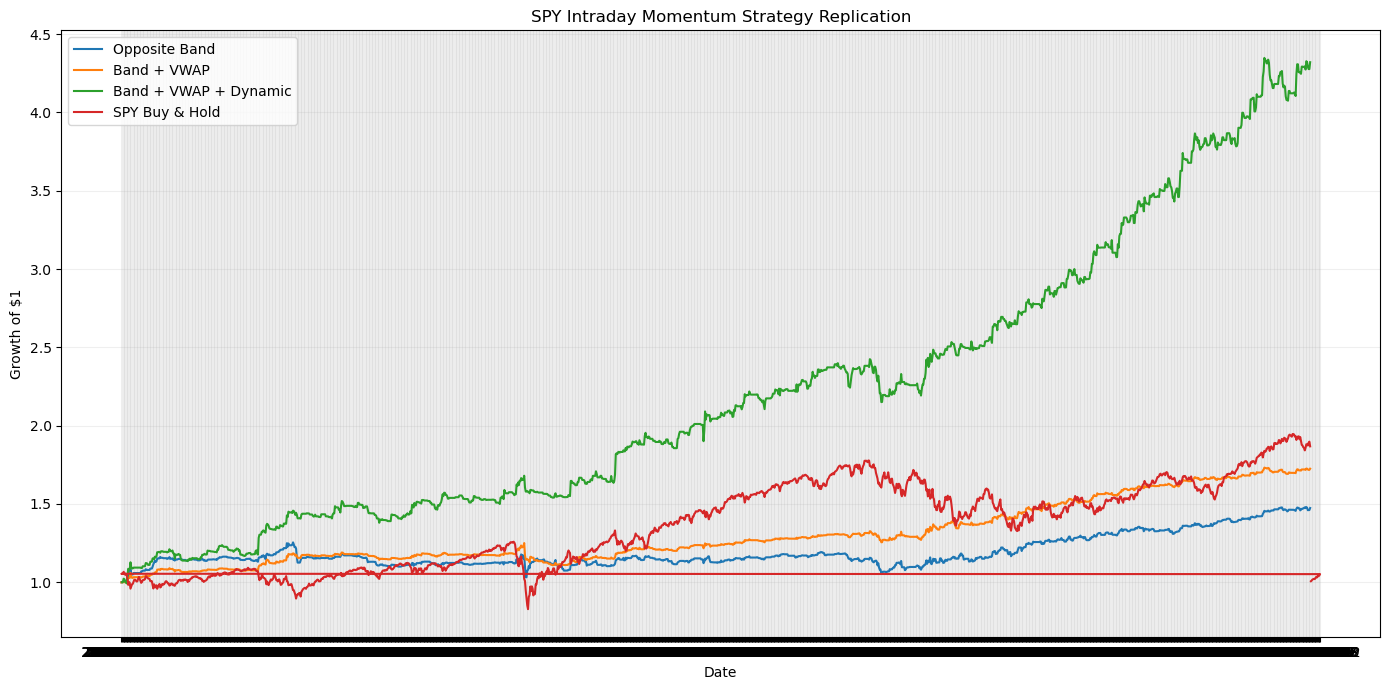

In [90]:
plt.figure(figsize=(14, 7))

plt.plot(
    base_curve["date"],
    base_curve["growth"],
    label="Opposite Band"
)

plt.plot(
    vwap_curve["date"],
    vwap_curve["growth"],
    label="Band + VWAP"
)

plt.plot(
    dynamic_curve["date"],
    dynamic_curve["growth"],
    label="Band + VWAP + Dynamic"
)

plt.plot(
    spy_curve["date"],
    spy_curve["growth"],
    label="SPY Buy & Hold"
)

plt.title(
    "SPY Intraday Momentum Strategy Replication"
)

plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "paper_strategy_equity_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

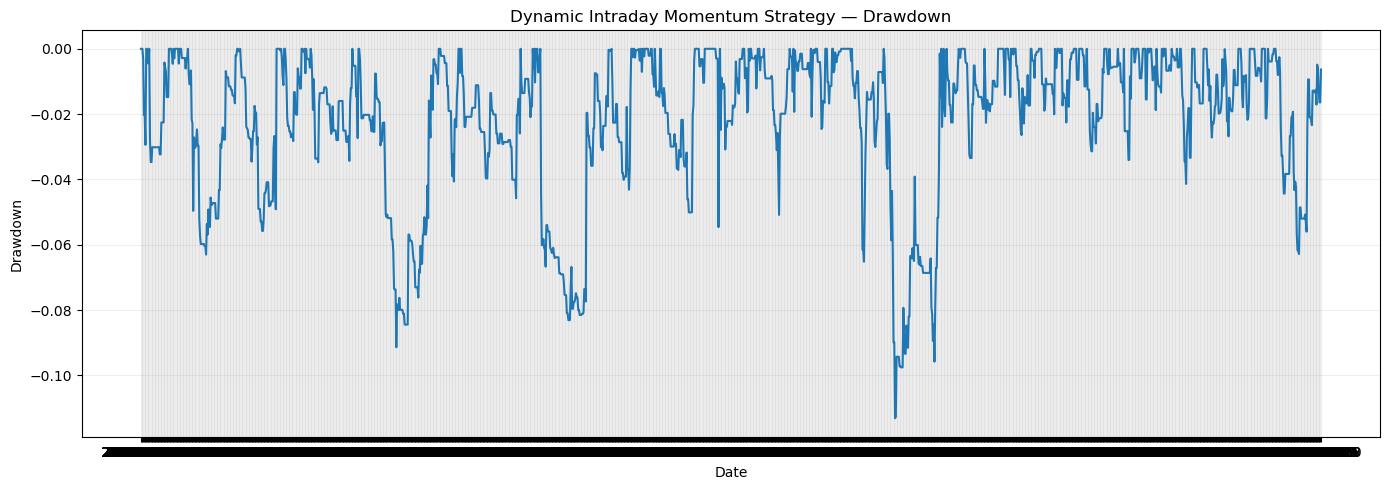

In [92]:
dynamic_dd = dynamic_daily.copy()

dynamic_dd["equity"] = (
    1 + dynamic_dd["return"]
).cumprod()

dynamic_dd["running_max"] = (
    dynamic_dd["equity"]
    .cummax()
)

dynamic_dd["drawdown"] = (
    dynamic_dd["equity"]
    / dynamic_dd["running_max"]
    - 1
)

plt.figure(figsize=(14, 5))

plt.plot(
    dynamic_dd["date"],
    dynamic_dd["drawdown"]
)

plt.title(
    "Dynamic Intraday Momentum Strategy — Drawdown"
)

plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "dynamic_strategy_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [108]:
import matplotlib.dates as mdates

for x in [
    base_curve,
    vwap_curve,
    dynamic_curve,
    spy_curve,
    dynamic_dd
]:
    x["date"] = pd.to_datetime(x["date"])

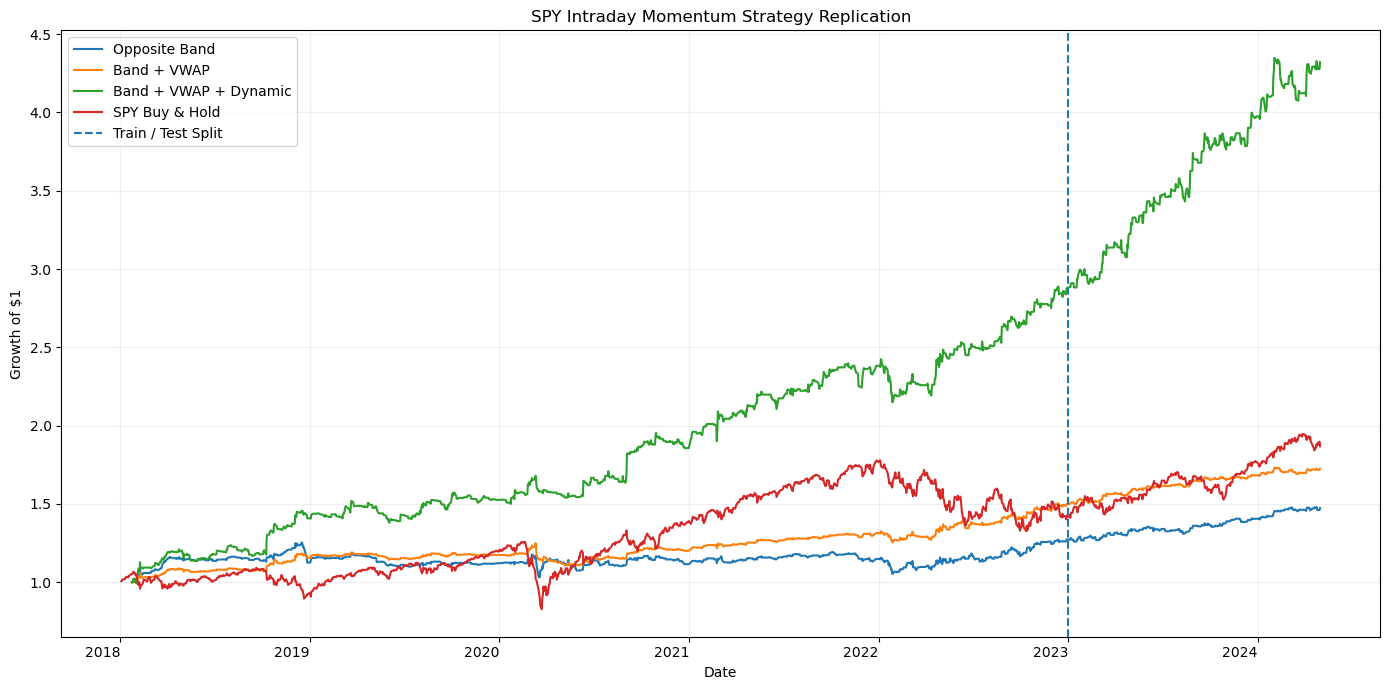

In [114]:
# PAPER STRATEGY EQUITY CURVES

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    base_curve["date"],
    base_curve["growth"],
    label="Opposite Band"
)

ax.plot(
    vwap_curve["date"],
    vwap_curve["growth"],
    label="Band + VWAP"
)

ax.plot(
    dynamic_curve["date"],
    dynamic_curve["growth"],
    label="Band + VWAP + Dynamic"
)

ax.plot(
    spy_curve["date"],
    spy_curve["growth"],
    label="SPY Buy & Hold"
)

ax.set_title(
    "SPY Intraday Momentum Strategy Replication"
)

ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")

# One tick per year
ax.xaxis.set_major_locator(
    mdates.YearLocator()
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

TRAIN_END = pd.Timestamp("2022-12-31")

ax.axvline(
    TRAIN_END,
    linestyle="--",
    linewidth=1.5,
    label="Train / Test Split"
)

ax.legend()
ax.grid(alpha=0.2)

fig.autofmt_xdate(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "paper_strategy_equity_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

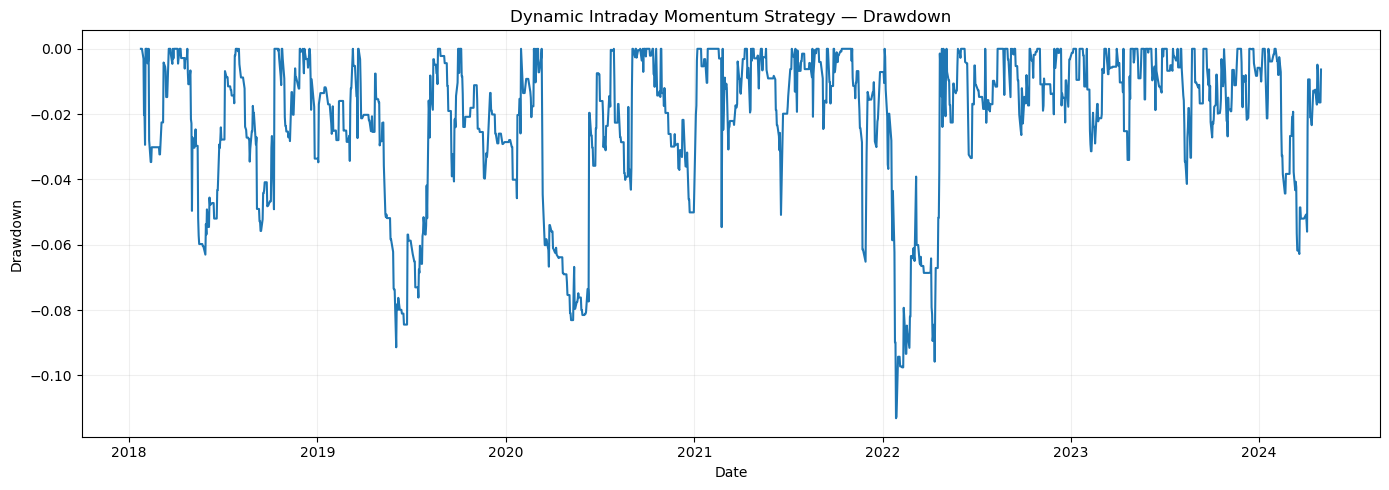

In [112]:
# DYNAMIC STRATEGY DRAWDOWN

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    dynamic_dd["date"],
    dynamic_dd["drawdown"]
)

ax.set_title(
    "Dynamic Intraday Momentum Strategy — Drawdown"
)

ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")

ax.xaxis.set_major_locator(
    mdates.YearLocator()
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

ax.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "dynamic_strategy_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Parameters

In [94]:
parameters = pd.DataFrame({
    "Parameter": [
        "Initial Capital",
        "Noise Area Lookback",
        "Volatility Multiplier",
        "Commission Per Share",
        "Slippage Per Share",
        "Target Daily Volatility",
        "Maximum Leverage",
        "Train End",
        "Test Start"
    ],

    "Value": [
        INITIAL_CAPITAL,
        LOOKBACK,
        VOL_MULTIPLIER,
        COMMISSION_PER_SHARE,
        SLIPPAGE_PER_SHARE,
        TARGET_DAILY_VOL,
        MAX_LEVERAGE,
        "2022-12-31",
        "2023-01-01"
    ]
})

parameters.to_csv(
    RESULTS_DIR / "model_parameters.csv",
    index=False
)

display(parameters)

,Parameter,Value
0,Initial Capital,100000
1,Noise Area Lookback,14
2,Volatility Multiplier,1.0
3,Commission Per Share,0.0035
4,Slippage Per Share,0.001
5,Target Daily Volatility,0.02
6,Maximum Leverage,4.0
7,Train End,2022-12-31
8,Test Start,2023-01-01


In [98]:
%%writefile README.md

# SPY Intraday Momentum Strategy

Replication and extension of the intraday momentum strategy described in:

Zarattini, C., Aziz, A., & Barbon, A. (2025),
*Beat the Market: An Effective Intraday Momentum Strategy for S&P500 ETF (SPY)*.

## Project Objective

The project:

1. Replicates the paper's baseline intraday momentum strategy.
2. Implements the improved Current Band + VWAP trailing stop.
3. Implements volatility-adjusted position sizing.
4. Evaluates performance using realistic transaction costs.
5. Uses a chronological train/test split.
6. Performs parameter robustness tests.
7. Develops and evaluates an original strategy extension.

## Data

Instrument: SPY

Frequency: 1-minute OHLCV

Sample:
2018-01-02 to 2024-04-30

Regular trading hours:
09:30–15:59 America/New_York

Complete sessions contain 390 one-minute observations.

## Strategy Logic

The strategy defines a time-varying Noise Area using the average
absolute movement from the daily open at the same time of day over
the previous 14 trading days.

Long signals occur when SPY trades above the Upper Noise Boundary.

Short signals occur when SPY trades below the Lower Noise Boundary.

Trading decisions are evaluated every 30 minutes from 10:00 to 15:30.

All positions are closed before overnight exposure.

## Strategy Variants

### 1. Opposite Band

Fixed 1x exposure.

Positions exit or reverse when the opposite Noise Area boundary
is crossed.

### 2. Current Band + VWAP

Fixed 1x exposure.

Long trailing stop:

max(Upper Band, VWAP)

Short trailing stop:

min(Lower Band, VWAP)

### 3. Current Band + VWAP + Dynamic Sizing

Uses the same trailing stop as Strategy 2.

Exposure is adjusted according to recent SPY daily volatility,
targeting 2% daily volatility with leverage capped at 4x.

## Transaction Costs

Commission:
$0.0035 per share per transaction.

Slippage:
$0.001 per share per transaction.

## Train/Test Split

Development / Train:
2018–2022

Out-of-sample Test:
2023–2024

## Repository Structure

data/raw/
    Original yearly SPY files.

data/processed/
    Cleaned and feature-engineered datasets.

src/config.py
    Project paths and strategy parameters.

src/features.py
    Feature engineering and Noise Area construction.

src/backtest.py
    Backtesting engine.

src/metrics.py
    Performance and trade statistics.

output/results/
    Strategy returns, trades, comparison tables, and parameters.

output/figures/
    Final research figures.

research.ipynb
    Research, validation, diagnostics, robustness analysis,
    and strategy comparison.

## Current Status

Completed:

- Data cleaning
- Feature engineering
- Noise Area
- Session VWAP
- Baseline opposite-band strategy
- Current Band + VWAP strategy
- Dynamic volatility sizing
- SPY benchmark
- Train/test analysis

Remaining:

- Parameter robustness testing
- Original strategy extension
- Final comparison and presentation outputs

Writing README.md


# Requirements

In [101]:
%%writefile requirements.txt

numpy
pandas
matplotlib
jupyter

Writing requirements.txt
